<div align="center">

<h1> <b> MODELO DE ISING ANTIFERROMAGNÉTICO J1–J2: TRANSICIÓN DE FASE Y EFECTO MAGNETOCALÓRICO </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Camilo Vergara Restrepo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


## 1. Planteamiento del problema

Trabajamos con un modelo de Ising bidimensional sobre una red cuadrada $L\times L$, es decir $N=L^2$ espines $S_i=\pm1$. El Hamiltoniano es

$$
H = -J_1 \sum_{\langle i,j \rangle} S_i S_j
    -J_2 \sum_{\langle\langle i,j \rangle\rangle} S_i S_j
    -h \sum_i S_i
$$

donde $\langle i,j\rangle$ son primeros vecinos (NN) y $\langle\langle i,j\rangle\rangle$ segundos vecinos (NNN, los cuatro sitios diagonales). Para la Parte A usamos campo nulo, $h=0$, y los valores base del enunciado: $J_1=1$, $J_2=-0.6$.

Implementamos ambas condiciones de frontera: **periódicas (PBC)**, donde la red se conecta consigo misma en los bordes, y **libres (FBC)**, donde simplemente no hay interacción fuera de los límites de la red.

Definimos un paso de Monte Carlo (MCS) como $N$ intentos de volteo de espín, y la estrategia general de simulación es un barrido térmico descendente $T_{\max}\to T_{\min}$: se empieza desde una configuración aleatoria a temperatura alta y, en cada paso de temperatura, se usa la configuración ya equilibrada como punto de partida de la siguiente. Esto aprovecha la continuidad del equilibrio térmico entre temperaturas vecinas y acelera bastante la convergencia comparado con reiniciar aleatoriamente en cada $T$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LIBRERÍAS ESPECIALIZADAS Y JUSTIFICACIÓN
# ============================================================

# Seaborn: Se utiliza de manera especializada para el análisis y visualización
# de las fluctuaciones del parámetro de orden stripe (Sección 30.2), permitiendo
# construir histogramas de coexistencia de fases con curvas de estimación de
# densidad de kernel (KDE) integradas de forma óptima.
import seaborn as sns

# Concurrent Futures: Permite explotar el paralelismo a nivel de procesos
# (ProcessPoolExecutor) para ejecutar de forma simultánea múltiples barridos
# térmicos independientes (diferentes tamaños de red o campos externos)
# y reducir drásticamente el tiempo total de simulación.
import concurrent.futures

# Time: Utilizada para medir con precisión el tiempo de CPU y de pared
# transcurrido durante la ejecución de los barridos térmicos (Secciones 20, 23 y 28)
# y evaluar el rendimiento del paralelismo.
import time

# Scipy (integrate): Se utiliza para la integración numérica de la
# relación de Maxwell (regla del trapecio acumulativa), lo que permite
# reconstruir la entropía magnética acumulada S_M(T) a partir de Delta S_M.
import scipy.integrate as integrate

# OS: Empleada para interactuar con el sistema operativo, permitiendo la creación
# de directorios estructurados (como 'figuras_publicacion') y la exportación de
# archivos de resultados en formatos CSV y LaTeX de manera compatible entre plataformas.
import os

# FuncAnimation y PillowWriter: Herramientas esenciales para el renderizado
# de la dinámica de espines, permitiendo empaquetar la evolución temporal
# de la red desde T_max hasta T_min en archivos GIF optimizados para su análisis.
from matplotlib.animation import FuncAnimation, PillowWriter

# Image y display: Permiten incrustar, previsualizar y renderizar las
# animaciones generadas directamente dentro de la interfaz interactiva de Colab.
from IPython.display import Image, display

# Numba (@njit): Compilador Just-In-Time (JIT) que traduce funciones críticas
# de Python (como el bucle de Metrópolis) a código de máquina nativo altamente
# optimizado, alcanzando velocidades cercanas a C/C++.
try:
    from numba import njit
except ImportError:
    # Soporte de respaldo si Numba no está disponible en el entorno
    def njit(func=None, **kwargs):
        if func is None:
            return lambda f: f
        return func


# ============================================================
# PARÁMETROS FÍSICOS
# ============================================================

J1 = 1.0
J2 = -0.6
h = 0.0
kB = 1.0


# ============================================================
# PARÁMETROS DE LA SIMULACIÓN
# ============================================================

L_VALUES = (16, 24)

T_MIN = 0.1
T_MAX = 3.0
DT = 0.1

# Barrido desde alta temperatura hacia baja temperatura
TEMPERATURES = np.arange(T_MAX, T_MIN - 0.5 * DT, -DT)

# Número de MCS dedicados a termalización y muestreo.
# Estos valores son iniciales; posteriormente los ajustaremos
# mediante el análisis de convergencia.
NTERM = 5000
NMUESTRA = 10000

# Semilla reproducible.
# NOTA: además de fijar esta semilla, es necesario sembrar por
# separado el generador aleatorio interno de Numba (ver Sección 6),
# ya que las funciones @njit no usan el generador global de NumPy.
SEED = 12345

# Número de bloques usados para estimar la incertidumbre estadística
# (método de bloques / batch means, ver Sección 8.1 más abajo).
# Cada bloque debe ser mucho más largo que el tiempo de
# autocorrelación (Sección 18) para que los bloques sean
# aproximadamente independientes entre sí.
NBLOCKS = 20


print("J1 =", J1)
print("J2 =", J2)
print("h  =", h)
print("Temperaturas:", TEMPERATURES)
print("Tamaño de red:", L_VALUES)

J1 = 1.0
J2 = -0.6
h  = 0.0
Temperaturas: [3.  2.9 2.8 2.7 2.6 2.5 2.4 2.3 2.2 2.1 2.  1.9 1.8 1.7 1.6 1.5 1.4 1.3
 1.2 1.1 1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]
Tamaño de red: (16, 24)


In [2]:
# ============================================================
# ESTILO GRÁFICO DE PUBLICACIÓN
# ============================================================
# Estilo único usado en todas las figuras del notebook, pensado para
# que sean directamente reutilizables en un artículo o informe: fuente
# serif, texto legible en tamaño de columna, resolución de 300 dpi al
# guardar, y una paleta de colores consistente y accesible (colorblind-
# friendly, Wong 2011) usada en todo el documento.

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 10.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 1.6,
    "lines.markersize": 5,
    "errorbar.capsize": 3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Paleta accesible (Wong, 2011, Nature Methods) usada de forma
# consistente para distinguir tamaños de red / campos / fronteras.
COLOR_PBC = "#0072B2"
COLOR_FBC = "#D55E00"
COLOR_L16 = "#009E73"
COLOR_L24 = "#CC79A7"
COLOR_H0 = "#7F7F7F"
COLOR_H05 = "#D55E00"
COLOR_ACCENT = "#E69F00"

FIGURES_DIR = "figuras_publicacion"
os.makedirs(FIGURES_DIR, exist_ok=True)


def savefig(fig_or_name, name=None):
    """
    Guarda la figura activa (o la pasada explícitamente) en
    `FIGURES_DIR/name.pdf` y `.png` a 300 dpi, listas para insertar en
    un manuscrito. Uso: savefig("Ms_vs_T") justo antes de plt.show().
    """
    if name is None:
        name = fig_or_name
        fig = plt.gcf()
    else:
        fig = fig_or_name

    for ext in ("png", "pdf"):
        fig.savefig(
            os.path.join(FIGURES_DIR, f"{name}.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )


## 2. Representación de la red y tablas de vecinos

Para trabajar cómodamente con Numba conviene aplanar la red: el sitio $(x,y)$ se guarda en la posición $i = xL+y$ de un arreglo 1D de tamaño $N=L^2$.

Como recorrer los vecinos de cada sitio en cada intento de Metrópolis sería costoso, precalculamos tablas de vecinos una sola vez por corrida: para cada sitio guardamos sus NN, sus NNN y cuántos vecinos válidos tiene. En PBC todos los sitios tienen 4 NN y 4 NNN; en FBC el número de vecinos depende de si el sitio está en el interior, en un borde o en una esquina.

In [3]:
@njit
def build_neighbor_tables(L, periodic=True):
    """
    Construye las tablas de primeros vecinos (NN) y segundos vecinos (NNN).

    La red se almacena en forma plana:
        index = x * L + y

    NN:
        (x+1,y), (x-1,y), (x,y+1), (x,y-1)

    NNN:
        (x+1,y+1), (x+1,y-1), (x-1,y+1), (x-1,y-1)

    Para fronteras libres puede haber menos de cuatro vecinos.
    Las posiciones no utilizadas en las tablas se rellenan con -1.
    """

    N = L * L
    MAX_NEIGHBORS = 4

    nn = np.full((N, MAX_NEIGHBORS), -1, dtype=np.int32)
    nnn = np.full((N, MAX_NEIGHBORS), -1, dtype=np.int32)

    n_nn = np.zeros(N, dtype=np.int32)
    n_nnn = np.zeros(N, dtype=np.int32)

    for x in range(L):
        for y in range(L):

            i = x * L + y

            # ------------------------------------------------
            # Primeros vecinos
            # ------------------------------------------------
            candidate_nn = (
                (x + 1, y),
                (x - 1, y),
                (x, y + 1),
                (x, y - 1),
            )

            count = 0

            for xx, yy in candidate_nn:

                if periodic:

                    xx %= L
                    yy %= L

                    nn[i, count] = xx * L + yy
                    count += 1

                else:

                    if 0 <= xx < L and 0 <= yy < L:

                        nn[i, count] = xx * L + yy
                        count += 1

            n_nn[i] = count

            # ------------------------------------------------
            # Segundos vecinos
            # ------------------------------------------------
            candidate_nnn = (
                (x + 1, y + 1),
                (x + 1, y - 1),
                (x - 1, y + 1),
                (x - 1, y - 1),
            )

            count = 0

            for xx, yy in candidate_nnn:

                if periodic:

                    xx %= L
                    yy %= L

                    nnn[i, count] = xx * L + yy
                    count += 1

                else:

                    if 0 <= xx < L and 0 <= yy < L:

                        nnn[i, count] = xx * L + yy
                        count += 1

            n_nnn[i] = count

    return nn, n_nn, nnn, n_nnn

## 3. Energía de una configuración

La energía de una configuración dada es

$$
E = -J_1 \sum_{\langle i,j \rangle} S_i S_j
    -J_2 \sum_{\langle\langle i,j \rangle\rangle} S_i S_j
    -h \sum_i S_i.
$$

Al recorrer todos los sitios y sumar sobre sus vecinos, cada enlace se cuenta dos veces (una desde cada extremo), así que hay que corregir con un factor $1/2$:

$$
E_{\text{int}} =
-\frac{J_1}{2} \sum_i S_i \sum_{j \in NN(i)} S_j
-\frac{J_2}{2} \sum_i S_i \sum_{j \in NNN(i)} S_j,
\qquad
E_h = -h \sum_i S_i.
$$

En la Parte A siempre usamos $h=0$, pero dejamos el término implementado desde ahora porque lo necesitaremos más adelante para el efecto magnetocalórico.

In [4]:
@njit
def compute_energy(spins, J1, J2, h,
                   nn, n_nn,
                   nnn, n_nnn):
    """
    Calcula la energía total de una configuración.

    Las interacciones se cuentan dos veces al recorrer todos
    los vecinos, por lo que se incluye el factor 1/2.
    """

    N = spins.size

    interaction_nn = 0.0
    interaction_nnn = 0.0
    magnetization = 0.0

    for i in range(N):

        si = spins[i]

        # -----------------------------
        # Primeros vecinos
        # -----------------------------
        for k in range(n_nn[i]):

            j = nn[i, k]

            interaction_nn += si * spins[j]

        # -----------------------------
        # Segundos vecinos
        # -----------------------------
        for k in range(n_nnn[i]):

            j = nnn[i, k]

            interaction_nnn += si * spins[j]

        magnetization += si

    energy = (
        -0.5 * J1 * interaction_nn
        -0.5 * J2 * interaction_nnn
        -h * magnetization
    )

    return energy, magnetization

## 4. Magnetización de subred y magnetización total

La red cuadrada se divide en dos subredes según la paridad de $x+y$: la subred $A$ ($x+y$ par) y la subred $B$ ($x+y$ impar).

La magnetización total es simplemente $M=\sum_i S_i$. La magnetización de subred, que es el parámetro de orden pedido en el enunciado para el antiferromagneto, es

$$
M_s = \frac{1}{2N} \left| \sum_{i \in A} S_i - \sum_{j \in B} S_j \right|
= \frac{|S_A - S_B|}{2N},
$$

donde $S_A$ y $S_B$ son las sumas de espín en cada subred. Mantener $S_A$ y $S_B$ actualizados incrementalmente (en vez de recalcularlos después de cada flip) nos permite obtener $M_s$ en tiempo constante.

In [5]:
@njit
def initialize_all_observables(spins, L):
    """
    Calcula inicialmente:

    M  : magnetización total
    SA : suma de espines de la subred A
    SB : suma de espines de la subred B
    SX : suma stripe asociada a x
    SY : suma stripe asociada a y
    """

    N = spins.size

    M = 0.0
    SA = 0.0
    SB = 0.0
    SX = 0.0
    SY = 0.0

    for x in range(L):
        for y in range(L):

            i = x * L + y
            s = spins[i]

            M += s

            if (x + y) % 2 == 0:
                SA += s
            else:
                SB += s

            if x % 2 == 0:
                SX += s
            else:
                SX -= s

            if y % 2 == 0:
                SY += s
            else:
                SY -= s

    return M, SA, SB, SX, SY


## 5. Configuración inicial

Partimos de una configuración completamente aleatoria, $S_i=\pm1$ con igual probabilidad, que es lo esperable a temperatura alta, donde las fluctuaciones térmicas dominan sobre las interacciones de intercambio y el sistema está desordenado.

Como se mencionó antes, una vez termalizado el sistema en $T_{\max}$, esa configuración final se reutiliza como punto de partida para $T_{\max}-\Delta T$, y así sucesivamente. Es lo que llamamos barrido descendente con memoria.

In [6]:
def random_configuration(L, seed=None):
    """
    Genera una configuración aleatoria de espines ±1.
    """

    rng = np.random.default_rng(seed)

    spins = rng.choice(
        np.array([-1, 1], dtype=np.int8),
        size=L * L
    )

    return spins

## 6. Algoritmo de Metrópolis

En cada intento de Monte Carlo se elige aleatoriamente un sitio $i$ y se propone voltear su espín, $S_i\to -S_i$. El cambio de energía asociado es

$$
\Delta E = 2 S_i \left[ J_1 \sum_{j \in NN(i)} S_j + J_2 \sum_{j \in NNN(i)} S_j + h \right],
$$

y con $\beta=1/(k_BT)$ la regla de aceptación de Metrópolis es la usual:

$$
P_{\text{acc}} =
\begin{cases}
1, & \Delta E \leq 0 \\
e^{-\beta \Delta E}, & \Delta E > 0.
\end{cases}
$$

Si el movimiento se acepta actualizamos incrementalmente $E\leftarrow E+\Delta E$, $M\leftarrow M-2S_i^{\text{viejo}}$, y la suma de la subred correspondiente ($S_A$ o $S_B$) en $-2S_i^{\text{viejo}}$. Así evitamos recorrer toda la red después de cada flip para recalcular los observables.

Un detalle importante de reproducibilidad: todas las decisiones aleatorias de esta parte del algoritmo (elegir $i$ y aceptar o no el volteo) ocurren dentro de funciones compiladas con `@njit`, y Numba usa un generador de números aleatorios propio, distinto al de NumPy. Fijar `np.random.default_rng(SEED)` solo controla la configuración inicial (ver `random_configuration`); no afecta en nada la dinámica de Metrópolis. Por eso definimos `seed_numba_rng`, que sembramos explícitamente al comienzo de cada corrida independiente, antes del primer MCS. Sin esa llamada, dos corridas con la misma `SEED` arrancan con la misma configuración pero siguen trayectorias de Metrópolis distintas.

Esta implementación sigue la formulación original del algoritmo de Metrópolis (Metropolis et al., 1953), tal como se presenta en los textos estándar de simulación Monte Carlo en física estadística (Landau & Binder, 2021).


In [7]:
@njit
def build_accept_table(J1, J2, h, beta):
    """
    Precalcula la probabilidad de aceptación de Metrópolis

        P = min(1, exp(-beta * dE))

    para todos los valores posibles de dE, indexada por:

        si_idx  en {0,1}  ->  Si = -1, +1
        a       en 0..8   ->  suma_NN  = a - 4   (rango -4..4)
        b       en 0..8   ->  suma_NNN = b - 4   (rango -4..4)

    El rango -4..4 cubre tanto fronteras periódicas (siempre 4
    vecinos) como fronteras libres (de 2 a 4 NN, de 1 a 4 NNN):
    sobran entradas, nunca faltan.

    Se reconstruye una sola vez por temperatura (162 valores),
    evitando llamar a exp() en cada intento de flip.
    """

    table = np.empty((2, 9, 9), dtype=np.float64)

    for si_idx in range(2):

        Si = 1.0 if si_idx == 1 else -1.0

        for a in range(9):

            snn = a - 4

            for b in range(9):

                snnn = b - 4

                dE = 2.0 * Si * (J1 * snn + J2 * snnn + h)

                if dE <= 0.0:
                    table[si_idx, a, b] = 1.0
                else:
                    table[si_idx, a, b] = np.exp(-beta * dE)

    return table


@njit
def metropolis_mcs(
    spins,
    L,
    accept_table,
    J1,
    J2,
    h,
    nn,
    n_nn,
    nnn,
    n_nnn,
    energy,
    magnetization,
    SA,
    SB,
    SX,
    SY
):
    """
    Ejecuta exactamente un MCS = N intentos de flip, usando la tabla
    de aceptación precalculada en lugar de exp().

    La configuración 'spins' se modifica in-place. También se
    actualizan incrementalmente:

        energy
        magnetization
        SA, SB   (subredes)
        SX, SY   (stripe)

    Devuelve además el número de flips aceptados, útil para
    monitorear la tasa de aceptación del muestreo.
    """

    N = spins.size
    accepted_count = 0

    for _ in range(N):

        # ----------------------------------------------------
        # Elegir aleatoriamente un sitio
        # ----------------------------------------------------
        i = np.random.randint(0, N)

        si = spins[i]
        si_idx = 1 if si > 0 else 0

        # ----------------------------------------------------
        # Sumas de espines vecinos (sin multiplicar por J1, J2)
        # ----------------------------------------------------
        snn = 0
        for k in range(n_nn[i]):
            snn += spins[nn[i, k]]

        snnn = 0
        for k in range(n_nnn[i]):
            snnn += spins[nnn[i, k]]

        # ----------------------------------------------------
        # Regla de Metrópolis vía tabla precalculada
        # ----------------------------------------------------
        p = accept_table[si_idx, snn + 4, snnn + 4]

        if p >= 1.0 or np.random.random() < p:

            spins[i] = -si

            delta_E = 2.0 * si * (J1 * snn + J2 * snnn + h)

            energy += delta_E
            magnetization -= 2.0 * si

            x = i // L
            y = i - x * L

            if (x + y) % 2 == 0:
                SA -= 2.0 * si
            else:
                SB -= 2.0 * si

            if x % 2 == 0:
                SX -= 2.0 * si
            else:
                SX += 2.0 * si

            if y % 2 == 0:
                SY -= 2.0 * si
            else:
                SY += 2.0 * si

            accepted_count += 1

    return energy, magnetization, SA, SB, SX, SY, accepted_count


In [8]:
@njit
def seed_numba_rng(seed):
    """
    Siembra el generador de números aleatorios interno de Numba.

    Numba mantiene, dentro del código compilado con @njit, un generador
    propio (independiente del de NumPy usado, por ejemplo, en
    random_configuration). Debe llamarse a esta función una vez al
    inicio de cada corrida independiente para que toda la secuencia de
    sitios propuestos y decisiones de aceptación de metropolis_mcs sea
    reproducible dada una misma semilla.
    """
    np.random.seed(seed)


## 7. Prueba de consistencia de la energía

Antes de correr nada en serio conviene verificar que el cálculo incremental de la energía (el que se usa durante el muestreo) coincide con el cálculo directo del Hamiltoniano. La prueba es sencilla: generamos una configuración aleatoria (sembrando también el generador de Numba, sección 6, para que sea reproducible), calculamos su energía directamente, ejecutamos un MCS, comparamos la energía incremental resultante con el cálculo directo de la configuración final. Si todo está bien implementado, la diferencia debería ser prácticamente cero, salvo redondeo numérico. Vale la pena hacer esta prueba ahora y no después de haber corrido millones de MCS.

In [9]:
def test_energy_consistency(L=8, periodic=True, seed=123):

    spins = random_configuration(L, seed=seed)

    nn, n_nn, nnn, n_nnn = build_neighbor_tables(
        L,
        periodic=periodic
    )

    # Inicialización
    E, M = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn,
        n_nn,
        nnn,
        n_nnn
    )

    M_inc, SA, SB, SX, SY = initialize_all_observables(spins, L)

    # Verificación inicial
    assert np.isclose(M, M_inc)

    beta = 1.0 / (kB * 1.5)
    accept_table = build_accept_table(J1, J2, h, beta)

    # Sembramos también el generador interno de Numba: sin esto, el MCS
    # ejecutado a continuación no sería reproducible entre corridas.
    seed_numba_rng(seed)

    # Un MCS
    E_inc, M_inc, SA, SB, SX, SY, _ = metropolis_mcs(
        spins,
        L,
        accept_table,
        J1,
        J2,
        h,
        nn,
        n_nn,
        nnn,
        n_nnn,
        E,
        M_inc,
        SA,
        SB,
        SX,
        SY
    )

    # Recalcular directamente al final
    E_direct, M_direct = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn,
        n_nn,
        nnn,
        n_nnn
    )

    print(f"L = {L}")
    print(f"Periodic = {periodic}")
    print(f"E incremental = {E_inc:.12f}")
    print(f"E directa     = {E_direct:.12f}")
    print(f"Diferencia     = {abs(E_inc - E_direct):.3e}")
    print(f"M incremental = {M_inc:.12f}")
    print(f"M directa     = {M_direct:.12f}")

    assert np.isclose(E_inc, E_direct, atol=1e-10)
    assert np.isclose(M_inc, M_direct, atol=1e-10)

    print("\n✓ Prueba de consistencia superada.")


# Ejecutamos ambas condiciones de frontera
test_energy_consistency(L=8, periodic=True)
print()
test_energy_consistency(L=8, periodic=False)


L = 8
Periodic = True
E incremental = -49.600000000000
E directa     = -49.600000000000
Diferencia     = 0.000e+00
M incremental = -10.000000000000
M directa     = -10.000000000000

✓ Prueba de consistencia superada.

L = 8
Periodic = False
E incremental = -44.000000000000
E directa     = -44.000000000000
Diferencia     = 0.000e+00
M incremental = -16.000000000000
M directa     = -16.000000000000

✓ Prueba de consistencia superada.


## 8. Diagnóstico de termalización

Antes de calcular cualquier promedio termodinámico hay que dejar que el sistema llegue al equilibrio. El enunciado pide justamente eso: determinar $N_{\text{term}}$ estudiando cómo se comportan los promedios acumulados de energía y magnetización, en vez de asumir de entrada un número fijo de pasos.

Para un observable $X$, el promedio acumulado tras $n$ MCS es

$$
\overline{X}(n) = \frac{1}{n} \sum_{t=1}^{n} X_t,
$$

y en particular nos interesan $\overline{E}(n)$ y $\overline{M_s}(n)$. También es útil mirar $\overline{|E|}(n)$, que no es lo mismo que $|\overline{E}(n)|$: sirve para visualizar mejor la relajación cuando las fluctuaciones de $E$ dificultan ver la tendencia a simple vista, pero no reemplaza a la energía con signo en los cálculos termodinámicos.

El criterio que usamos es identificar cuándo el promedio acumulado deja de mostrar una deriva sistemática apreciable; ese punto es nuestra estimación de $N_{\text{term}}$. Cerca de la transición de fase la relajación puede ser bastante más lenta por el *critical slowing down*, así que no hay razón para esperar que $N_{\text{term}}$ sea el mismo a todas las temperaturas.

In [10]:
@njit
def thermalization_trace(
    spins,
    L,
    T,
    J1,
    J2,
    h,
    nn,
    n_nn,
    nnn,
    n_nnn,
    n_mcs
):
    """
    Ejecuta n_mcs MCS y devuelve las series temporales de:

        energy_per_spin
        abs_energy_per_spin
        sublattice_magnetization

    La configuración 'spins' se modifica in-place.

    Al finalizar, también devuelve los observables incrementales
    necesarios para continuar la simulación desde esta configuración.
    """

    N = spins.size
    beta = 1.0 / (kB * T)
    accept_table = build_accept_table(J1, J2, h, beta)

    # --------------------------------------------------------
    # Estado inicial
    # --------------------------------------------------------

    # La magnetización total la recalcula initialize_all_observables a
    # continuación junto con SA, SB, SX y SY; aquí solo necesitamos la energía.
    energy, _ = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn,
        n_nn,
        nnn,
        n_nnn
    )

    magnetization, SA, SB, SX, SY = initialize_all_observables(
        spins,
        L
    )

    # --------------------------------------------------------
    # Arrays de diagnóstico
    # --------------------------------------------------------

    energy_per_spin = np.empty(n_mcs, dtype=np.float64)
    abs_energy_per_spin = np.empty(n_mcs, dtype=np.float64)
    sublattice_magnetization = np.empty(n_mcs, dtype=np.float64)

    # --------------------------------------------------------
    # Evolución
    # --------------------------------------------------------

    for mcs in range(n_mcs):

        (
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY,
            _
        ) = metropolis_mcs(
            spins,
            L,
            accept_table,
            J1,
            J2,
            h,
            nn,
            n_nn,
            nnn,
            n_nnn,
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY
        )

        energy_per_spin[mcs] = energy / N

        abs_energy_per_spin[mcs] = abs(energy) / N

        sublattice_magnetization[mcs] = (
            abs(SA - SB) / (2.0 * N)
        )

    return (
        energy_per_spin,
        abs_energy_per_spin,
        sublattice_magnetization,
        energy,
        magnetization,
        SA,
        SB
    )


## 9. Promedios acumulados por espín

A partir de las series obtenidas durante la relajación calculamos $\overline{e}(n)$ y $\overline{|e|}(n)$ con $e=E/N$, además de $\overline{M_s}(n)$. La energía con signo sigue siendo la cantidad físicamente relevante; la versión con valor absoluto se usa solo como apoyo visual para identificar la estabilización.

### Estimación del error estadístico: método de bloques

A lo largo de todo el notebook reportamos, junto a cada promedio térmico $\langle O\rangle$, una barra de error $\sigma_{\langle O\rangle}$. Como las muestras sucesivas de una cadena de Metrópolis están correlacionadas, **no** es correcto estimar ese error como $\mathrm{std}(\text{muestras})/\sqrt{N_{\text{muestra}}}$: eso ignora la autocorrelación temporal (Sección 18) y subestima sistemáticamente la incertidumbre real.

En su lugar usamos el método de bloques (*batch means*): dividimos la etapa de muestreo de cada temperatura en $N_{\text{bloques}}=20$ bloques consecutivos, calculamos el promedio de cada observable dentro de cada bloque por separado, y estimamos

$$
\langle O\rangle = \overline{O_{\text{bloques}}}, \qquad
\sigma_{\langle O\rangle} = \frac{\mathrm{std}(O_{\text{bloques}})}{\sqrt{N_{\text{bloques}}}}.
$$

Esto es válido siempre que cada bloque sea considerablemente más largo que el tiempo de autocorrelación integrado $\tau_{\text{int}}$ (Sección 18), de modo que los bloques sean aproximadamente independientes; con $N_{\text{muestra}}=10\,000$ y $N_{\text{bloques}}=20$, cada bloque tiene 500 MCS, que comparamos explícitamente con $\tau_{\text{int}}$ en la Sección 18. Este es el mismo esquema que se usa para $C_v$, $\chi_s$, $U$ y el resto de cantidades derivadas de fluctuaciones: en cada bloque se recalculan con la fórmula habitual y luego se promedia y se toma la dispersión entre bloques, en vez de derivar su error analíticamente (mucho más delicado para cantidades no lineales en los momentos de $O$).


In [11]:
def cumulative_mean(values):
    """
    Promedio acumulado:

        mean[n] = promedio de values[0:n+1]
    """

    values = np.asarray(values, dtype=np.float64)

    return np.cumsum(values) / np.arange(
        1,
        values.size + 1
    )

In [12]:
# ============================================================
# DIAGNÓSTICO DE TERMALIZACIÓN
# ============================================================

L_test = 24
T_test = 1.5
NTERM_TEST = 5000

# Tabla de vecinos para frontera periódica
nn, n_nn, nnn, n_nnn = build_neighbor_tables(
    L_test,
    periodic=True
)

# Configuración aleatoria inicial
spins = random_configuration(
    L_test,
    seed=SEED
)

# Sembramos también el generador interno de Numba para que la
# relajación simulada a continuación sea reproducible.
seed_numba_rng(SEED)

# Ejecutar la relajación
(
    energy_series,
    abs_energy_series,
    Ms_series,
    E_final,
    M_final,
    SA_final,
    SB_final
) = thermalization_trace(
    spins,
    L_test,
    T_test,
    J1,
    J2,
    h,
    nn,
    n_nn,
    nnn,
    n_nnn,
    NTERM_TEST
)

# Promedios acumulados
cum_energy = cumulative_mean(energy_series)

cum_abs_energy = cumulative_mean(
    abs_energy_series
)

cum_Ms = cumulative_mean(
    Ms_series
)

print(f"L = {L_test}")
print(f"T = {T_test}")
print(f"MCS ejecutados = {NTERM_TEST}")
print()
print(
    f"E/N final = {energy_series[-1]:.6f}"
)
print(
    f"<E/N> acumulado final = {cum_energy[-1]:.6f}"
)
print(
    f"<|E|>/N acumulado final = {cum_abs_energy[-1]:.6f}"
)
print(
    f"<Ms> acumulado final = {cum_Ms[-1]:.6f}"
)

L = 24
T = 1.5
MCS ejecutados = 5000

E/N final = -0.662500
<E/N> acumulado final = -0.664267
<|E|>/N acumulado final = 0.664267
<Ms> acumulado final = 0.006642


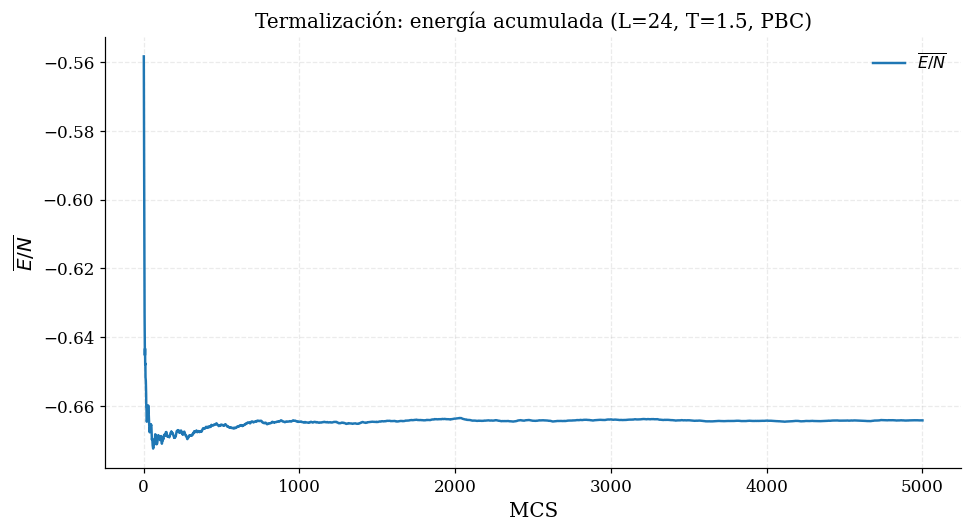

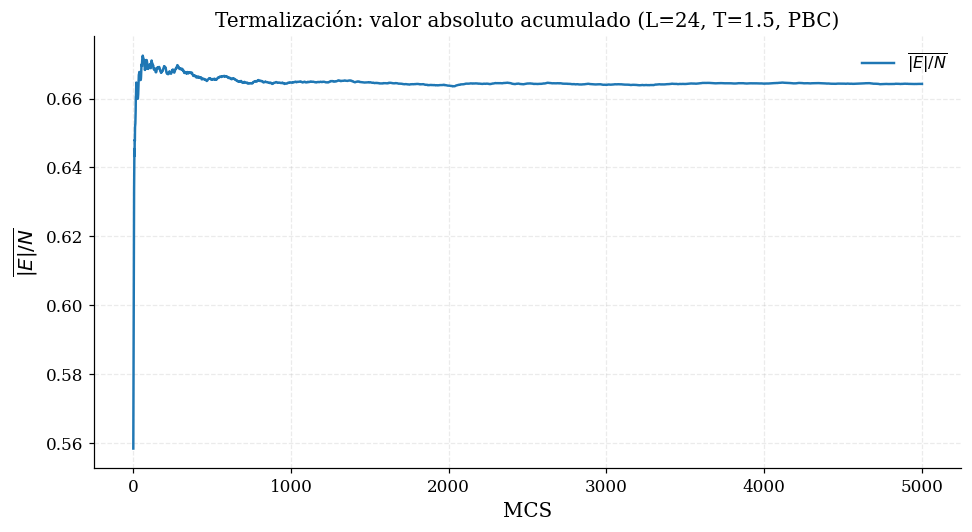

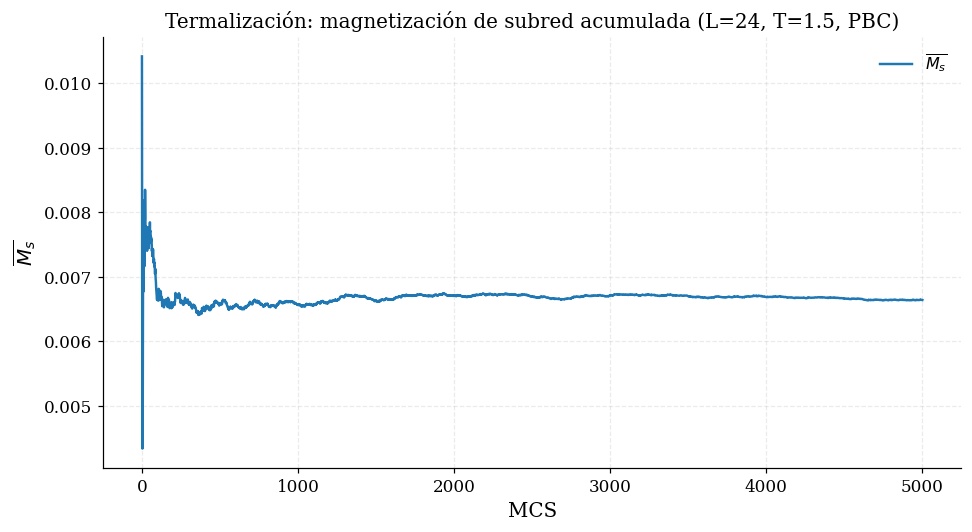

In [13]:
mcs = np.arange(
    1,
    NTERM_TEST + 1
)

# ------------------------------------------------------------
# Energía acumulada
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    mcs,
    cum_energy,
    label=r'$\overline{E/N}$'
)

plt.xlabel('MCS')
plt.ylabel(r'$\overline{E/N}$')
plt.title(
    f'Termalización: energía acumulada '
    f'(L={L_test}, T={T_test}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Valor absoluto de la energía
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    mcs,
    cum_abs_energy,
    label=r'$\overline{|E|/N}$'
)

plt.xlabel('MCS')
plt.ylabel(r'$\overline{|E|/N}$')
plt.title(
    f'Termalización: valor absoluto acumulado '
    f'(L={L_test}, T={T_test}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Magnetización de subred acumulada
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    mcs,
    cum_Ms,
    label=r'$\overline{M_s}$'
)

plt.xlabel('MCS')
plt.ylabel(r'$\overline{M_s}$')
plt.title(
    f'Termalización: magnetización de subred acumulada '
    f'(L={L_test}, T={T_test}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Energía instantánea vs. promedio acumulado

Conviene distinguir la energía instantánea $E(t)$ del promedio acumulado $\overline{E}(n)=\frac{1}{n}\sum_{t=1}^n E(t)$. Una trayectoria en equilibrio sigue fluctuando de todos modos, así que una serie $E(t)$ ruidosa no quiere decir que el sistema esté fuera de equilibrio; lo que buscamos es que desaparezca la deriva del promedio acumulado.

Para el cálculo de $C_v$ necesitamos además conservar las fluctuaciones de la energía, así que no conviene reemplazar $E$ por $|E|$ en los cálculos termodinámicos posteriores.

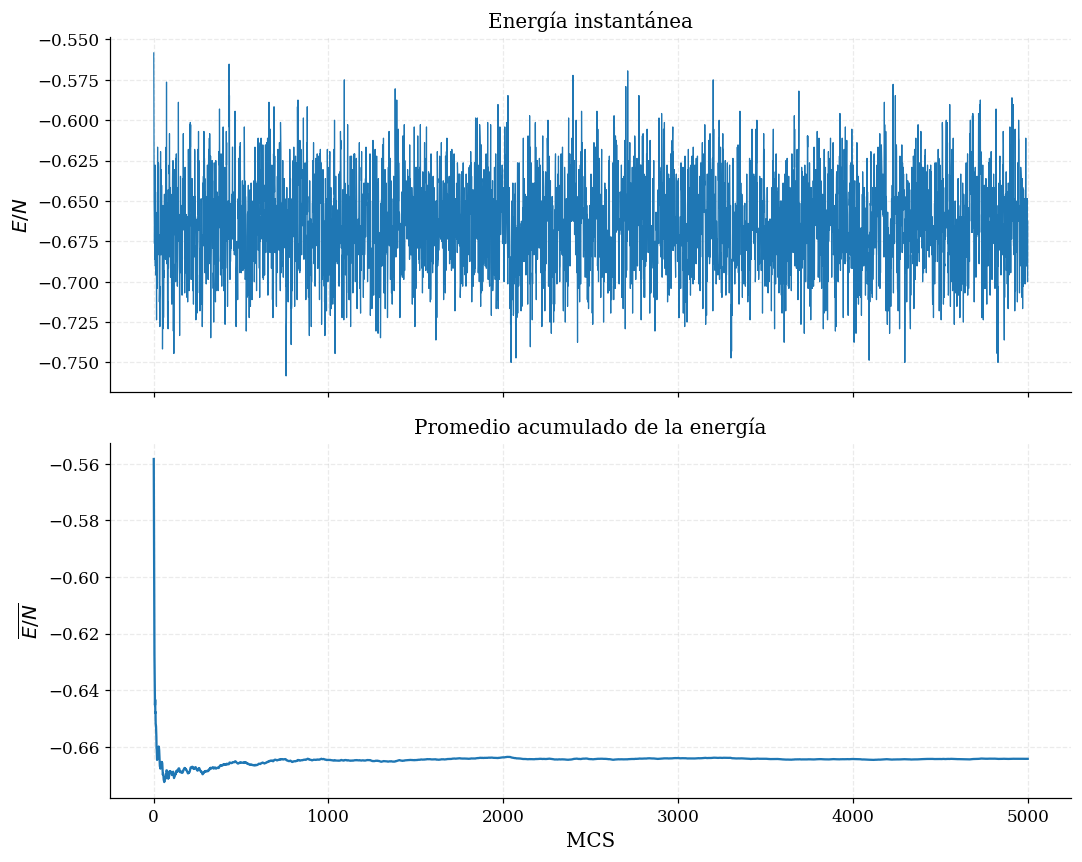

In [14]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True
)

# Energía instantánea
axes[0].plot(
    mcs,
    energy_series,
    linewidth=0.8
)

axes[0].set_ylabel(r'$E/N$')
axes[0].set_title(
    'Energía instantánea'
)
axes[0].grid(alpha=0.25)


# Promedio acumulado
axes[1].plot(
    mcs,
    cum_energy,
    linewidth=1.5
)

axes[1].set_xlabel('MCS')
axes[1].set_ylabel(r'$\overline{E/N}$')
axes[1].set_title(
    'Promedio acumulado de la energía'
)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 10. Termalización a distintas temperaturas

La velocidad de relajación no tiene por qué ser igual a todas las temperaturas, así que antes de fijar un $N_{\text{term}}$ único lo estudiamos en tres puntos representativos: $T=3.0$ (alta temperatura, dominan las fluctuaciones térmicas), $T=1.5$ (región intermedia) y $T=0.3$ (baja temperatura, donde puede haber orden y la relajación suele ser más lenta).

En cada temperatura partimos de una configuración aleatoria independiente —esto todavía no es el barrido definitivo, es solo un experimento para ver la escala de tiempo de relajación— y comparamos $\overline{E/N}(n)$, $\overline{|E|/N}(n)$ y $\overline{M_s}(n)$. Con esto queremos ver cuánto tarda en desaparecer la deriva sistemática. Para la producción final usaremos el barrido descendente con memoria completo, $3.0\to2.9\to\cdots\to0.1$.

In [15]:
# ============================================================
# DIAGNÓSTICO EN TRES TEMPERATURAS
# ============================================================

L_diag = 24
TEMPERATURES_DIAG = (3.0, 1.5, 0.3)
N_MCS_DIAG = 5000

# Tabla de vecinos para PBC
nn_diag, n_nn_diag, nnn_diag, n_nnn_diag = build_neighbor_tables(
    L_diag,
    periodic=True
)

diagnostic_results = {}

for i, T in enumerate(TEMPERATURES_DIAG):

    print(f"Ejecutando T = {T:.1f} ...")

    # Cada temperatura parte deliberadamente de una
    # configuración aleatoria diferente.
    spins = random_configuration(
        L_diag,
        seed=SEED + i
    )

    # Cada temperatura usa también su propia semilla para el generador
    # interno de Numba, en correspondencia con la de la configuración inicial.
    seed_numba_rng(SEED + i)

    results = thermalization_trace(
        spins,
        L_diag,
        T,
        J1,
        J2,
        h,
        nn_diag,
        n_nn_diag,
        nnn_diag,
        n_nnn_diag,
        N_MCS_DIAG
    )

    (
        energy_series,
        abs_energy_series,
        Ms_series,
        E_final,
        M_final,
        SA_final,
        SB_final
    ) = results

    diagnostic_results[T] = {
        "energy": energy_series,
        "abs_energy": abs_energy_series,
        "Ms": Ms_series,
        "E_final": E_final,
        "M_final": M_final,
        "SA_final": SA_final,
        "SB_final": SB_final,
    }

print("\n✓ Diagnóstico terminado.")

Ejecutando T = 3.0 ...
Ejecutando T = 1.5 ...
Ejecutando T = 0.3 ...

✓ Diagnóstico terminado.


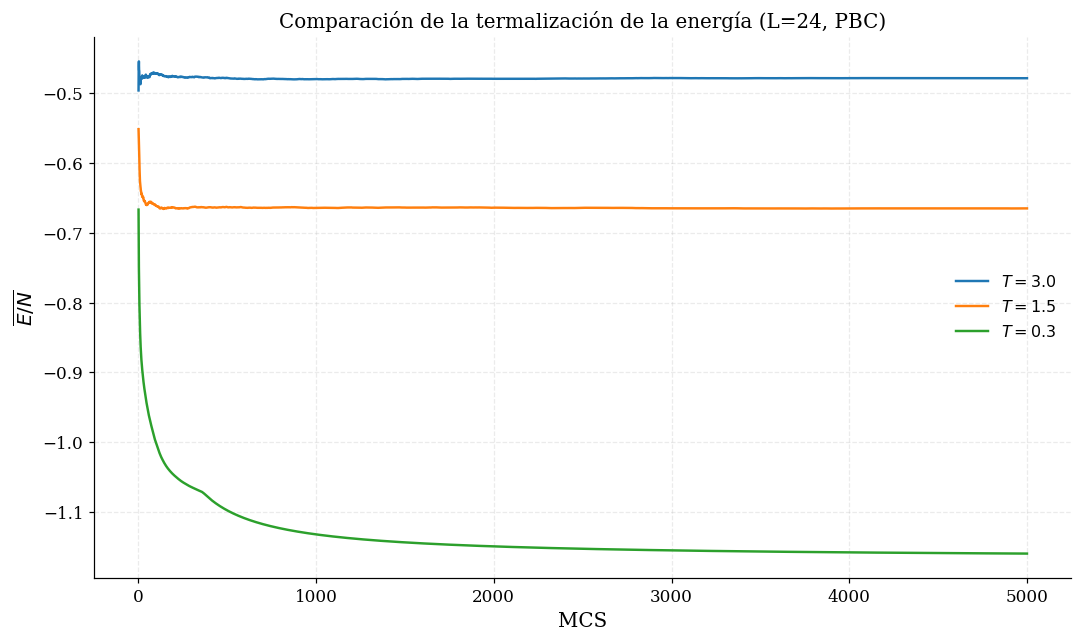

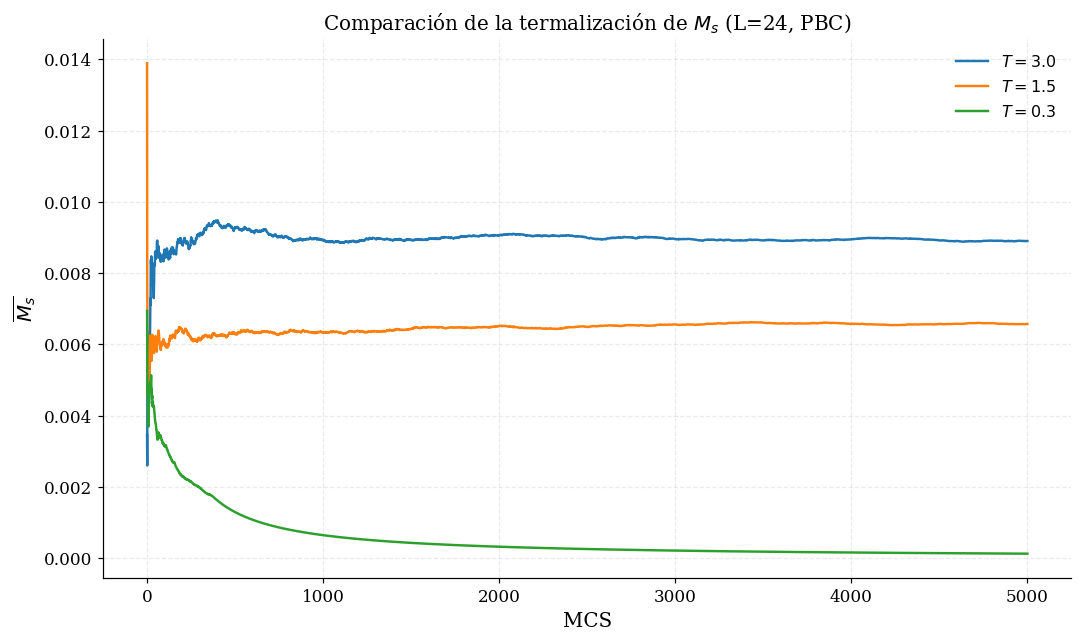

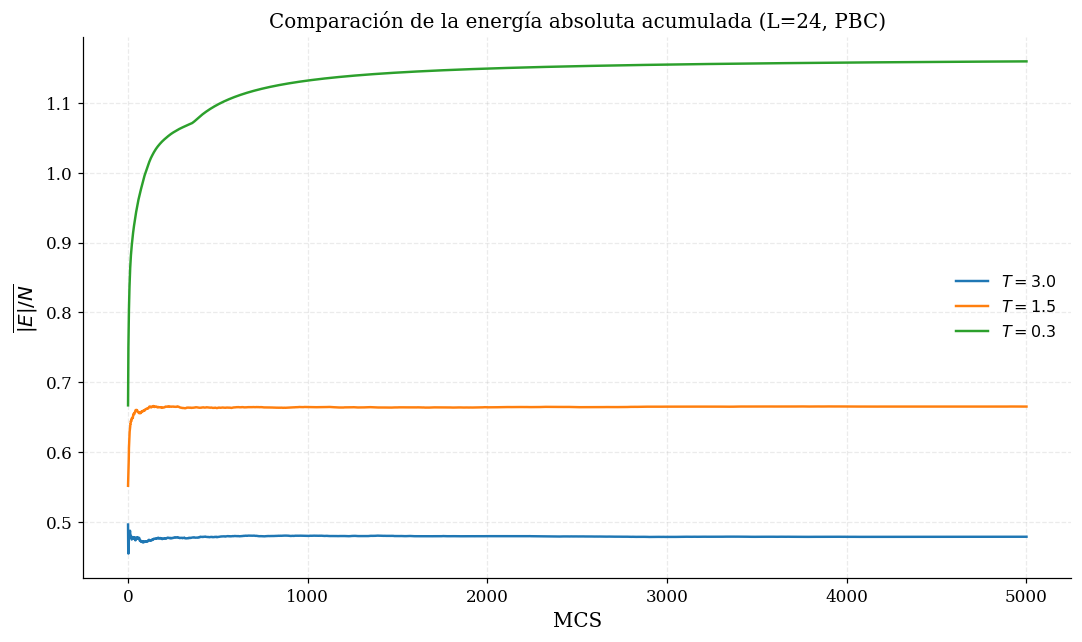

In [16]:
mcs_diag = np.arange(
    1,
    N_MCS_DIAG + 1
)


# ============================================================
# ENERGÍA ACUMULADA
# ============================================================

plt.figure(figsize=(10, 6))

for T in TEMPERATURES_DIAG:

    energy = diagnostic_results[T]["energy"]

    cumulative = cumulative_mean(energy)

    plt.plot(
        mcs_diag,
        cumulative,
        label=fr'$T={T:.1f}$'
    )

plt.xlabel('MCS')
plt.ylabel(r'$\overline{E/N}$')
plt.title(
    f'Comparación de la termalización de la energía '
    f'(L={L_diag}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# MAGNETIZACIÓN DE SUBRED ACUMULADA
# ============================================================

plt.figure(figsize=(10, 6))

for T in TEMPERATURES_DIAG:

    Ms = diagnostic_results[T]["Ms"]

    cumulative = cumulative_mean(Ms)

    plt.plot(
        mcs_diag,
        cumulative,
        label=fr'$T={T:.1f}$'
    )

plt.xlabel('MCS')
plt.ylabel(r'$\overline{M_s}$')
plt.title(
    f'Comparación de la termalización de $M_s$ '
    f'(L={L_diag}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# ENERGÍA ABSOLUTA ACUMULADA
# ============================================================

plt.figure(figsize=(10, 6))

for T in TEMPERATURES_DIAG:

    abs_energy = diagnostic_results[T]["abs_energy"]

    cumulative = cumulative_mean(abs_energy)

    plt.plot(
        mcs_diag,
        cumulative,
        label=fr'$T={T:.1f}$'
    )

plt.xlabel('MCS')
plt.ylabel(r'$\overline{|E|/N}$')
plt.title(
    f'Comparación de la energía absoluta acumulada '
    f'(L={L_diag}, PBC)'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Instantánea vs. acumulada, en las tres temperaturas

Para chequear si $N_{\text{term}}=5000$ alcanza, graficamos la evolución de la energía en las tres temperaturas de diagnóstico. La línea tenue es el ruido térmico real; la línea sólida es el promedio acumulado, que es lo que nos interesa que se estabilice.

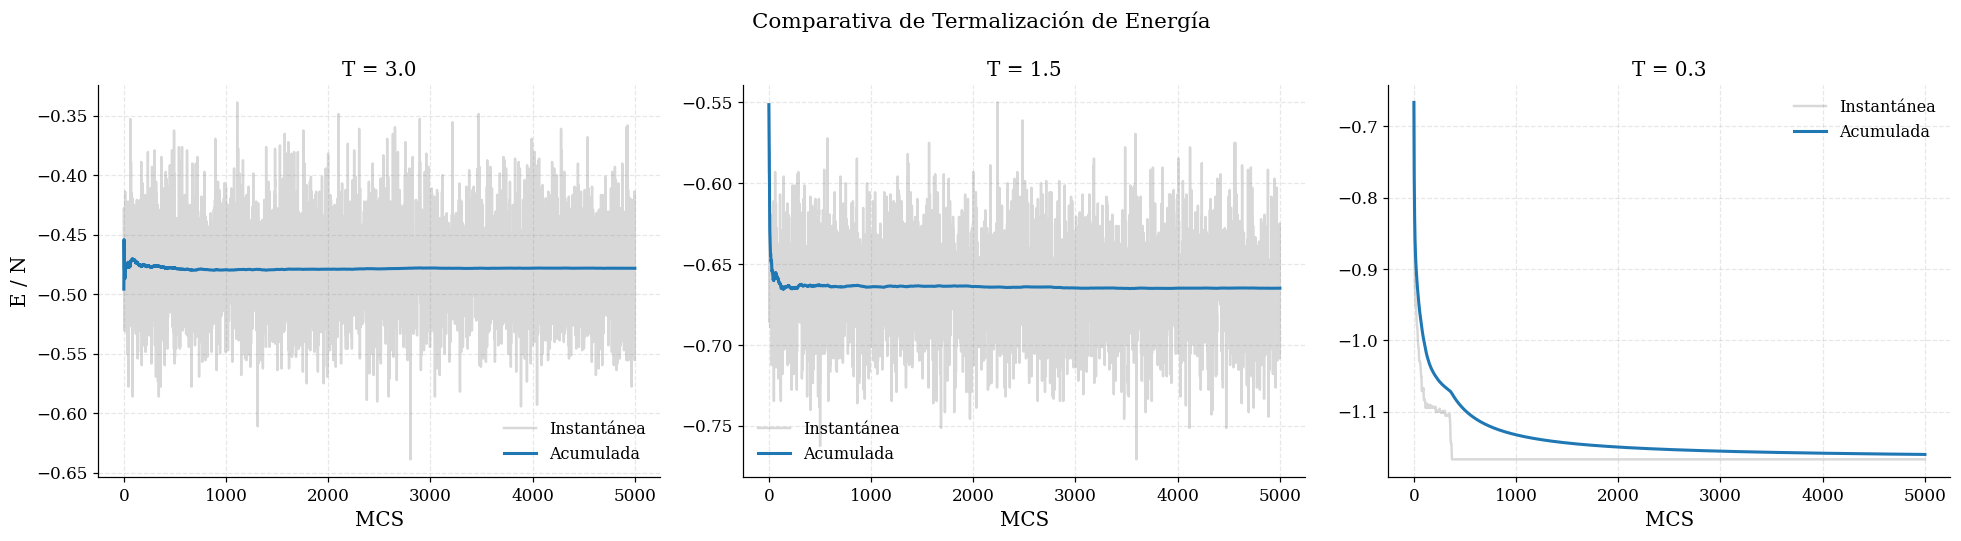

In [17]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=False
)

for i, T in enumerate(TEMPERATURES_DIAG):

    energy = diagnostic_results[T]['energy']
    cum_e = cumulative_mean(energy)
    mcs_axis = np.arange(1, len(energy) + 1)

    axes[i].plot(
        mcs_axis,
        energy,
        alpha=0.3,
        color='gray',
        label='Instantánea'
    )

    axes[i].plot(
        mcs_axis,
        cum_e,
        color='tab:blue',
        lw=2,
        label='Acumulada'
    )

    axes[i].set_title(f'T = {T:.1f}')
    axes[i].set_xlabel('MCS')

    if i == 0:
        axes[i].set_ylabel('E / N')

    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Comparativa de Termalización de Energía', fontsize=14)
plt.tight_layout()
plt.show()


### Estabilidad de $M_s$

Repetimos el mismo análisis para $M_s$. A $T=0.3$, si el sistema termina en la fase *stripe* en vez de la checkerboard, es esperable que $M_s$ se estabilice cerca de cero, porque no es el parámetro de orden adecuado para esa fase.

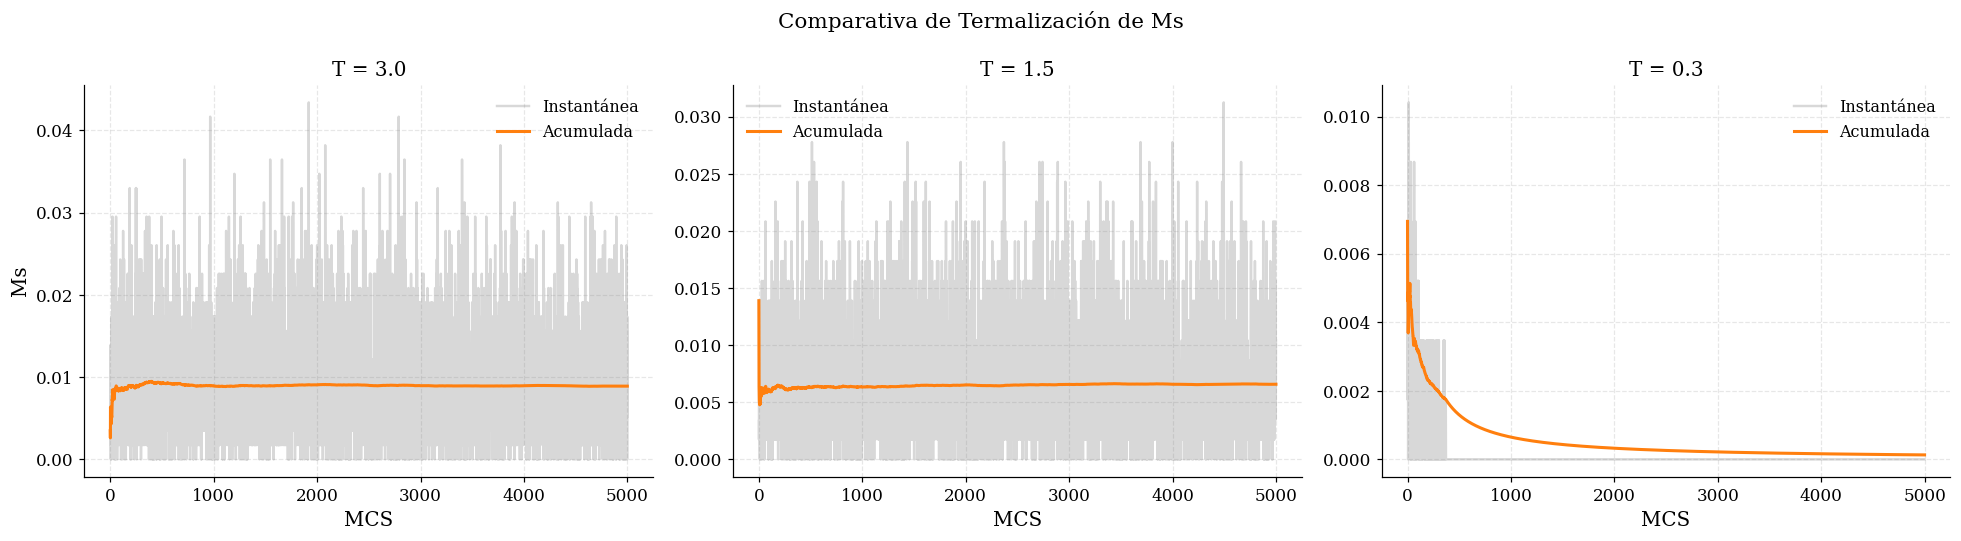

In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, T in enumerate(TEMPERATURES_DIAG):

    ms = diagnostic_results[T]['Ms']
    cum_ms = cumulative_mean(ms)

    axes[i].plot(
        ms,
        alpha=0.3,
        color='gray',
        label='Instantánea'
    )

    axes[i].plot(
        cum_ms,
        color='tab:orange',
        lw=2,
        label='Acumulada'
    )

    axes[i].set_title(f'T = {T:.1f}')
    axes[i].set_xlabel('MCS')

    if i == 0:
        axes[i].set_ylabel('Ms')

    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Comparativa de Termalización de Ms', fontsize=14)
plt.tight_layout()
plt.show()


In [19]:
def final_cumulative_change(values, tail_length=1000):
    """
    Compara el promedio acumulado final con el promedio acumulado
    al inicio de la última ventana.
    """
    values = np.asarray(values, dtype=np.float64)
    cumulative = np.cumsum(values) / np.arange(1, values.size + 1)
    n = values.size
    if tail_length >= n:
        return 0.0, 0.0
    final_value = cumulative[-1]
    previous_value = cumulative[-tail_length - 1]
    absolute_change = abs(final_value - previous_value)
    scale = max(abs(final_value), 1e-15)
    relative_change = absolute_change / scale
    return absolute_change, relative_change

# Criterio cuantitativo de convergencia (Plateau)
print(f"{'T':>6} | {'Delta E (rel)':>15} | {'Delta Ms (abs)':>15} | {'Estado'}")
print("-" * 60)

for T in TEMPERATURES_DIAG:
    energy = diagnostic_results[T]['energy']
    ms = diagnostic_results[T]['Ms']

    # Calculamos el cambio en el promedio acumulado en la última ventana de 1000 MCS
    abs_change_e, rel_change_e = final_cumulative_change(energy, tail_length=1000)
    abs_change_ms, _ = final_cumulative_change(ms, tail_length=1000)

    # Un criterio razonable es rel_change < 0.005 (0.5%)
    status = "CONVERGIDO" if rel_change_e < 0.005 else "DERIVA DETECTADA"

    print(f"{T:6.1f} | {rel_change_e:15.6e} | {abs_change_ms:15.6e} | {status}")

     T |   Delta E (rel) |  Delta Ms (abs) | Estado
------------------------------------------------------------
   3.0 |    2.061670e-04 |    5.034722e-05 | CONVERGIDO
   1.5 |    1.462141e-05 |    1.475694e-06 | CONVERGIDO
   0.3 |    1.482730e-03 |    3.246528e-05 | CONVERGIDO


## 11. Cambio del promedio acumulado al final de la corrida

Como chequeo adicional comparamos el promedio acumulado al final de la simulación con el que se tenía un poco antes:

$$
\Delta_{\text{rel}} =
\left|
\overline{X}(N_{\text{MCS}})
-
\overline{X}(N_{\text{MCS}} - 1000)
\right|.
$$

No es un criterio universal de equilibrio, simplemente una forma práctica de cuantificar cuánta deriva residual queda. Si $\Delta_{\text{rel}}$ es pequeño, el promedio acumulado casi no cambió en el último tramo.

In [20]:
# Reutiliza la función final_cumulative_change definida en la
# Sección 10 para cuantificar la deriva residual del promedio
# acumulado en el último tramo de cada corrida.

print(
    f"{'T':>6} "
    f"{'Δ(E/N)':>14} "
    f"{'Δrel(E/N)':>14} "
    f"{'ΔMs':>14}"
)

print("-" * 52)


for T in TEMPERATURES_DIAG:

    energy = diagnostic_results[T]["energy"]
    Ms = diagnostic_results[T]["Ms"]

    delta_E, rel_E = final_cumulative_change(
        energy,
        tail_length=1000
    )

    delta_Ms, _ = final_cumulative_change(
        Ms,
        tail_length=1000
    )

    print(
        f"{T:6.1f} "
        f"{delta_E:14.6e} "
        f"{rel_E:14.6e} "
        f"{delta_Ms:14.6e}"
    )


     T         Δ(E/N)      Δrel(E/N)            ΔMs
----------------------------------------------------
   3.0   9.861111e-05   2.061670e-04   5.034722e-05
   1.5   9.722222e-06   1.462141e-05   1.475694e-06
   0.3   1.719653e-03   1.482730e-03   3.246528e-05


## 12. Verificación del estado fundamental

Antes de lanzar la producción conviene saber qué tipo de orden favorece el Hamiltoniano con $J_1=1$, $J_2=-0.6$. Comparamos la energía por espín $e=E/N$ de tres configuraciones de referencia: ferromagnética, antiferromagnética *checkerboard* y ordenada en franjas (*stripe*).

Esto no reemplaza la simulación Monte Carlo; es solo una referencia física para interpretar lo que veamos a baja temperatura. En particular, si el sistema termina con una energía cercana a la del estado *stripe* pero el $M_s$ definido en el enunciado sale pequeño, eso confirmaría que $M_s$ (que es el parámetro de orden checkerboard) simplemente no detecta ese tipo de orden. De todas formas seguimos calculando $M_s$ exactamente como lo pide el enunciado.

In [21]:
def ferromagnetic_configuration(L):
    """
    Todos los espines apuntan en la misma dirección.
    """
    return np.ones(L * L, dtype=np.int8)


def checkerboard_configuration(L):
    """
    Configuración AFM checkerboard:

        S(x,y) = (-1)^(x+y)
    """
    spins = np.empty(L * L, dtype=np.int8)

    for x in range(L):
        for y in range(L):

            i = x * L + y

            spins[i] = 1 if (x + y) % 2 == 0 else -1

    return spins


def stripe_configuration(L, direction="x"):
    """
    Configuración stripe.

    direction='x':
        la orientación alterna con x.

    direction='y':
        la orientación alterna con y.
    """

    spins = np.empty(L * L, dtype=np.int8)

    for x in range(L):
        for y in range(L):

            i = x * L + y

            if direction == "x":
                spins[i] = 1 if x % 2 == 0 else -1

            elif direction == "y":
                spins[i] = 1 if y % 2 == 0 else -1

            else:
                raise ValueError(
                    "direction debe ser 'x' o 'y'."
                )

    return spins

In [22]:
# ============================================================
# COMPARACIÓN DE CONFIGURACIONES
# ============================================================

L_ground = 24

nn_g, n_nn_g, nnn_g, n_nnn_g = build_neighbor_tables(
    L_ground,
    periodic=True
)

configurations = {
    "ferromagnetic": ferromagnetic_configuration(L_ground),
    "checkerboard": checkerboard_configuration(L_ground),
    "stripe_x": stripe_configuration(L_ground, "x"),
    "stripe_y": stripe_configuration(L_ground, "y"),
}

print(
    f"{'Configuración':<20}"
    f"{'E/N':>15}"
    f"{'M_s':>15}"
)

print("-" * 50)

for name, spins in configurations.items():

    E, M = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn_g,
        n_nn_g,
        nnn_g,
        n_nnn_g
    )

    M_total, SA, SB, _, _ = initialize_all_observables(
        spins,
        L_ground
    )

    N_ground = L_ground * L_ground

    Ms = abs(SA - SB) / (2.0 * N_ground)

    print(
        f"{name:<20}"
        f"{E / N_ground:>15.6f}"
        f"{Ms:>15.6f}"
    )


Configuración                   E/N            M_s
--------------------------------------------------
ferromagnetic             -0.800000       0.000000
checkerboard               3.200000       0.500000
stripe_x                  -1.200000       0.000000
stripe_y                  -1.200000       0.000000


## 13. Simulación a una temperatura fija

Para cada temperatura distinguimos dos etapas: **termalización**, donde se corren $N_{\text{term}}$ MCS que se descartan (sirve para que la configuración pierda memoria de su estado anterior), y **muestreo**, donde se corren $N_{\text{muestra}}$ MCS y se acumulan los momentos $\langle E\rangle$, $\langle E^2\rangle$, $\langle M_s\rangle$, $\langle M_s^2\rangle$, $\langle M_s^4\rangle$ necesarios.

A partir de esos momentos se calculan las cantidades pedidas en el enunciado:

$$
C_v = \frac{\langle E^2 \rangle - \langle E \rangle^2}{N k_B T^2},
\qquad
\chi_s = \frac{N}{k_B T} \left( \langle M_s^2 \rangle - \langle M_s \rangle^2 \right),
\qquad
U = 1 - \frac{\langle M_s^4 \rangle}{3 \langle M_s^2 \rangle^2}.
$$

In [23]:
@njit
def simulate_temperature(spins, L, T, J1, J2, h, nn, n_nn, nnn, n_nnn, nterm, nmuestra, nblocks=NBLOCKS):
    """
    Motor de simulación de producción, con estimación de incertidumbre
    estadística por el método de bloques (ver Sección 8.1).

    Calcula, de forma independiente, dos parámetros de orden:

        Ms       : magnetización de subred checkerboard, tal como la
                   define la Ec. (2) del enunciado (usa SA, SB).
        m_stripe : parámetro de orden stripe, sqrt(mx^2 + my^2)
                   (usa SX, SY), consistente con la Sección 15.

    De cada uno se derivan su propia susceptibilidad (Ec. 5) y su
    propio cumulante de Binder (Ec. 6). La etapa de muestreo se
    divide en `nblocks` bloques; dentro de cada bloque se recalculan
    todas las cantidades con las mismas fórmulas que sobre la corrida
    completa, y el promedio final es el promedio de los bloques,
    mientras que el error reportado es la desviación estándar de la
    media entre bloques (SEM), que sí tiene en cuenta la
    autocorrelación temporal de la cadena de Metrópolis.

    La etapa de muestreo ejecuta block_size = nmuestra // nblocks
    MCS por bloque, así que conviene elegir nmuestra como múltiplo
    de nblocks para usar exactamente los nmuestra MCS solicitados.

    Devuelve 10 promedios seguidos de sus 9 errores estándar
    (la tasa de aceptación no lleva barra de error asociada):

        mE, mM, mMs, mCv, mchi_s, mU_s,
        mMstripe, mchi_stripe, mU_stripe, acceptance,
        E_err, M_err, Ms_err, Cv_err, chi_s_err, U_s_err,
        mstripe_err, chi_stripe_err, U_stripe_err
    """
    N = spins.size
    beta = 1.0 / (kB * T)
    table = build_accept_table(J1, J2, h, beta)

    # Inicialización de observables
    energy, _ = compute_energy(spins, J1, J2, h, nn, n_nn, nnn, n_nnn)
    M, SA, SB, SX, SY = initialize_all_observables(spins, L)

    # Etapa de Termalización (no entra en la estadística)
    for _ in range(nterm):
        energy, M, SA, SB, SX, SY, _ = metropolis_mcs(spins, L, table, J1, J2, h, nn, n_nn, nnn, n_nnn, energy, M, SA, SB, SX, SY)

    # Etapa de Muestreo, dividida en bloques
    block_size = nmuestra // nblocks
    n_used = block_size * nblocks

    E_blk = np.empty(nblocks)
    M_blk = np.empty(nblocks)
    Ms_blk = np.empty(nblocks)
    Cv_blk = np.empty(nblocks)
    chis_blk = np.empty(nblocks)
    Us_blk = np.empty(nblocks)
    mstripe_blk = np.empty(nblocks)
    chistripe_blk = np.empty(nblocks)
    Ustripe_blk = np.empty(nblocks)

    total_accepted = 0

    for b in range(nblocks):

        acc_E, acc_E2, acc_M = 0.0, 0.0, 0.0
        acc_Ms, acc_Ms2, acc_Ms4 = 0.0, 0.0, 0.0
        acc_mstripe, acc_mstripe2, acc_mstripe4 = 0.0, 0.0, 0.0

        for _ in range(block_size):
            energy, M, SA, SB, SX, SY, accepted = metropolis_mcs(spins, L, table, J1, J2, h, nn, n_nn, nnn, n_nnn, energy, M, SA, SB, SX, SY)

            # Ec. (2): magnetización de subred checkerboard
            ms_val = abs(SA - SB) / (2.0 * N)

            # Sección 15: orden stripe
            mx = SX / N
            my = SY / N
            mstripe_val = np.sqrt(mx * mx + my * my)

            acc_E += energy
            acc_E2 += energy**2
            acc_M += M

            acc_Ms += ms_val
            acc_Ms2 += ms_val**2
            acc_Ms4 += ms_val**4

            acc_mstripe += mstripe_val
            acc_mstripe2 += mstripe_val**2
            acc_mstripe4 += mstripe_val**4

            total_accepted += accepted

        mE_b = acc_E / block_size
        mM_b = acc_M / block_size
        mMs_b = acc_Ms / block_size
        mMs2_b = acc_Ms2 / block_size
        mMstripe_b = acc_mstripe / block_size
        mMstripe2_b = acc_mstripe2 / block_size

        E_blk[b] = mE_b
        M_blk[b] = mM_b
        Ms_blk[b] = mMs_b

        Cv_blk[b] = (acc_E2 / block_size - mE_b**2) / (N * kB * T**2)
        chis_blk[b] = (N / (kB * T)) * (mMs2_b - mMs_b**2)
        Us_blk[b] = 1.0 - (acc_Ms4 / block_size) / (3.0 * mMs2_b**2 + 1e-15)

        mstripe_blk[b] = mMstripe_b
        chistripe_blk[b] = (N / (kB * T)) * (mMstripe2_b - mMstripe_b**2)
        Ustripe_blk[b] = 1.0 - (acc_mstripe4 / block_size) / (3.0 * mMstripe2_b**2 + 1e-15)

    # Promedios finales: promedio de los promedios de bloque
    mE = np.mean(E_blk)
    mM = np.mean(M_blk)
    mMs = np.mean(Ms_blk)
    mCv = np.mean(Cv_blk)
    mchi_s = np.mean(chis_blk)
    mU_s = np.mean(Us_blk)
    mMstripe = np.mean(mstripe_blk)
    mchi_stripe = np.mean(chistripe_blk)
    mU_stripe = np.mean(Ustripe_blk)

    # Errores estándar de la media (desviación estándar entre bloques / sqrt(nblocks))
    sqrt_nb = np.sqrt(nblocks)
    E_err = np.std(E_blk) / sqrt_nb
    M_err = np.std(M_blk) / sqrt_nb
    Ms_err = np.std(Ms_blk) / sqrt_nb
    Cv_err = np.std(Cv_blk) / sqrt_nb
    chi_s_err = np.std(chis_blk) / sqrt_nb
    U_s_err = np.std(Us_blk) / sqrt_nb
    mstripe_err = np.std(mstripe_blk) / sqrt_nb
    chi_stripe_err = np.std(chistripe_blk) / sqrt_nb
    U_stripe_err = np.std(Ustripe_blk) / sqrt_nb

    acceptance = total_accepted / (n_used * N)

    return (mE, mM, mMs, mCv, mchi_s, mU_s, mMstripe, mchi_stripe, mU_stripe, acceptance,
            E_err, M_err, Ms_err, Cv_err, chi_s_err, U_s_err, mstripe_err, chi_stripe_err, U_stripe_err)


## 14. Barrido térmico descendente

El barrido definitivo va de alta a baja temperatura, $3.0\to2.9\to\cdots\to0.1$. Se parte de una configuración aleatoria y, en cada temperatura, se termaliza, se descarta esa parte, se muestrea, se calculan los observables y se guarda la configuración final para usarla como punto de partida de la siguiente temperatura.

Como las configuraciones de temperaturas consecutivas son físicamente parecidas, el sistema no tiene que reconstruir su estado térmico desde cero en cada punto, lo que ahorra bastante tiempo de cómputo. Eso sí, conservar memoria entre temperaturas no elimina la necesidad de termalizar en cada una.

In [24]:
def run_temperature_sweep(
    L,
    periodic,
    temperatures,
    nterm,
    nmuestra,
    seed=None,
    J1=1.0,
    J2=-0.6,
    h=0.0,
    nblocks=NBLOCKS
):
    """
    Ejecuta un barrido térmico descendente con memoria.

    Devuelve un diccionario con todos los observables exigidos por la
    tarea (Ms, chi_s, binder) y el diagnóstico stripe (mstripe,
    chi_stripe, binder_stripe), cada uno acompañado de su error
    estándar (clave `<observable>_err`), estimado por el método de
    bloques de la Sección 8.1.
    """

    # --------------------------------------------------------
    # Tablas de vecinos
    # --------------------------------------------------------

    nn, n_nn, nnn, n_nnn = build_neighbor_tables(
        L,
        periodic=periodic
    )

    # --------------------------------------------------------
    # Configuración inicial aleatoria
    # --------------------------------------------------------

    spins = random_configuration(
        L,
        seed=seed
    )

    # Sembramos el generador interno de Numba UNA sola vez, al comienzo
    # de todo el barrido (y no en cada temperatura), para que la corrida
    # completa sea reproducible sin introducir correlaciones artificiales
    # entre temperaturas consecutivas.
    if seed is not None:
        seed_numba_rng(seed)

    # --------------------------------------------------------
    # Arrays de resultados
    # --------------------------------------------------------

    nT = len(temperatures)

    # Sincronizado con simulate_temperature (10 promedios + 9 errores)
    mean_keys = [
        "E", "M", "Ms", "Cv", "chi_s", "binder",
        "mstripe", "chi_stripe", "binder_stripe", "acceptance"
    ]
    err_keys = [
        "E_err", "M_err", "Ms_err", "Cv_err", "chi_s_err", "binder_err",
        "mstripe_err", "chi_stripe_err", "binder_stripe_err"
    ]
    keys = mean_keys + err_keys

    out = {k: np.empty(nT) for k in keys}

    # --------------------------------------------------------
    # Barrido térmico
    # --------------------------------------------------------

    for index, T in enumerate(temperatures):

        print(
            f"L={L:2d} | "
            f"{'PBC' if periodic else 'FBC'} | "
            f"T={T:.1f}"
        )

        results = simulate_temperature(
            spins,
            L,
            T,
            J1,
            J2,
            h,
            nn,
            n_nn,
            nnn,
            n_nnn,
            nterm,
            nmuestra,
            nblocks
        )

        for k, v in zip(keys, results):
            out[k][index] = v

    out.update({
        "T": np.asarray(temperatures),
        "final_spins": spins.copy(),
        "L": L,
        "periodic": periodic,
        "J1": J1,
        "J2": J2,
        "h": h,
        "Nterm": nterm,
        "Nmuestra": nmuestra,
        "Nbloques": nblocks,
    })

    return out


In [25]:
# ============================================================
# PRIMER BARRIDO COMPLETO
# ============================================================

t0_L24_PBC = time.perf_counter()

results_L24_PBC = run_temperature_sweep(
    L=24,
    periodic=True,
    temperatures=TEMPERATURES,
    nterm=5000,
    nmuestra=10000,
    seed=SEED,
    J1=J1,
    J2=J2,
    h=0.0
)

# Guardamos las mismas claves que usará run_production_case más adelante,
# para poder reutilizar esta corrida en la producción final (Sección 23)
# en lugar de recalcularla desde cero.
results_L24_PBC["boundary_name"] = "PBC"
results_L24_PBC["runtime_seconds"] = time.perf_counter() - t0_L24_PBC

print("\n✓ Barrido completado.")

L=24 | PBC | T=3.0
L=24 | PBC | T=2.9
L=24 | PBC | T=2.8
L=24 | PBC | T=2.7
L=24 | PBC | T=2.6
L=24 | PBC | T=2.5
L=24 | PBC | T=2.4
L=24 | PBC | T=2.3
L=24 | PBC | T=2.2
L=24 | PBC | T=2.1
L=24 | PBC | T=2.0
L=24 | PBC | T=1.9
L=24 | PBC | T=1.8
L=24 | PBC | T=1.7
L=24 | PBC | T=1.6
L=24 | PBC | T=1.5
L=24 | PBC | T=1.4
L=24 | PBC | T=1.3
L=24 | PBC | T=1.2
L=24 | PBC | T=1.1
L=24 | PBC | T=1.0
L=24 | PBC | T=0.9
L=24 | PBC | T=0.8
L=24 | PBC | T=0.7
L=24 | PBC | T=0.6
L=24 | PBC | T=0.5
L=24 | PBC | T=0.4
L=24 | PBC | T=0.3
L=24 | PBC | T=0.2
L=24 | PBC | T=0.1

✓ Barrido completado.


In [26]:
def sort_results_by_temperature(results):
    """
    Devuelve una copia de los resultados ordenada de menor a mayor T.
    """

    order = np.argsort(results["T"])

    sorted_results = {}

    for key, value in results.items():

        if isinstance(value, np.ndarray) and value.ndim == 1:

            sorted_results[key] = value[order]

        else:

            sorted_results[key] = value

    return sorted_results


results_plot = sort_results_by_temperature(
    results_L24_PBC
)

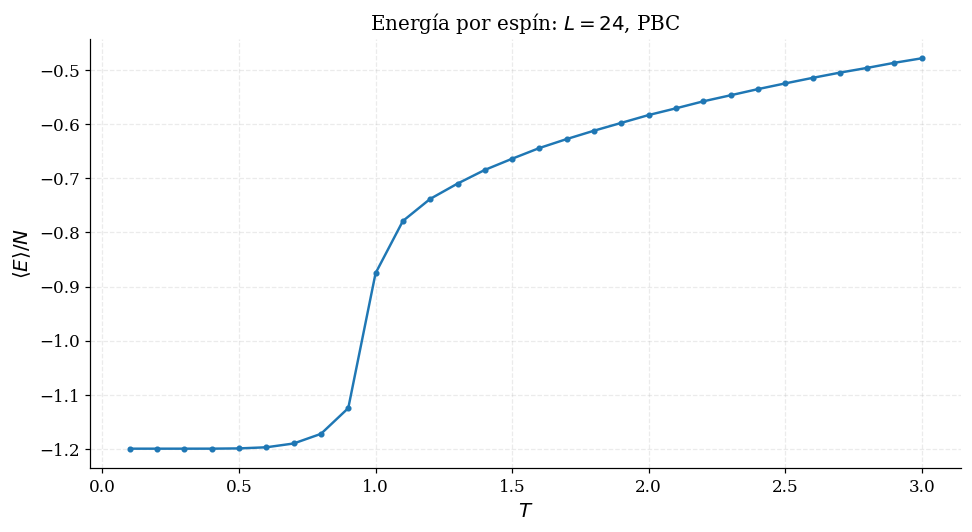

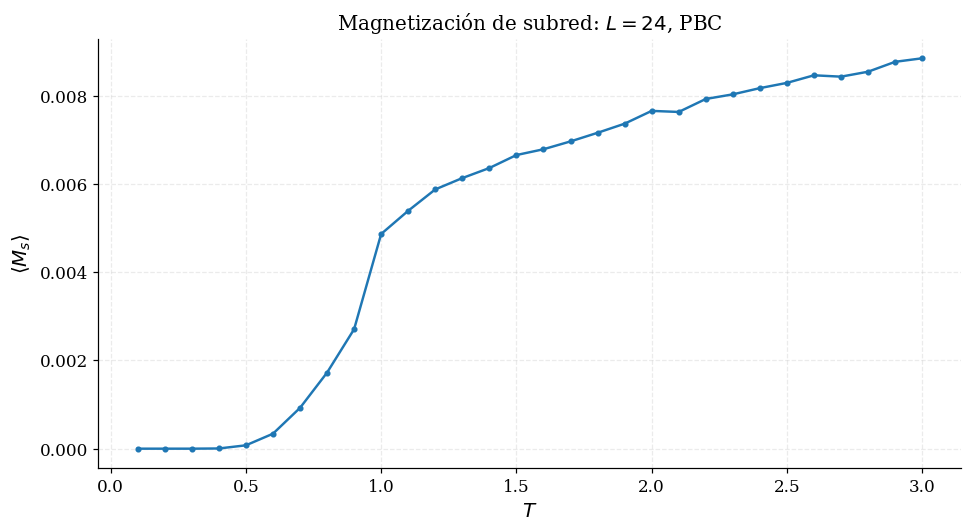

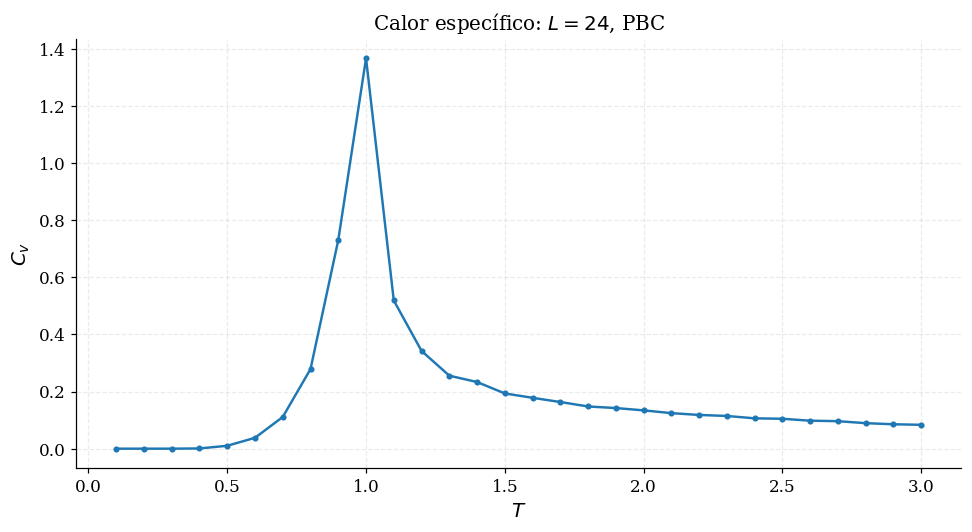

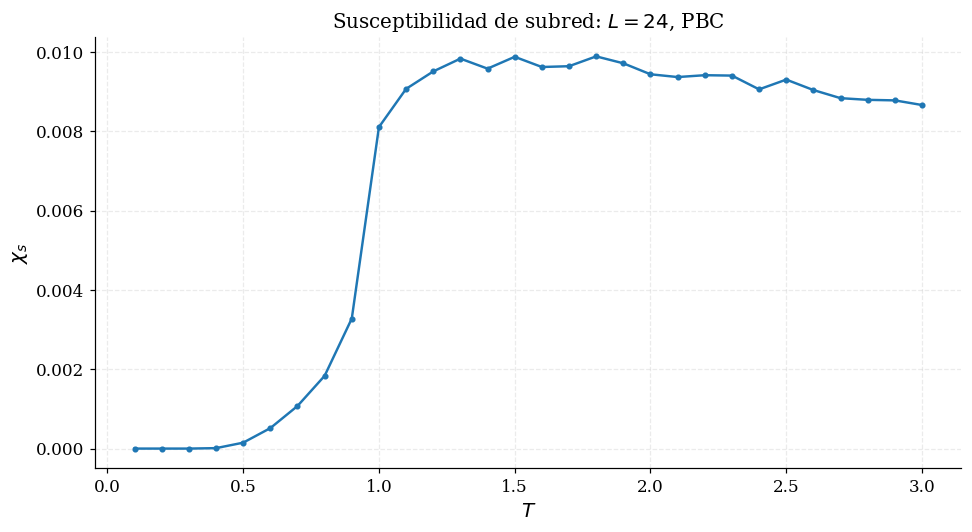

In [27]:
# ============================================================
# ENERGÍA POR ESPÍN
# ============================================================

T_plot = results_plot["T"]
e_plot = results_plot["E"] / (24 * 24)

plt.figure(figsize=(9, 5))

plt.plot(
    T_plot,
    e_plot,
    marker='o',
    markersize=3
)

plt.xlabel(r'$T$')
plt.ylabel(r'$\langle E\rangle/N$')
plt.title(r'Energía por espín: $L=24$, PBC')

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# MAGNETIZACIÓN DE SUBRED
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    T_plot,
    results_plot["Ms"],
    marker='o',
    markersize=3
)

plt.xlabel(r'$T$')
plt.ylabel(r'$\langle M_s\rangle$')
plt.title(r'Magnetización de subred: $L=24$, PBC')

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# CALOR ESPECÍFICO
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    T_plot,
    results_plot["Cv"],
    marker='o',
    markersize=3
)

plt.xlabel(r'$T$')
plt.ylabel(r'$C_v$')
plt.title(r'Calor específico: $L=24$, PBC')

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# SUSCEPTIBILIDAD
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    T_plot,
    results_plot["chi_s"],
    marker='o',
    markersize=3
)

plt.xlabel(r'$T$')
plt.ylabel(r'$\chi_s$')
plt.title(r'Susceptibilidad de subred: $L=24$, PBC')

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 15. Parámetro de orden *stripe* (diagnóstico complementario)

$M_s$ se calcula exactamente como lo pide el enunciado, pero la comparación de energías de la sección anterior sugiere que para $J_1=1$, $J_2=-0.6$ el estado de menor energía es tipo *stripe*, no checkerboard. Por eso introducimos, solo como diagnóstico, un parámetro de orden adicional:

$$
m_x = \frac{1}{N} \sum_{x,y} (-1)^x S_{x,y},
\qquad
m_y = \frac{1}{N} \sum_{x,y} (-1)^y S_{x,y},
\qquad
m_{\mathrm{stripe}} = \sqrt{m_x^2 + m_y^2},
$$

donde $m_x$ y $m_y$ detectan franjas en direcciones perpendiculares. Este observable no reemplaza a $M_s$ en los resultados pedidos por la tarea; simplemente nos ayuda a interpretar físicamente la fase que realmente aparece en la simulación.

In [28]:
@njit
def stripe_order_parameters(spins, L):
    """
    Calcula los parámetros de orden stripe en las dos direcciones.

    mx = (1/N) sum_x,y (-1)^x S(x,y)
    my = (1/N) sum_x,y (-1)^y S(x,y)
    """

    N = spins.size

    mx = 0.0
    my = 0.0

    for x in range(L):
        for y in range(L):

            i = x * L + y
            s = spins[i]

            if x % 2 == 0:
                mx += s
            else:
                mx -= s

            if y % 2 == 0:
                my += s
            else:
                my -= s

    mx /= N
    my /= N

    mstripe = np.sqrt(
        mx * mx + my * my
    )

    return mx, my, mstripe

In [29]:
print(
    f"{'Configuración':<20}"
    f"{'E/N':>12}"
    f"{'M_s':>12}"
    f"{'m_x':>12}"
    f"{'m_y':>12}"
    f"{'m_stripe':>14}"
)

print("-" * 84)

for name, spins in configurations.items():

    E, M = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn_g,
        n_nn_g,
        nnn_g,
        n_nnn_g
    )

    M_total, SA, SB, _, _ = initialize_all_observables(
        spins,
        L_ground
    )

    N_ground = L_ground * L_ground

    Ms = abs(SA - SB) / (2.0 * N_ground)

    mx, my, mstripe = stripe_order_parameters(
        spins,
        L_ground
    )

    print(
        f"{name:<20}"
        f"{E/N_ground:>12.6f}"
        f"{Ms:>12.6f}"
        f"{mx:>12.6f}"
        f"{my:>12.6f}"
        f"{mstripe:>14.6f}"
    )


Configuración                E/N         M_s         m_x         m_y      m_stripe
------------------------------------------------------------------------------------
ferromagnetic          -0.800000    0.000000    0.000000    0.000000      0.000000
checkerboard            3.200000    0.500000    0.000000    0.000000      0.000000
stripe_x               -1.200000    0.000000    1.000000    0.000000      1.000000
stripe_y               -1.200000    0.000000    0.000000    1.000000      1.000000


Como se vio arriba, el estado *stripe* es el de menor energía para $J_1=1$, $J_2=-0.6$. Los observables $m_x$, $m_y$ y $m_{\mathrm{stripe}}$ ya se calculan de forma incremental durante el muestreo (a través de $S_X$ y $S_Y$, definidos en la Sección 4 y actualizados en `metropolis_mcs`), así que no hace falta ningún cálculo extra para incorporarlos a la producción. La prueba siguiente confirma que a baja temperatura `simulate_temperature` reporta un $m_{\mathrm{stripe}}$ apreciable aun cuando $M_s$ sale pequeño.

In [30]:
# ============================================================
# PRUEBA DEL DIAGNÓSTICO STRIPE A BAJA TEMPERATURA
# ============================================================

L_stripe_test = 24
T_stripe_test = 0.3

nn_s, n_nn_s, nnn_s, n_nnn_s = build_neighbor_tables(
    L_stripe_test,
    periodic=True
)

spins_s = random_configuration(
    L_stripe_test,
    seed=SEED
)

seed_numba_rng(SEED)

# La función simulate_temperature devuelve 19 valores (10 promedios + 9 errores):
# mE, mM, mMs, mCv, mchi_s, mU_s, mMstripe, mchi_stripe, mU_stripe, acceptance,
# E_err, M_err, Ms_err, Cv_err, chi_s_err, U_s_err, mstripe_err, chi_stripe_err, U_stripe_err
results_tuple = simulate_temperature(
    spins_s,
    L_stripe_test,
    T_stripe_test,
    J1,
    J2,
    0.0,
    nn_s,
    n_nn_s,
    nnn_s,
    n_nnn_s,
    nterm=5000,
    nmuestra=5000
)

(
    E_s,
    M_total_s,
    Ms_s,
    Cv_s,
    chi_s_s,
    binder_s,
    mstripe_s,
    chi_stripe_s,
    binder_stripe_s,
    acceptance_s,
    E_err_s,
    M_err_s,
    Ms_err_s,
    Cv_err_s,
    chi_s_err_s,
    binder_err_s,
    mstripe_err_s,
    chi_stripe_err_s,
    binder_stripe_err_s
) = results_tuple

N_s = L_stripe_test ** 2

print(f"L = {L_stripe_test}")
print(f"T = {T_stripe_test}")
print()
print(f"<E>/N            = {E_s/N_s:.6f}")
print(f"<M> (Total)      = {M_total_s/N_s:.6f}")
print(f"<M_s> (Subred)   = {Ms_s:.6f}")
print(f"<m_stripe>       = {mstripe_s:.6f}")
print(f"C_v              = {Cv_s:.6f}")
print(f"chi_s            = {chi_s_s:.6f}")
print(f"chi_stripe       = {chi_stripe_s:.6f}")
print(f"Binder (M_s)     = {binder_s:.6f}")
print(f"Binder (stripe)  = {binder_stripe_s:.6f}")
print(f"Aceptación       = {acceptance_s:.6e}")

L = 24
T = 0.3

<E>/N            = -1.200000
<M> (Total)      = 0.000000
<M_s> (Subred)   = 0.000000
<m_stripe>       = 1.000000
C_v              = 0.000000
chi_s            = 0.000000
chi_stripe       = 0.000000
Binder (M_s)     = 1.000000
Binder (stripe)  = 0.666667
Aceptación       = 0.000000e+00


## 16. Enfriamiento con memoria vs. inicialización aleatoria

La estrategia de enfriamiento con memoria consiste en usar la configuración equilibrada a $T_i$ como punto de partida para $T_{i+1}=T_i-\Delta T$. Aquí la comparamos con inicializar aleatoriamente y bajar directo a baja temperatura, para ver si la memoria térmica realmente ayuda a explorar mejor el espacio de configuraciones y evita que el algoritmo quede atrapado en estados de energía relativamente alta.

Comparamos $\langle E\rangle/N$, $\langle m_{\text{stripe}}\rangle$ y la tasa de aceptación. No esperamos que el sistema se mantenga estático al bajar la temperatura, sino una evolución gradual hacia estados de menor energía y mayor orden *stripe*.

In [31]:
# ============================================================
# ENFRIAMIENTO CON MEMORIA
# ============================================================

L_cooling = 24

T_cooling = np.array([
    3.0,
    2.5,
    2.0,
    1.5,
    1.0,
    0.8,
    0.6,
    0.5,
    0.4,
    0.3
])

cooling_results = run_temperature_sweep(
    L=L_cooling,
    periodic=True,
    temperatures=T_cooling,
    nterm=5000,
    nmuestra=3000,
    seed=SEED,
    J1=J1,
    J2=J2,
    h=0.0
)


L=24 | PBC | T=3.0
L=24 | PBC | T=2.5
L=24 | PBC | T=2.0
L=24 | PBC | T=1.5
L=24 | PBC | T=1.0
L=24 | PBC | T=0.8
L=24 | PBC | T=0.6
L=24 | PBC | T=0.5
L=24 | PBC | T=0.4
L=24 | PBC | T=0.3


In [32]:
cooling_plot = sort_results_by_temperature(
    cooling_results
)

N_cooling = L_cooling ** 2

print(
    f"{'T':>6}"
    f"{'<E>/N':>14}"
    f"{'<Ms>':>14}"
    f"{'<mstripe>':>14}"
    f"{'accept.':>14}"
)

print("-" * 68)

for i in range(len(cooling_plot["T"])):

    print(
        f"{cooling_plot['T'][i]:6.2f}"
        f"{cooling_plot['E'][i]/N_cooling:14.6f}"
        f"{cooling_plot['Ms'][i]:14.6f}"
        f"{cooling_plot['mstripe'][i]:14.6f}"
        f"{cooling_plot['acceptance'][i]:14.6e}"
    )

     T         <E>/N          <Ms>     <mstripe>       accept.
--------------------------------------------------------------------
  0.30     -1.200000      0.000000      1.000000  0.000000e+00
  0.40     -1.199961      0.000008      0.999983  1.851852e-05
  0.50     -1.199481      0.000080      0.999711  2.581019e-04
  0.60     -1.197669      0.000314      0.998748  1.188657e-03
  0.80     -1.172693      0.001766      0.981592  1.424595e-02
  1.00     -0.878134      0.004768      0.366173  1.657888e-01
  1.50     -0.663322      0.006472      0.100691  3.521319e-01
  2.00     -0.583013      0.007502      0.083785  4.511667e-01
  2.50     -0.524797      0.008206      0.079146  5.229902e-01
  3.00     -0.477174      0.008700      0.072557  5.776296e-01


## 17. Series temporales y autocorrelación

Para evaluar la calidad estadística del muestreo guardamos las series temporales de los observables después de la termalización: $e_t=E_t/N$, $M_{s,t}$ y $m_{\text{stripe},t}$. Esto nos permite ver no solo el valor medio, sino también cuánto tiempo tarda la cadena en "olvidar" su estado anterior; dos mediciones consecutivas no son automáticamente independientes.

La autocorrelación importa especialmente cerca de la transición de fase, donde las fluctuaciones críticas ralentizan la dinámica, y a baja temperatura, donde los movimientos locales de Metrópolis pueden volverse lentos.

In [33]:
@njit
def sample_time_series(
    spins,
    L,
    T,
    J1,
    J2,
    h,
    nn,
    n_nn,
    nnn,
    n_nnn,
    nterm,
    nmuestra
):
    """
    Termaliza el sistema y posteriormente guarda las series
    temporales de E/N, Ms y m_stripe.

    Devuelve también la configuración final.
    """

    N = spins.size
    beta = 1.0 / (kB * T)
    accept_table = build_accept_table(J1, J2, h, beta)

    # --------------------------------------------------------
    # Estado inicial
    # --------------------------------------------------------

    energy, _ = compute_energy(
        spins,
        J1,
        J2,
        h,
        nn,
        n_nn,
        nnn,
        n_nnn
    )

    (
        magnetization,
        SA,
        SB,
        SX,
        SY
    ) = initialize_all_observables(
        spins,
        L
    )

    # --------------------------------------------------------
    # Termalización
    # --------------------------------------------------------

    for _ in range(nterm):

        (
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY,
            _
        ) = metropolis_mcs(
            spins,
            L,
            accept_table,
            J1,
            J2,
            h,
            nn,
            n_nn,
            nnn,
            n_nnn,
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY
        )

    # --------------------------------------------------------
    # Series temporales
    # --------------------------------------------------------

    energy_series = np.empty(nmuestra, dtype=np.float64)
    Ms_series = np.empty(nmuestra, dtype=np.float64)
    mstripe_series = np.empty(nmuestra, dtype=np.float64)
    acceptance_series = np.empty(nmuestra, dtype=np.float64)

    # --------------------------------------------------------
    # Muestreo
    # --------------------------------------------------------

    for t in range(nmuestra):

        (
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY,
            accepted
        ) = metropolis_mcs(
            spins,
            L,
            accept_table,
            J1,
            J2,
            h,
            nn,
            n_nn,
            nnn,
            n_nnn,
            energy,
            magnetization,
            SA,
            SB,
            SX,
            SY
        )

        Ms = abs(SA - SB) / (2.0 * N)

        mx = SX / N
        my = SY / N

        mstripe = np.sqrt(mx * mx + my * my)

        energy_series[t] = energy / N
        Ms_series[t] = Ms
        mstripe_series[t] = mstripe

        acceptance_series[t] = accepted / N

    return (
        energy_series,
        Ms_series,
        mstripe_series,
        acceptance_series,
        spins
    )


## 18. Tiempo de autocorrelación

Para una serie $X_t$ definimos la autocorrelación normalizada

$$
\rho(\tau) =
\frac{
\left\langle (X_t - \langle X \rangle)(X_{t+\tau} - \langle X \rangle) \right\rangle
}{
\left\langle (X_t - \langle X \rangle)^2 \right\rangle
},
$$

con $\rho(0)=1$. Una caída rápida hacia cero indica que la cadena pierde memoria rápido entre mediciones; una caída lenta indica muestras fuertemente correlacionadas. El tiempo integrado de autocorrelación se estima como

$$
\tau_{\text{int}} =
\frac{1}{2} +
\sum_{\tau=1}^{\tau_{\max}} \rho(\tau),
$$

sumando hasta que la contribución deje de ser significativa o cambie de signo.

In [34]:
def autocorrelation(series, max_lag=None):
    """
    Calcula la autocorrelación normalizada de una serie temporal.

    Parameters
    ----------
    series : array-like
        Serie temporal.
    max_lag : int or None
        Máximo lag calculado.

    Returns
    -------
    lags : ndarray
        Lags.
    rho : ndarray
        Autocorrelación normalizada.
    """

    x = np.asarray(
        series,
        dtype=np.float64
    )

    n = x.size

    if n < 2:
        raise ValueError(
            "La serie debe contener al menos dos datos."
        )

    if max_lag is None:
        max_lag = min(
            n // 2,
            2000
        )

    max_lag = min(
        max_lag,
        n - 1
    )

    x = x - np.mean(x)

    variance = np.mean(x * x)

    if variance <= 0.0:
        return (
            np.arange(max_lag + 1),
            np.full(
                max_lag + 1,
                np.nan
            )
        )

    rho = np.empty(
        max_lag + 1,
        dtype=np.float64
    )

    rho[0] = 1.0

    for lag in range(1, max_lag + 1):

        rho[lag] = (
            np.mean(
                x[:-lag] * x[lag:]
            ) / variance
        )

    return np.arange(max_lag + 1), rho

In [35]:
def integrated_autocorrelation_time(
    series,
    max_lag=None
):
    """
    Estimación sencilla del tiempo integrado de autocorrelación.

    Se suma mientras rho(lag) permanezca positiva.
    """

    lags, rho = autocorrelation(
        series,
        max_lag=max_lag
    )

    if np.all(np.isnan(rho)):
        return np.nan

    tau_int = 0.5

    for lag in range(
        1,
        len(rho)
    ):

        if rho[lag] <= 0.0:
            break

        tau_int += rho[lag]

    return tau_int

In [36]:
# ============================================================
# AUTOCORRELACIÓN CERCA DE LA TRANSICIÓN
# ============================================================

L_auto = 24
T_auto = 1.0

nn_a, n_nn_a, nnn_a, n_nnn_a = build_neighbor_tables(
    L_auto,
    periodic=True
)

spins_a = random_configuration(
    L_auto,
    seed=SEED
)

seed_numba_rng(SEED)

(
    energy_ts,
    Ms_ts,
    mstripe_ts,
    acceptance_ts,
    spins_final
) = sample_time_series(
    spins_a,
    L_auto,
    T_auto,
    J1,
    J2,
    0.0,
    nn_a,
    n_nn_a,
    nnn_a,
    n_nnn_a,
    nterm=5000,
    nmuestra=10000
)

tau_E = integrated_autocorrelation_time(
    energy_ts
)

tau_Ms = integrated_autocorrelation_time(
    Ms_ts
)

tau_stripe = integrated_autocorrelation_time(
    mstripe_ts
)

print(f"L = {L_auto}")
print(f"T = {T_auto}")
print()
print(f"tau_int(E/N)      = {tau_E:.3f}")
print(f"tau_int(Ms)       = {tau_Ms:.3f}")
print(f"tau_int(mstripe)  = {tau_stripe:.3f}")
print(
    f"acceptación media = "
    f"{np.mean(acceptance_ts):.6f}"
)

L = 24
T = 1.0

tau_int(E/N)      = 127.851
tau_int(Ms)       = 0.789
tau_int(mstripe)  = 135.232
acceptación media = 0.155718


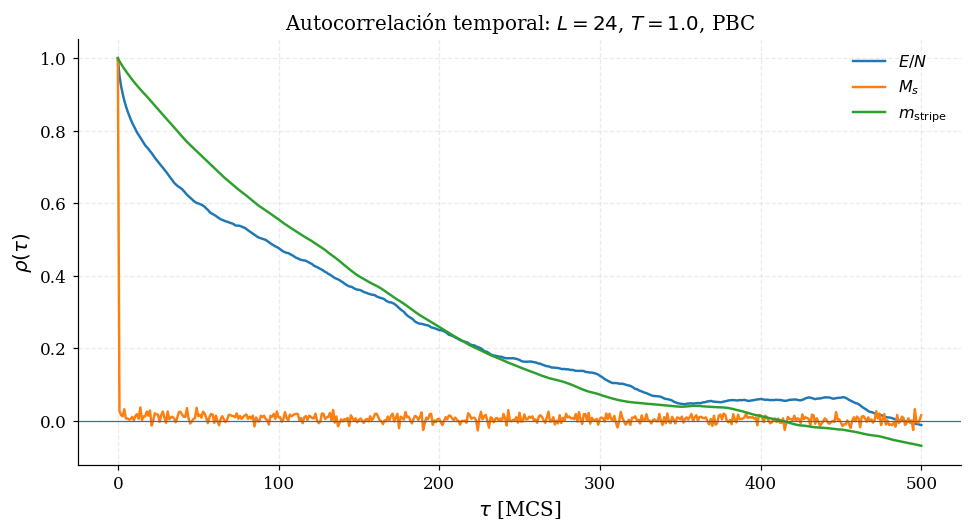

In [37]:
lags_E, rho_E = autocorrelation(
    energy_ts,
    max_lag=500
)

lags_Ms, rho_Ms = autocorrelation(
    Ms_ts,
    max_lag=500
)

lags_stripe, rho_stripe = autocorrelation(
    mstripe_ts,
    max_lag=500
)


plt.figure(figsize=(9, 5))

plt.plot(
    lags_E,
    rho_E,
    label=r'$E/N$'
)

plt.plot(
    lags_Ms,
    rho_Ms,
    label=r'$M_s$'
)

plt.plot(
    lags_stripe,
    rho_stripe,
    label=r'$m_{\rm stripe}$'
)

plt.axhline(
    0.0,
    linewidth=0.8
)

plt.xlabel(r'$\tau$ [MCS]')
plt.ylabel(r'$\rho(\tau)$')
plt.title(
    r'Autocorrelación temporal: $L=24$, $T=1.0$, PBC'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 19. Parámetros de producción, Parte A

De aquí en adelante corremos la simulación científica de la Parte A, para los cuatro sistemas $(L,\text{frontera}) = (16,\text{PBC}), (16,\text{FBC}), (24,\text{PBC}), (24,\text{FBC})$, todos con $J_1=1$, $J_2=-0.6$, $h=0$, y el barrido descendente $3.0\to2.9\to\cdots\to0.1$.

Usamos $N_{\text{term}}=5000$ MCS de termalización y $N_{\text{muestra}}=10000$ MCS de muestreo, los mismos valores que usamos en los diagnósticos de termalización y autocorrelación de las secciones anteriores. Como esos diagnósticos no mostraron deriva apreciable en los promedios acumulados ni tiempos de autocorrelación comparables a $N_{\text{muestra}}$, los adoptamos directamente para producción en vez de inventar valores nuevos sin justificación.

En cada punto de temperatura el procedimiento es: termalizar, muestrear, guardar la configuración final, pasar a la siguiente temperatura usándola como estado inicial.

In [38]:
# ============================================================
# CONFIGURACIÓN DE PRODUCCIÓN - PARTE A
# ============================================================

NTERM_PROD = 5000
NMUESTRA_PROD = 10000

L_VALUES_PROD = (16, 24)

BOUNDARY_CONDITIONS = {
    "PBC": True,
    "FBC": False
}

TEMPERATURES_PROD = TEMPERATURES.copy()

print("Parámetros de producción:")
print(f"  Nterm     = {NTERM_PROD}")
print(f"  Nmuestra  = {NMUESTRA_PROD}")
print(f"  L         = {L_VALUES_PROD}")
print(
    "  Fronteras =",
    list(BOUNDARY_CONDITIONS.keys())
)
print(
    f"  T: {TEMPERATURES_PROD[0]:.1f}"
    f" -> {TEMPERATURES_PROD[-1]:.1f}"
)

Parámetros de producción:
  Nterm     = 5000
  Nmuestra  = 10000
  L         = (16, 24)
  Fronteras = ['PBC', 'FBC']
  T: 3.0 -> 0.1


## 20. Función de control para las corridas de producción

Definimos una función que ejecuta una simulación completa para una combinación dada de $L$ y condición de frontera. No cambia nada de la física ni del algoritmo; solo organiza la ejecución y guarda la información que vamos a necesitar después: los observables termodinámicos pedidos, el parámetro de orden *stripe* complementario, la tasa de aceptación, los parámetros usados y el tiempo de ejecución.

In [39]:
def run_production_case(
    L,
    boundary_name,
    nterm=NTERM_PROD,
    nmuestra=NMUESTRA_PROD,
    seed=None
):
    """
    Ejecuta una corrida completa de la Parte A.

    Parameters
    ----------
    L : int
        Tamaño lineal de la red.

    boundary_name : str
        'PBC' o 'FBC'.

    nterm : int
        MCS de termalización por temperatura.

    nmuestra : int
        MCS de muestreo por temperatura.

    seed : int or None
        Semilla para la configuración inicial aleatoria.
    """

    if boundary_name not in BOUNDARY_CONDITIONS:
        raise ValueError(
            "boundary_name debe ser 'PBC' o 'FBC'."
        )

    periodic = BOUNDARY_CONDITIONS[
        boundary_name
    ]

    print("=" * 70)
    print(
        f"INICIO DE CORRIDA: "
        f"L={L}, frontera={boundary_name}"
    )
    print("=" * 70)

    t0 = time.perf_counter()

    results = run_temperature_sweep(
        L=L,
        periodic=periodic,
        temperatures=TEMPERATURES_PROD,
        nterm=nterm,
        nmuestra=nmuestra,
        seed=seed,
        J1=J1,
        J2=J2,
        h=0.0
    )

    elapsed = time.perf_counter() - t0

    results["boundary_name"] = boundary_name
    results["runtime_seconds"] = elapsed

    print()
    print(
        f"✓ Corrida terminada en "
        f"{elapsed:.2f} s"
    )

    return results

In [40]:
# ============================================================
# PRIMER CASO DE PRODUCCIÓN
# L = 16, PBC
# ============================================================

results_16_PBC = run_production_case(
    L=16,
    boundary_name="PBC",
    nterm=NTERM_PROD,
    nmuestra=NMUESTRA_PROD,
    seed=SEED
)

INICIO DE CORRIDA: L=16, frontera=PBC
L=16 | PBC | T=3.0
L=16 | PBC | T=2.9
L=16 | PBC | T=2.8
L=16 | PBC | T=2.7
L=16 | PBC | T=2.6
L=16 | PBC | T=2.5
L=16 | PBC | T=2.4
L=16 | PBC | T=2.3
L=16 | PBC | T=2.2
L=16 | PBC | T=2.1
L=16 | PBC | T=2.0
L=16 | PBC | T=1.9
L=16 | PBC | T=1.8
L=16 | PBC | T=1.7
L=16 | PBC | T=1.6
L=16 | PBC | T=1.5
L=16 | PBC | T=1.4
L=16 | PBC | T=1.3
L=16 | PBC | T=1.2
L=16 | PBC | T=1.1
L=16 | PBC | T=1.0
L=16 | PBC | T=0.9
L=16 | PBC | T=0.8
L=16 | PBC | T=0.7
L=16 | PBC | T=0.6
L=16 | PBC | T=0.5
L=16 | PBC | T=0.4
L=16 | PBC | T=0.3
L=16 | PBC | T=0.2
L=16 | PBC | T=0.1

✓ Corrida terminada en 7.94 s


## 21. Revisión de la primera corrida

Para la primera corrida ($L=16$, PBC) revisamos $\langle E\rangle/N$, $\langle M_s\rangle$, $C_v$, $\chi_s$, $U$ y la tasa de aceptación. Esto sirve para detectar de inmediato problemas típicos: valores no finitos a alguna temperatura, un Binder inestable, tasas de aceptación anormalmente altas o bajas, energía incompatible con el límite de baja temperatura, o $C_v$ negativo (que solo debería ocurrir por errores numéricos de redondeo, nunca de forma sistemática).

In [41]:
def print_result_summary(results):
    """
    Imprime una tabla compacta de los resultados, mostrando cada
    observable como valor ± error estándar (SEM, método de bloques).
    """

    L = results["L"]
    boundary = results["boundary_name"]

    order = np.argsort(results["T"])

    N = L * L

    print()
    print(f"Resumen: L={L}, frontera={boundary} (valores ± SEM, {results.get('Nbloques', NBLOCKS)} bloques)")
    print()

    header = (
        f"{'T':>6}"
        f"{'<E>/N':>18}"
        f"{'<Ms>':>18}"
        f"{'Cv':>18}"
        f"{'chi_s':>18}"
        f"{'Binder':>18}"
        f"{'mstripe':>18}"
        f"{'acc.':>10}"
    )
    print(header)
    print("-" * len(header))

    for i in order:

        E_str = f"{results['E'][i]/N:.5f}±{results['E_err'][i]/N:.5f}"
        Ms_str = f"{results['Ms'][i]:.5f}±{results['Ms_err'][i]:.5f}"
        Cv_str = f"{results['Cv'][i]:.4f}±{results['Cv_err'][i]:.4f}"
        chi_str = f"{results['chi_s'][i]:.4f}±{results['chi_s_err'][i]:.4f}"
        U_str = f"{results['binder'][i]:.4f}±{results['binder_err'][i]:.4f}"
        ms_str = f"{results['mstripe'][i]:.5f}±{results['mstripe_err'][i]:.5f}"

        print(
            f"{results['T'][i]:6.2f}"
            f"{E_str:>18}"
            f"{Ms_str:>18}"
            f"{Cv_str:>18}"
            f"{chi_str:>18}"
            f"{U_str:>18}"
            f"{ms_str:>18}"
            f"{results['acceptance'][i]:10.4f}"
        )

    print()
    print(f"Tiempo total: {results['runtime_seconds']:.2f} s")


In [42]:
print_result_summary(
    results_16_PBC
)


Resumen: L=16, frontera=PBC (valores ± SEM, 20 bloques)

     T             <E>/N              <Ms>                Cv             chi_s            Binder           mstripe      acc.
----------------------------------------------------------------------------------------------------------------------------
  0.10  -1.20000±0.00000   0.00000±0.00000     0.0000±0.0000     0.0000±0.0000     1.0000±0.0000   1.00000±0.00000    0.0000
  0.20  -1.20000±0.00000   0.00000±0.00000     0.0000±0.0000     0.0000±0.0000     1.0000±0.0000   1.00000±0.00000    0.0000
  0.30  -1.20000±0.00000   0.00000±0.00000     0.0000±0.0000     0.0000±0.0000     1.0000±0.0000   1.00000±0.00000    0.0000
  0.40  -1.19997±0.00001   0.00001±0.00000     0.0010±0.0003     0.0000±0.0000  -38.0515±10.4648   0.99999±0.00000    0.0000
  0.50  -1.19957±0.00006   0.00007±0.00001     0.0087±0.0013     0.0001±0.0000   -25.1936±3.7284   0.99978±0.00004    0.0002
  0.60  -1.19756±0.00017   0.00034±0.00002     0.0368±0.0026     0.

In [43]:
def validate_results(results):
    """
    Realiza comprobaciones automáticas básicas de los resultados.
    """

    T = results["T"]
    E = results["E"]
    Cv = results["Cv"]
    chi_s = results["chi_s"]
    binder = results["binder"]
    acceptance = results["acceptance"]

    warnings = []

    # --------------------------------------------------------
    # Valores finitos
    # --------------------------------------------------------

    for name, array in {
        "E": E,
        "Cv": Cv,
        "chi_s": chi_s,
        "acceptance": acceptance
    }.items():

        if not np.all(np.isfinite(array)):

            warnings.append(
                f"{name} contiene valores no finitos."
            )

    # --------------------------------------------------------
    # Calor específico
    # --------------------------------------------------------

    if np.any(Cv < -1e-12):

        warnings.append(
            "Se encontraron valores negativos "
            "de Cv incompatibles con "
            "la definición por fluctuaciones."
        )

    # --------------------------------------------------------
    # Tasa de aceptación
    # --------------------------------------------------------

    if np.any(acceptance < 0.0) or np.any(
        acceptance > 1.0
    ):

        warnings.append(
            "La tasa de aceptación está fuera "
            "del intervalo [0,1]."
        )

    # --------------------------------------------------------
    # Orden de temperaturas
    # --------------------------------------------------------

    if not np.all(
        np.diff(T) < 0
    ):

        warnings.append(
            "Las temperaturas no están en "
            "orden descendente."
        )

    # --------------------------------------------------------
    # Binder
    # --------------------------------------------------------

    if np.any(~np.isfinite(binder)):

        warnings.append(
            "Binder contiene valores no finitos. "
            "Esto puede ocurrir cuando <Ms²> "
            "es extremadamente pequeño."
        )

    # --------------------------------------------------------
    # Reporte
    # --------------------------------------------------------

    if len(warnings) == 0:

        print("✓ No se detectaron problemas básicos.")

    else:

        print("ADVERTENCIAS:")

        for warning in warnings:
            print(" -", warning)

In [44]:
validate_results(
    results_16_PBC
)

✓ No se detectaron problemas básicos.


In [45]:
def plot_production_case(results):
    """
    Genera las gráficas principales de una corrida, con barras de
    error (SEM, método de bloques, Sección 8.1) en todos los
    observables que son promedios térmicos.
    """

    sorted_results = sort_results_by_temperature(results)

    T = sorted_results["T"]
    L = sorted_results["L"]
    boundary = sorted_results["boundary_name"]
    N = L * L

    panels = [
        ("E", None, r'$T$', r'$\langle E\rangle/N$', 'Energía por espín', lambda y: y / N),
        ("Ms", None, r'$T$', r'$\langle M_s\rangle$', 'Magnetización de subred', None),
        ("Cv", None, r'$T$', r'$C_v$', 'Calor específico', None),
        ("chi_s", None, r'$T$', r'$\chi_s$', 'Susceptibilidad de subred', None),
        ("binder", None, r'$T$', r'$U$', 'Cumulante de Binder', None),
        ("mstripe", None, r'$T$', r'$\langle m_{\mathrm{stripe}}\rangle$', 'Orden stripe', None),
    ]

    for key, _, xlabel, ylabel, name, transform in panels:

        y = sorted_results[key]
        yerr = sorted_results.get(f"{key}_err")

        if transform is not None:
            y = transform(y)
            if yerr is not None:
                yerr = transform(yerr)

        plt.figure(figsize=(7, 4.3))

        plt.errorbar(
            T, y, yerr=yerr,
            marker='o', ms=4, lw=1.4, capsize=3,
            color=COLOR_PBC if boundary == "PBC" else COLOR_FBC,
            ecolor='0.35', elinewidth=0.9,
        )

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(rf'{name}: $L={L}$, {boundary}')
        plt.tight_layout()
        savefig(f"{key}_L{L}_{boundary}")
        plt.show()

    # ========================================================
    # Aceptación (sin barra de error: es una fracción, no un
    # promedio con fluctuaciones estadísticas relevantes aquí)
    # ========================================================

    plt.figure(figsize=(7, 4.3))

    plt.plot(
        T, sorted_results["acceptance"],
        marker='o', ms=4, lw=1.4,
        color=COLOR_PBC if boundary == "PBC" else COLOR_FBC,
    )

    plt.xlabel(r'$T$')
    plt.ylabel('Tasa de aceptación')
    plt.title(rf'Aceptación de Metrópolis: $L={L}$, {boundary}')
    plt.tight_layout()
    savefig(f"acceptance_L{L}_{boundary}")
    plt.show()


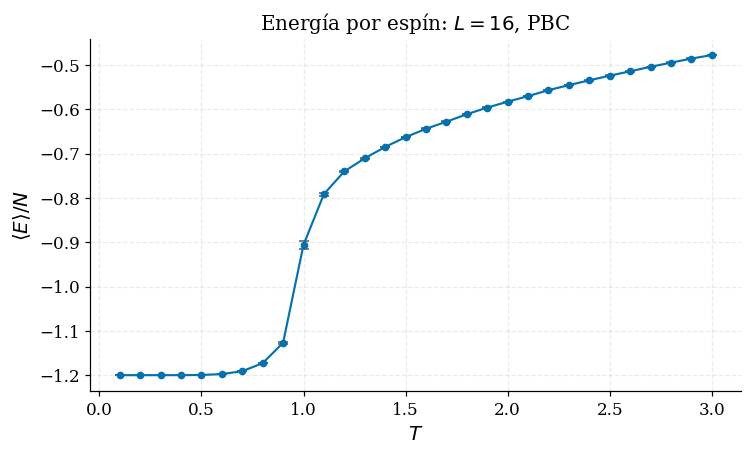

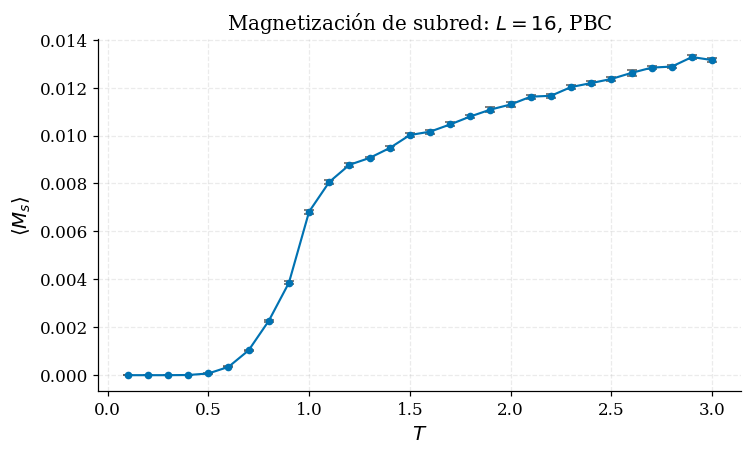

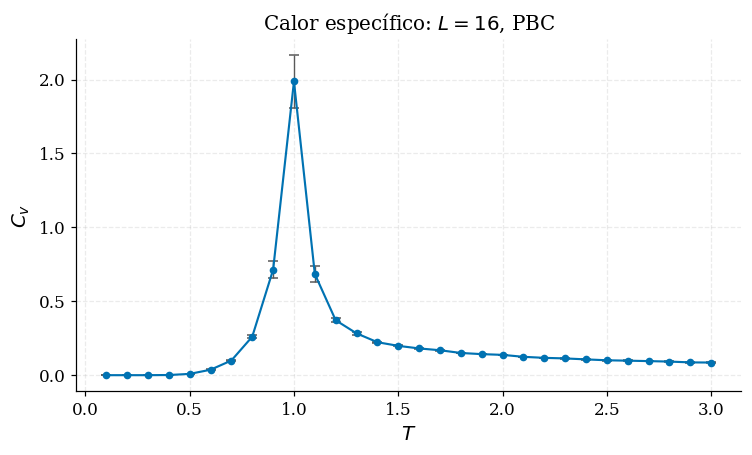

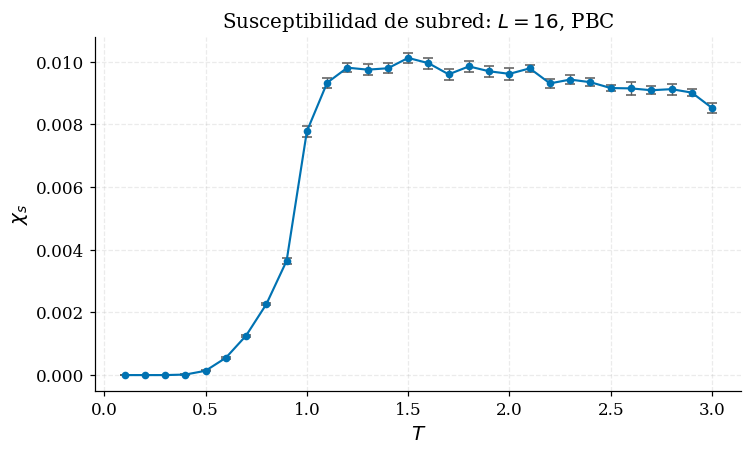

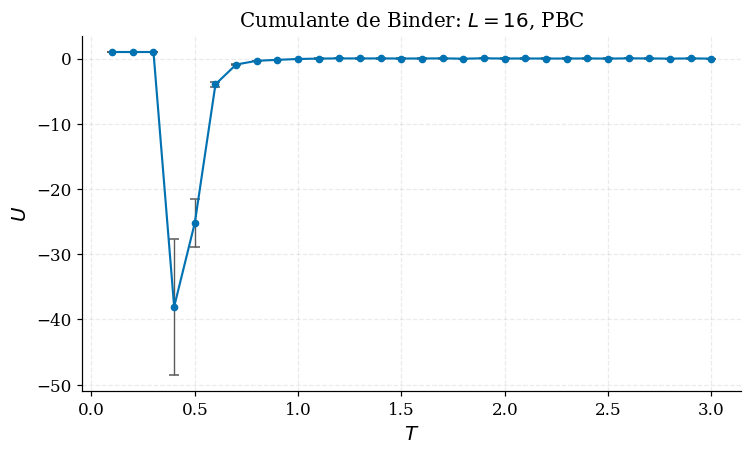

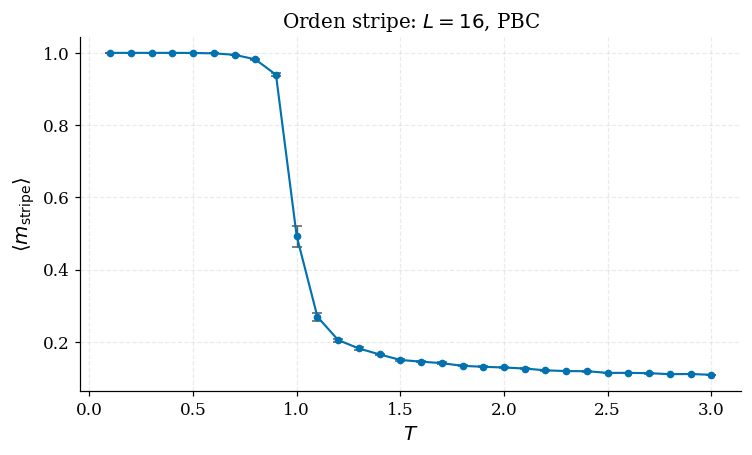

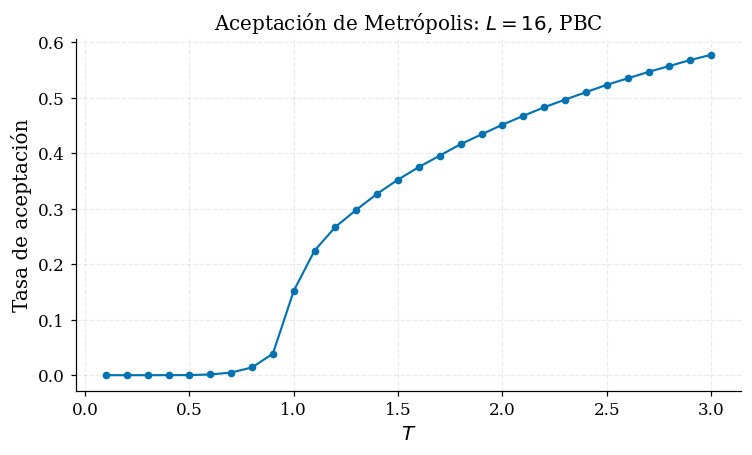

In [46]:
plot_production_case(
    results_16_PBC
)

## 22. Control del límite de baja temperatura

Para $J_1=1$, $J_2=-0.6$, el estado *stripe* ideal tiene $E_0/N=-1.2$. No esperamos que una simulación finita a $T=0.1$ reproduzca ese valor exactamente, pero sí que se acerque bastante si la fase ordenada se alcanzó correctamente. Es un control físico sencillo y rápido de aplicar.

In [47]:
def low_temperature_check(results):

    L = results["L"]
    N = L * L

    order = np.argsort(
        results["T"]
    )

    i_low = order[0]

    T_low = results["T"][i_low]

    e_low = results["E"][i_low] / N
    mstripe_low = results["mstripe"][i_low]

    print(
        f"T mínima = {T_low:.2f}"
    )

    print(
        f"E/N en T mínima = {e_low:.8f}"
    )

    print(
        f"E/N - (-1.2) = "
        f"{e_low + 1.2:.3e}"
    )

    print(
        f"m_stripe en T mínima = "
        f"{mstripe_low:.8f}"
    )

In [48]:
low_temperature_check(
    results_16_PBC
)

T mínima = 0.10
E/N en T mínima = -1.20000000
E/N - (-1.2) = 4.441e-16
m_stripe en T mínima = 1.00000000


## 23. Producción completa de la Parte A

Con la primera corrida validada, ejecutamos las cuatro combinaciones $(16,\text{PBC})$, $(16,\text{FBC})$, $(24,\text{PBC})$, $(24,\text{FBC})$ y guardamos todo junto para poder comparar tamaño finito y condiciones de frontera directamente. Cada corrida conserva su propio barrido descendente con memoria, así que el muestreo es consistente entre casos.

El caso $(16,\text{PBC})$ ya se ejecutó en la sección anterior, y $(24,\text{PBC})$ ya se ejecutó más arriba con exactamente los mismos parámetros de producción; ambos se reutilizan en vez de repetir la simulación.

### Implementación de Paralelismo a Nivel de Procesos

Para optimizar el tiempo de ejecución, utilizaremos `ProcessPoolExecutor` de la librería `concurrent.futures`. Esto permite lanzar cada caso de producción en un proceso de Python independiente, aprovechando el hardware multinúcleo.

In [49]:
def run_single_case(args):
    """Función auxiliar para desempaquetar argumentos en el pool."""
    L, boundary, nterm, nmuestra, seed = args
    return run_production_case(L, boundary, nterm, nmuestra, seed)

def run_production_parallel(production_cases, nterm, nmuestra, seed):
    """
    Ejecuta los casos de producción en paralelo.
    """
    results_dict = {}

    # Preparamos los argumentos para cada proceso
    tasks = [
        (L, boundary, nterm, nmuestra, seed)
        for L, boundary in production_cases
    ]

    print(f"Iniciando ejecución paralela de {len(tasks)} casos...")

    with concurrent.futures.ProcessPoolExecutor() as executor:
        # Mapeamos la función a las tareas
        futures = {executor.submit(run_single_case, task): task for task in tasks}

        for future in concurrent.futures.as_completed(futures):
            task = futures[future]
            try:
                res = future.result()
                key = f"L{res['L']}_{res['boundary_name']}"
                results_dict[key] = res
                print(f"-> Resultado para {key} recibido.")
            except Exception as exc:
                print(f"El caso {task} generó una excepción: {exc}")

    return results_dict

In [50]:
# ============================================================
# EJECUCIÓN PARALELA DE PRODUCCIÓN
# ============================================================
# (16, PBC) y (24, PBC) ya se ejecutaron con estos mismos parámetros de
# producción en las Secciones 14 y 20, así que reutilizamos esos
# resultados en vez de volver a simularlos. Solo lanzamos en paralelo
# los dos casos que todavía faltan: (16, FBC) y (24, FBC).

t_start_parallel = time.perf_counter()

# Casos pendientes de simular
production_cases = [
    (16, "FBC"),
    (24, "FBC"),
]

# Ejecutamos en paralelo únicamente los casos faltantes
results_all_parallel = run_production_parallel(
    production_cases,
    nterm=NTERM_PROD,
    nmuestra=NMUESTRA_PROD,
    seed=SEED
)

t_total_parallel = time.perf_counter() - t_start_parallel
print(f"\n✓ PRODUCCIÓN PARALELA TERMINADA en {t_total_parallel:.2f} s")

# Combinamos los casos recién calculados con los que ya teníamos
# (Sección 14: L=24 PBC; Sección 20: L=16 PBC), sin volver a simularlos.
results_all = {
    "L16_PBC": results_16_PBC,
    "L24_PBC": results_L24_PBC,
    **results_all_parallel,
}


Iniciando ejecución paralela de 2 casos...
INICIO DE CORRIDA: L=16, frontera=FBC
L=16 | FBC | T=3.0
INICIO DE CORRIDA: L=24, frontera=FBC
L=24 | FBC | T=3.0
L=16 | FBC | T=2.9
L=16 | FBC | T=2.8
L=24 | FBC | T=2.9
L=16 | FBC | T=2.7
L=16 | FBC | T=2.6
L=16 | FBC | T=2.5
L=24 | FBC | T=2.8
L=16 | FBC | T=2.4
L=16 | FBC | T=2.3
L=24 | FBC | T=2.7
L=16 | FBC | T=2.2
L=16 | FBC | T=2.1
L=16 | FBC | T=2.0
L=24 | FBC | T=2.6
L=16 | FBC | T=1.9
L=16 | FBC | T=1.8
L=16 | FBC | T=1.7
L=24 | FBC | T=2.5
L=16 | FBC | T=1.6
L=16 | FBC | T=1.5
L=16 | FBC | T=1.4
L=24 | FBC | T=2.4
L=16 | FBC | T=1.3
L=16 | FBC | T=1.2
L=24 | FBC | T=2.3
L=16 | FBC | T=1.1
L=16 | FBC | T=1.0
L=16 | FBC | T=0.9
L=24 | FBC | T=2.2
L=16 | FBC | T=0.8
L=16 | FBC | T=0.7
L=16 | FBC | T=0.6
L=24 | FBC | T=2.1
L=16 | FBC | T=0.5
L=16 | FBC | T=0.4
L=16 | FBC | T=0.3
L=24 | FBC | T=2.0
L=16 | FBC | T=0.2
L=16 | FBC | T=0.1

✓ Corrida terminada en 13.56 s
L=24 | FBC | T=1.9
-> Resultado para L16_FBC recibido.
L=24 | FBC | T=

## 24. Cierre de la Parte A

Con las cuatro combinaciones $(L,\text{frontera})\in\{16,24\}\times\{\text{PBC},\text{FBC}\}$ guardadas en `results_all`, ya tenemos todo lo necesario para el análisis de la Parte 3.2.1 del enunciado: graficar $M_s(T)$ y $\chi_s(T)$, comparar condiciones de frontera y localizar $T_N$ con el cumulante de Binder.

Lo que sigue en el notebook cubre la Parte B: primero la transición de fase (Preguntas 1 y 2), después el efecto magnetocalórico con campo externo $h=0$ y $h=0.5$ para $L=24$, PBC (Preguntas 3 y 4), y por último el análisis de tamaño finito y clases de universalidad (Preguntas 5 y 6). Toda la infraestructura ya construida —tablas de vecinos, `simulate_temperature`, `run_temperature_sweep`, `seed_numba_rng`— se reutiliza directamente, ya que el campo $h$ está implementado en el Hamiltoniano desde la Sección 3 aunque hasta aquí siempre se haya usado $h=0$.

La clase de universalidad de un sistema queda determinada por su dimensionalidad espacial, la dimensionalidad y simetría del parámetro de orden, y el alcance de las interacciones, no por los detalles microscópicos del Hamiltoniano (Stanley, 1999). El cumulante de Binder empleado en la Sección 27 para localizar $T_N$ es, precisamente, la herramienta estándar para identificar puntos críticos a partir de datos de tamaño finito (Binder, 1981).


## 25. Transición de fase y condiciones de frontera

Con las cuatro corridas de producción de la Parte A en `results_all`, analizamos cómo dependen de la temperatura las cantidades pedidas en el enunciado, comparando $L=16$ y $L=24$ para PBC y FBC.

Presentamos primero los observables pedidos directamente por la tarea, $M_s(T)$, $\chi_s(T)$ y $U(T)$. Como la comparación de energías de la Sección 12 mostró que el estado fundamental para $J_1=1$, $J_2=-0.6$ es tipo *stripe* y no checkerboard, incluimos también, como diagnóstico complementario, $m_{\mathrm{stripe}}(T)$, $\chi_{\mathrm{stripe}}(T)$ y $U_{\mathrm{stripe}}(T)$. Esto nos permite distinguir entre lo que dice literalmente el observable del enunciado y lo que hace el parámetro de orden correcto para la fase que realmente aparece en la simulación. No modificamos ninguna de las definiciones originales; solo comparamos ambas descripciones lado a lado.

### Curvas literales pedidas por el enunciado: $M_s(T)$, $\chi_s(T)$ y $U(T)$

Antes de pasar al diagnóstico complementario en términos del orden *stripe*, mostramos los observables tal como los define el enunciado: la magnetización de subred $M_s(T)$, la susceptibilidad de subred $\chi_s(T)$, y el cumulante de Binder $U(T)$. Los tres se muestran en el mismo formato de grilla: un panel por condición de frontera (PBC y FBC), superponiendo $L=16$ y $L=24$ en cada uno — que es justamente lo que necesitamos para localizar $T_N$ por el cruce de las curvas de Binder, como pide la Pregunta 2.

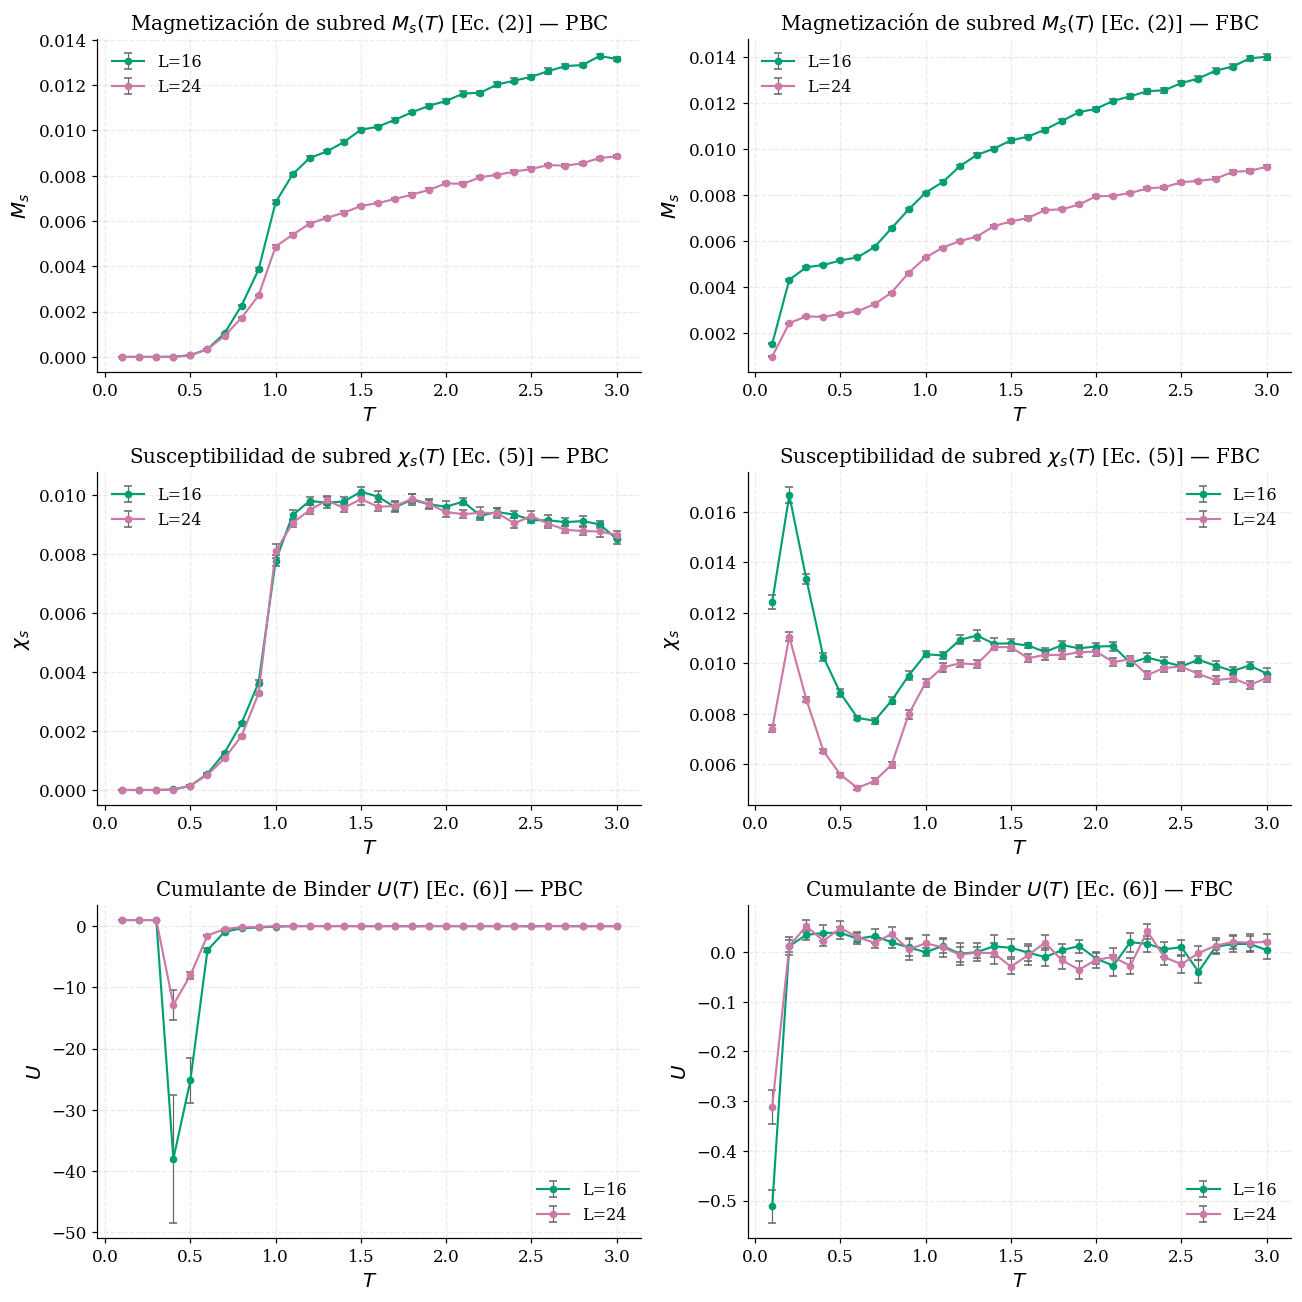

In [51]:
def plot_boundary_comparison(
    results_all,
    quantities,
    boundary_conditions=("PBC", "FBC"),
    L_values=(16, 24),
    figsize_per_panel=(6, 4),
):
    """
    Grilla de comparación: una fila por cantidad física, una columna
    por condición de frontera; en cada panel se superponen los
    tamaños de red dados, con barras de error (SEM, método de
    bloques, Sección 8.1).

    Parameters
    ----------
    results_all : dict
        Diccionario {f"L{L}_{boundary}": resultados}, como el que
        arma la Sección 23 (producción completa de la Parte A).
    quantities : list of tuple
        (key, ylabel, titulo[, transform]). 'key' es el campo a leer
        de cada resultado (su error se busca en '<key>_err' y recibe
        el mismo 'transform'); 'transform(y, L)' es una función
        opcional aplicada al arreglo antes de graficar.
    """

    n_rows = len(quantities)
    n_cols = len(boundary_conditions)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )

    L_colors = {16: COLOR_L16, 24: COLOR_L24}

    for row, spec in enumerate(quantities):
        key, ylabel, title = spec[0], spec[1], spec[2]
        transform = spec[3] if len(spec) > 3 else (lambda y, L: y)

        for col, boundary in enumerate(boundary_conditions):
            ax = axes[row, col]

            for L in L_values:
                case_key = f"L{L}_{boundary}"
                r = results_all.get(case_key)

                if r is None:
                    continue

                sorted_r = sort_results_by_temperature(r)
                y = transform(sorted_r[key], L)
                err_raw = sorted_r.get(f"{key}_err")
                yerr = transform(err_raw, L) if err_raw is not None else None

                ax.errorbar(
                    sorted_r["T"], y, yerr=yerr,
                    marker='o', ms=4, lw=1.4, capsize=2.5,
                    elinewidth=0.8, ecolor='0.4',
                    color=L_colors.get(L, None),
                    label=f"L={L}"
                )

            ax.set_title(rf"{title} — {boundary}")
            ax.set_xlabel(r"$T$")
            ax.set_ylabel(ylabel)
            ax.legend()

    plt.tight_layout()
    return fig, axes


# --- Ms(T), chi_s(T), U(T): un panel por frontera, L=16 vs L=24 ---
quantities_literal = [
    ("Ms", r"$M_s$", r"Magnetización de subred $M_s(T)$ [Ec. (2)]"),
    ("chi_s", r"$\chi_s$", r"Susceptibilidad de subred $\chi_s(T)$ [Ec. (5)]"),
    ("binder", r"$U$", r"Cumulante de Binder $U(T)$ [Ec. (6)]"),
]

fig, axes = plot_boundary_comparison(results_all, quantities_literal)
savefig(fig, "Ms_chis_binder_grid")
plt.show()


### Observables adicionales de la Parte A: $E(T)$ y $C_v(T)$

El enunciado (Parte A, punto 4) también pide calcular la energía y el calor específico para cada combinación $(L,\text{frontera})$; hasta ahora solo los habíamos revisado de a uno con `plot_production_case`. Los mostramos aquí en el mismo formato de grilla, para completar la comparación de tamaño finito de todos los observables de producción, no solo de los que se piden graficar explícitamente en la Parte B.

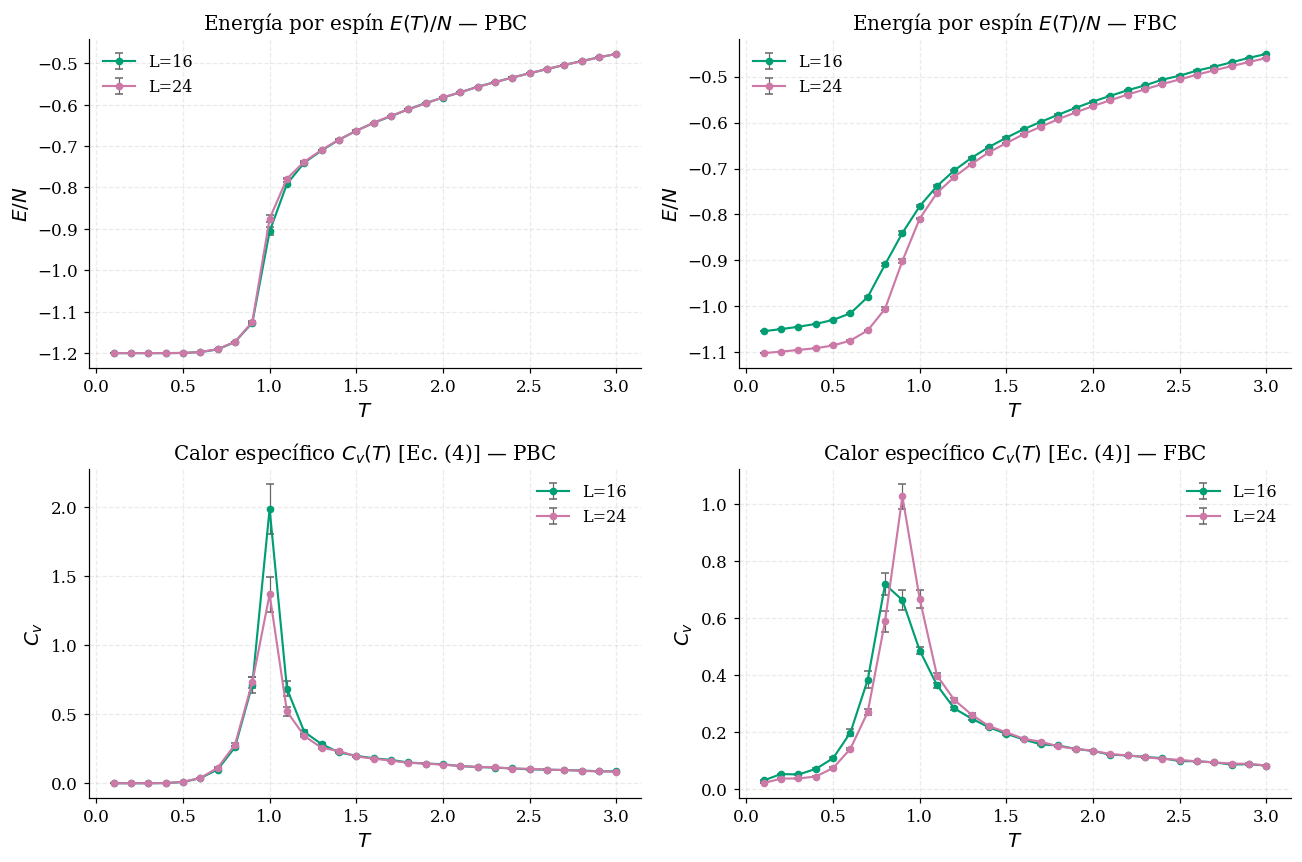

In [52]:
quantities_extra = [
    ("E", r"$E/N$", r"Energía por espín $E(T)/N$", lambda y, L: y / (L * L)),
    ("Cv", r"$C_v$", r"Calor específico $C_v(T)$ [Ec. (4)]"),
]

fig, axes = plot_boundary_comparison(results_all, quantities_extra)
savefig(fig, "E_Cv_grid")
plt.show()


Como ya sabemos que el estado fundamental para $J_1=1$, $J_2=-0.6$ es tipo *stripe* y no checkerboard, repetimos el mismo formato de grilla (PBC/FBC × $L=16,24$) para la familia stripe completa: $m_{\mathrm{stripe}}(T)$, $\chi_{\mathrm{stripe}}(T)$ y $U_{\mathrm{stripe}}(T)$. Comparamos estas curvas con las de $M_s(T)$, $\chi_s(T)$ y $U(T)$ de arriba: si el orden stripe muestra una transición nítida donde el observable literal del enunciado se queda plano, eso confirma que $M_s$ tal como lo define el enunciado no es sensible al tipo de orden que efectivamente aparece en esta simulación.

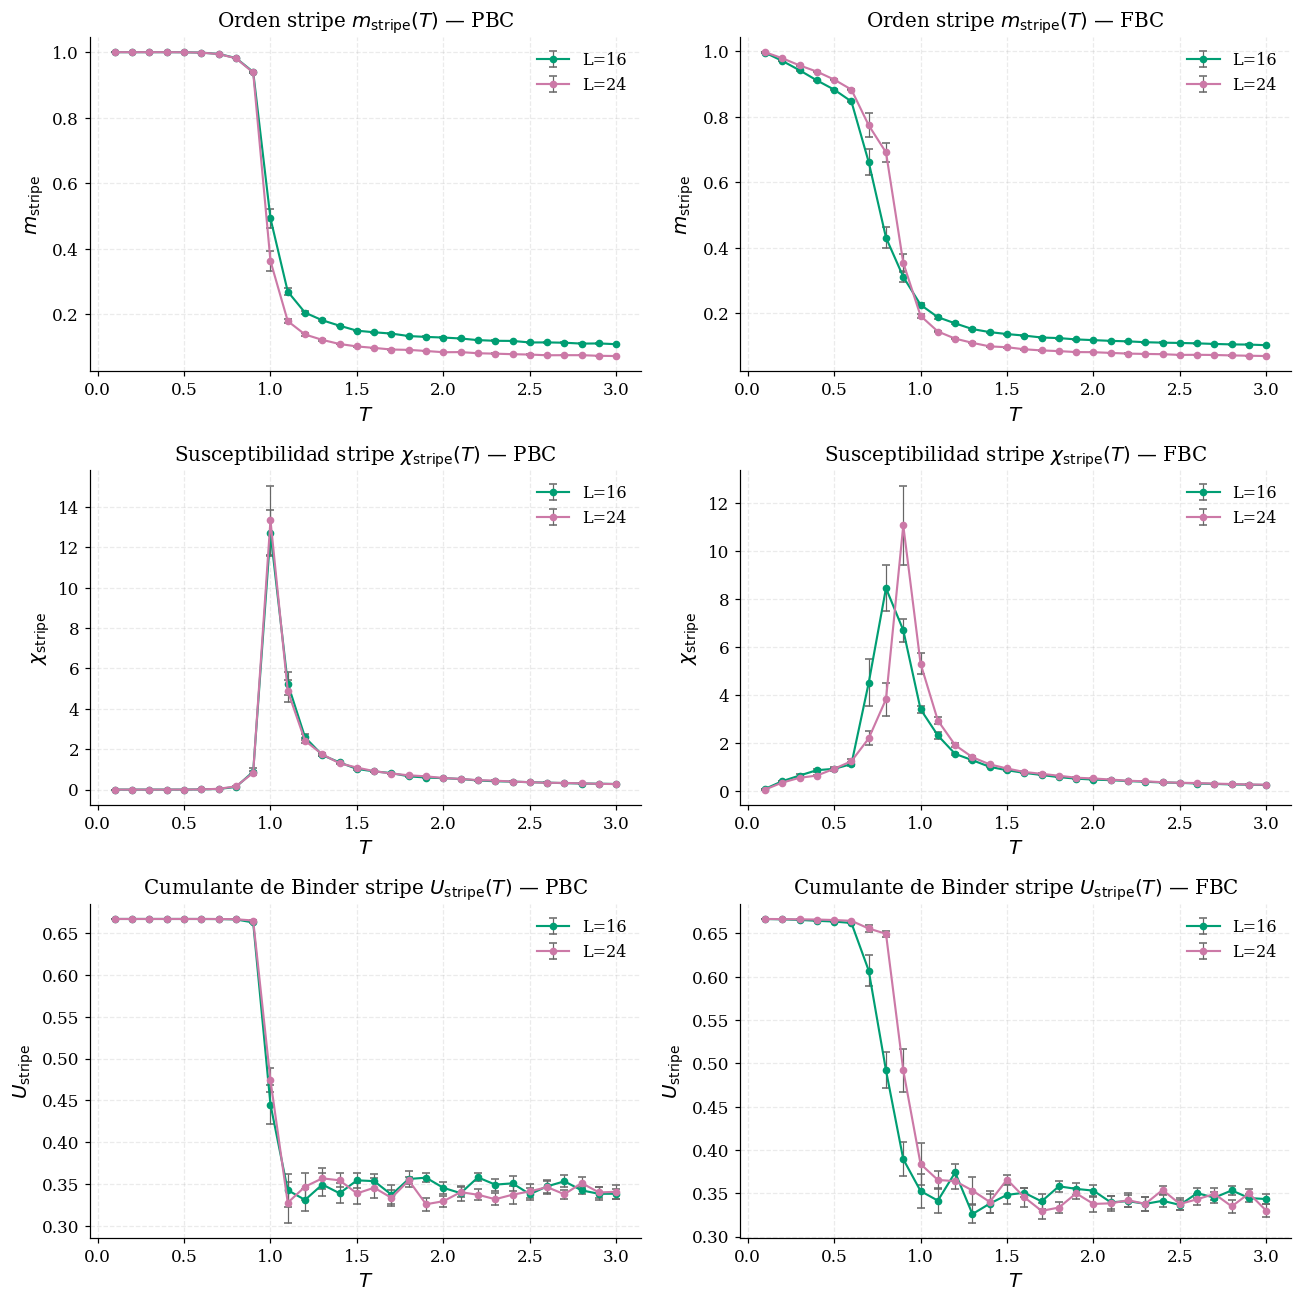

In [53]:
quantities_stripe = [
    ("mstripe", r"$m_{\mathrm{stripe}}$", r"Orden stripe $m_{\mathrm{stripe}}(T)$"),
    ("chi_stripe", r"$\chi_{\mathrm{stripe}}$", r"Susceptibilidad stripe $\chi_{\mathrm{stripe}}(T)$"),
    ("binder_stripe", r"$U_{\mathrm{stripe}}$", r"Cumulante de Binder stripe $U_{\mathrm{stripe}}(T)$"),
]

fig, axes = plot_boundary_comparison(results_all, quantities_stripe)
savefig(fig, "mstripe_chistripe_binderstripe_grid")
plt.show()


## 26. Pregunta 1 — efecto de las condiciones de frontera

Las condiciones de frontera generan diferencias apreciables en un sistema finito, sobre todo cerca de la transición.

Con fronteras periódicas los resultados de $L=16$ y $L=24$ son muy parecidos: el parámetro de orden *stripe* cae fuerte alrededor de $T\approx1$, y $\chi_{\mathrm{stripe}}$ tiene su máximo también en $T\approx1$ para ambos tamaños.

Con fronteras libres los efectos de superficie pesan más: el orden *stripe* empieza a caer a temperaturas menores, y el máximo de $\chi_{\mathrm{stripe}}$ aparece en $T\approx0.8$ para $L=16$ y se desplaza a $T\approx0.9$ para $L=24$. Esto confirma que las fronteras libres alteran de forma apreciable las propiedades magnéticas de un sistema de este tamaño, y que además el efecto de tamaño finito es más marcado con FBC que con PBC.

Las condiciones periódicas se acercan más al límite termodinámico porque eliminan los efectos de superficie y todos los espines quedan en un entorno equivalente; las fronteras libres, en cambio, introducen una superficie efectiva cuyo peso relativo es mayor cuanto más pequeña es la red.

Vale la pena insistir en que $M_s(T)$, tal como está definido en el enunciado, no es el observable que realmente sigue el orden físico de esta fase: el Hamiltoniano con $J_1=1$, $J_2=-0.6$ favorece el orden *stripe*, así que es $m_{\mathrm{stripe}}$ el que muestra con claridad la desaparición del orden magnético.

## 27. Pregunta 2 — determinación de $T_N$

Con fronteras periódicas, el máximo de $\chi_{\mathrm{stripe}}$ da $T_N^{\mathrm{PBC}}\approx1.0$ para ambos tamaños: la posición del máximo es estable frente a $L$. Con fronteras libres el máximo aparece en $T\approx0.8$ para $L=16$ y en $T\approx0.9$ para $L=24$ — un desplazamiento de un paso de la malla térmica, señal de que aquí el efecto de tamaño finito todavía pesa.

El cumulante de Binder (Binder, 1981) sirve como chequeo independiente — el cruce de sus curvas para distintos tamaños de red es el método estándar para localizar puntos críticos a partir de datos de tamaño finito: para PBC, las curvas de $L=16$ y $L=24$ se cruzan cerca de $T\sim0.9$–$1.1$; para FBC los cruces están más dispersos, coherente con la mayor influencia de los efectos de superficie.

Con la resolución térmica y los tamaños usados aquí, el máximo de $\chi_{\mathrm{stripe}}$ resulta una estimación más estable de la temperatura de transición que el cruce del Binder, que usamos más bien como diagnóstico complementario. Adoptamos entonces $T_N^{\mathrm{PBC}}\approx1.0$ y $T_N^{\mathrm{FBC}}\approx0.9$ (el valor de $L=24$, la red más grande disponible) como valores de trabajo, entendiendo que son temperaturas características del sistema finito y no una determinación precisa del límite termodinámico.

## 28. Preparación del cálculo del efecto magnetocalórico

Para el EMC usamos el sistema indicado en el enunciado: $L=24$, frontera periódica. A diferencia de la Parte A, donde el parámetro de orden principal era $M_s$, aquí necesitamos la magnetización **total**, $M=\sum_i S_i$, y el Hamiltoniano completo con el término de campo:

$$
H=
-J_1\sum_{\langle i,j\rangle}S_iS_j
-J_2\sum_{\langle\langle i,j\rangle\rangle}S_iS_j
-h\sum_i S_i.
$$

Simulamos dos campos, $h=0$ y $h=0.5$, con el mismo esquema de siempre: termalización seguida de muestreo, barrido descendente, y la configuración de cada temperatura como punto de partida de la siguiente. Lo único nuevo aquí es que acumulamos también la magnetización total media $\langle M\rangle$, reutilizando el algoritmo de Metrópolis ya validado en la Parte A.

In [54]:
@njit
def simulate_temperature_with_M(
    spins,
    L,
    T,
    J1,
    J2,
    h,
    nn,
    n_nn,
    nnn,
    n_nnn,
    nterm,
    nmuestra,
    nblocks=NBLOCKS
):
    """
    Termaliza y muestrea el sistema a una temperatura T, acumulando
    la magnetización total M = sum_i S_i, con estimación del error
    estándar de <E> y <M> por el método de bloques (Sección 8.1),
    igual que simulate_temperature.

    La configuración 'spins' se modifica in-place y queda preparada
    para continuar el barrido térmico.

    Returns
    -------
    mean_E, mean_M : float
        Energía y magnetización total promedio.
    acceptance_rate : float
        Tasa media de aceptación durante el muestreo.
    E_err, M_err : float
        Errores estándar de la media (SEM) de E y M, entre bloques.
    """

    N = spins.size
    beta = 1.0 / (kB * T)
    accept_table = build_accept_table(J1, J2, h, beta)

    energy, _ = compute_energy(spins, J1, J2, h, nn, n_nn, nnn, n_nnn)
    magnetization, SA, SB, SX, SY = initialize_all_observables(spins, L)

    for _ in range(nterm):
        (energy, magnetization, SA, SB, SX, SY, _) = metropolis_mcs(
            spins, L, accept_table, J1, J2, h, nn, n_nn, nnn, n_nnn,
            energy, magnetization, SA, SB, SX, SY
        )

    block_size = nmuestra // nblocks
    n_used = block_size * nblocks

    E_blk = np.empty(nblocks)
    M_blk = np.empty(nblocks)

    accepted_total = 0

    for b in range(nblocks):

        sum_E = 0.0
        sum_M = 0.0

        for _ in range(block_size):
            (energy, magnetization, SA, SB, SX, SY, accepted) = metropolis_mcs(
                spins, L, accept_table, J1, J2, h, nn, n_nn, nnn, n_nnn,
                energy, magnetization, SA, SB, SX, SY
            )

            sum_E += energy
            sum_M += magnetization

            accepted_total += accepted

        E_blk[b] = sum_E / block_size
        M_blk[b] = sum_M / block_size

    mean_E = np.mean(E_blk)
    mean_M = np.mean(M_blk)

    sqrt_nb = np.sqrt(nblocks)
    E_err = np.std(E_blk) / sqrt_nb
    M_err = np.std(M_blk) / sqrt_nb

    acceptance_rate = accepted_total / (n_used * N)

    return (mean_E, mean_M, acceptance_rate, E_err, M_err)


In [55]:
def run_M_sweep(
    L,
    periodic,
    temperatures,
    nterm,
    nmuestra,
    h,
    seed=None,
    J1=1.0,
    J2=-0.6,
    nblocks=NBLOCKS
):
    """
    Ejecuta un barrido térmico descendente y devuelve:

        T, E, M, acceptance, E_err, M_err

    para un campo magnético h dado. Los errores (`E_err`, `M_err`)
    se estiman por el método de bloques de la Sección 8.1 y se usan
    después para propagar la incertidumbre a Delta S_M (Sección 30).
    """

    # --------------------------------------------------------
    # Tablas de vecinos
    # --------------------------------------------------------

    nn, n_nn, nnn, n_nnn = build_neighbor_tables(
        L,
        periodic=periodic
    )

    # --------------------------------------------------------
    # Configuración inicial
    # --------------------------------------------------------

    spins = random_configuration(
        L,
        seed=seed
    )

    if seed is not None:
        seed_numba_rng(seed)

    # --------------------------------------------------------
    # Arrays de resultados
    # --------------------------------------------------------

    nT = len(temperatures)

    E = np.empty(nT)
    M = np.empty(nT)
    acceptance = np.empty(nT)
    E_err = np.empty(nT)
    M_err = np.empty(nT)

    # --------------------------------------------------------
    # Barrido térmico
    # --------------------------------------------------------

    for index, T in enumerate(temperatures):

        print(
            f"L={L:2d} | "
            f"{'PBC' if periodic else 'FBC'} | "
            f"h={h:.1f} | "
            f"T={T:.1f}"
        )

        (
            mean_E,
            mean_M,
            acceptance_rate,
            e_err,
            m_err
        ) = simulate_temperature_with_M(
            spins,
            L,
            T,
            J1,
            J2,
            h,
            nn,
            n_nn,
            nnn,
            n_nnn,
            nterm,
            nmuestra,
            nblocks
        )

        E[index] = mean_E
        M[index] = mean_M
        acceptance[index] = acceptance_rate
        E_err[index] = e_err
        M_err[index] = m_err

    return {
        "T": np.asarray(temperatures),
        "E": E,
        "M": M,
        "acceptance": acceptance,
        "E_err": E_err,
        "M_err": M_err,
        "L": L,
        "periodic": periodic,
        "J1": J1,
        "J2": J2,
        "h": h,
        "Nterm": nterm,
        "Nmuestra": nmuestra,
        "Nbloques": nblocks,
        "final_spins": spins.copy()
    }


In [56]:
def run_emc_parallel(L, periodic, temperatures, nterm, nmuestra, h_values, seed):
    """
    Ejecuta múltiples barridos de campo magnético (h) en paralelo.
    """
    results_h = {}
    tasks = [(L, periodic, temperatures, nterm, nmuestra, h, seed) for h in h_values]

    print(f"Iniciando barrido paralelo para campos: {h_values}...")

    with concurrent.futures.ProcessPoolExecutor() as executor:
        futures = {executor.submit(run_M_sweep, *task): task[5] for task in tasks}
        for future in concurrent.futures.as_completed(futures):
            h_val = futures[future]
            try:
                res = future.result()
                results_h[h_val] = res
                print(f"-> Barrido para h={h_val} completado.")
            except Exception as e:
                print(f"Error en h={h_val}: {e}")
    return results_h

# ============================================================
# Sección 28: Cálculo paralelo de magnetización total (h=0 y h=0.5)
# ============================================================

L_EMC = 24
h_list = [0.0, 0.5]

t_start_emc = time.perf_counter()

# Ejecutamos los barridos de campo en paralelo utilizando la nueva utilidad
emc_results = run_emc_parallel(
    L=L_EMC,
    periodic=True,
    temperatures=TEMPERATURES_PROD,
    nterm=NTERM_PROD,
    nmuestra=NMUESTRA_PROD,
    h_values=h_list,
    seed=SEED
)

# Extraemos los resultados para cada campo
results_M_h0 = emc_results[0.0]
results_M_h05 = emc_results[0.5]

t_total_emc = time.perf_counter() - t_start_emc

print(f"\n✓ Barridos para h={h_list} terminados en paralelo ({t_total_emc:.2f} s)")

Iniciando barrido paralelo para campos: [0.0, 0.5]...
L=24 | PBC | h=0.0 | T=3.0
L=24 | PBC | h=0.5 | T=3.0
L=24 | PBC | h=0.5 | T=2.9
L=24 | PBC | h=0.0 | T=2.9
L=24 | PBC | h=0.5 | T=2.8L=24 | PBC | h=0.0 | T=2.8

L=24 | PBC | h=0.0 | T=2.7
L=24 | PBC | h=0.5 | T=2.7
L=24 | PBC | h=0.5 | T=2.6
L=24 | PBC | h=0.0 | T=2.6
L=24 | PBC | h=0.5 | T=2.5
L=24 | PBC | h=0.0 | T=2.5
L=24 | PBC | h=0.5 | T=2.4
L=24 | PBC | h=0.0 | T=2.4
L=24 | PBC | h=0.5 | T=2.3
L=24 | PBC | h=0.0 | T=2.3
L=24 | PBC | h=0.5 | T=2.2
L=24 | PBC | h=0.0 | T=2.2
L=24 | PBC | h=0.5 | T=2.1
L=24 | PBC | h=0.0 | T=2.1
L=24 | PBC | h=0.5 | T=2.0L=24 | PBC | h=0.0 | T=2.0

L=24 | PBC | h=0.0 | T=1.9
L=24 | PBC | h=0.5 | T=1.9
L=24 | PBC | h=0.5 | T=1.8
L=24 | PBC | h=0.0 | T=1.8
L=24 | PBC | h=0.5 | T=1.7
L=24 | PBC | h=0.0 | T=1.7
L=24 | PBC | h=0.5 | T=1.6
L=24 | PBC | h=0.0 | T=1.6
L=24 | PBC | h=0.5 | T=1.5
L=24 | PBC | h=0.0 | T=1.5
L=24 | PBC | h=0.5 | T=1.4
L=24 | PBC | h=0.0 | T=1.4
L=24 | PBC | h=0.5 | T=1.3
L

## 29. Magnetización total y respuesta al campo

Comparamos la magnetización total del sistema $L=24$, PBC, para $h=0$ y $h=0.5$. Esto nos sirve como chequeo intermedio: antes de usar estos datos para calcular $\Delta S_M$ queremos confirmar que el campo externo realmente produce una respuesta magnética apreciable.

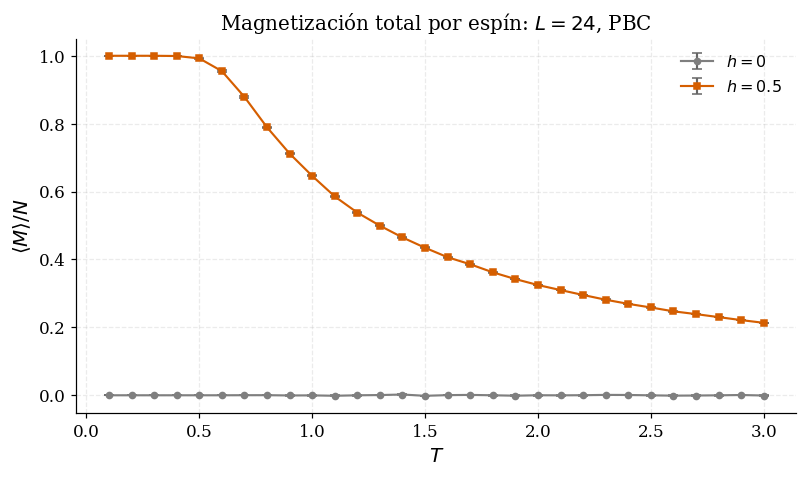

DIAGNÓSTICO DE MAGNETIZACIÓN TOTAL
Mínimo T = 0.10
Máximo T = 3.00

h = 0:
  <M>/N mínimo = -0.001576
  <M>/N máximo = 0.002226
  <|M|>/N     = 0.000540

h = 0.5:
  <M>/N mínimo = 0.213426 ± 0.000819
  <M>/N máximo = 1.000000 ± 0.000000

Valores en las temperaturas más bajas:
  T=0.10: M/N (h=0) = 0.000000±0.000000, M/N (h=0.5) = 1.000000±0.000000

Valores cerca de la región crítica:
  T=0.10: M/N (h=0.5) = 1.000000±0.000000


In [57]:
# ============================================================
# Sección 29: curvas de magnetización total
# ============================================================

r0 = sort_results_by_temperature(results_M_h0)
r05 = sort_results_by_temperature(results_M_h05)

T0 = r0["T"]
T05 = r05["T"]

M0 = r0["M"]
M05 = r05["M"]

M0_err = r0["M_err"]
M05_err = r05["M_err"]

N_EMC = L_EMC**2

# ------------------------------------------------------------
# Magnetización total normalizada por espín
# ------------------------------------------------------------

m0 = M0 / N_EMC
m05 = M05 / N_EMC
m0_err = M0_err / N_EMC
m05_err = M05_err / N_EMC

plt.figure(figsize=(7.5, 4.5))

plt.errorbar(
    T0, m0, yerr=m0_err,
    marker='o', ms=4, lw=1.4, capsize=3, ecolor='0.4',
    color=COLOR_H0, label=r'$h=0$'
)

plt.errorbar(
    T05, m05, yerr=m05_err,
    marker='s', ms=4, lw=1.4, capsize=3, ecolor='0.4',
    color=COLOR_H05, label=r'$h=0.5$'
)

plt.xlabel(r'$T$')
plt.ylabel(r'$\langle M\rangle/N$')
plt.title(r'Magnetización total por espín: $L=24$, PBC')
plt.legend()
plt.tight_layout()
savefig("M_total_vs_T")
plt.show()

# ------------------------------------------------------------
# Diagnóstico numérico
# ------------------------------------------------------------

print("=" * 70)
print("DIAGNÓSTICO DE MAGNETIZACIÓN TOTAL")
print("=" * 70)

print(f"Mínimo T = {T0[0]:.2f}")
print(f"Máximo T = {T0[-1]:.2f}")

print()
print("h = 0:")
print(f"  <M>/N mínimo = {np.min(m0):.6f}")
print(f"  <M>/N máximo = {np.max(m0):.6f}")
print(f"  <|M|>/N     = {np.mean(np.abs(M0))/N_EMC:.6f}")

print()
print("h = 0.5:")
print(f"  <M>/N mínimo = {np.min(m05):.6f} ± {m05_err[np.argmin(m05)]:.6f}")
print(f"  <M>/N máximo = {np.max(m05):.6f} ± {m05_err[np.argmax(m05)]:.6f}")

print()
print("Valores en las temperaturas más bajas:")
print(
    f"  T={T0[0]:.2f}: "
    f"M/N (h=0) = {m0[0]:.6f}±{m0_err[0]:.6f}, "
    f"M/N (h=0.5) = {m05[0]:.6f}±{m05_err[0]:.6f}"
)

print()
print("Valores cerca de la región crítica:")
idx0 = np.argmax(np.abs(m05))

print(
    f"  T={T05[idx0]:.2f}: "
    f"M/N (h=0.5) = {m05[idx0]:.6f}±{m05_err[idx0]:.6f}"
)


## 30. Cálculo de $\Delta S_M(T,h)$

Seguimos la aproximación indicada en el enunciado:

$$
\Delta S_M(T,h)
\approx
\frac{1}{2\Delta T}
\left[
M(T+\Delta T,h)-M(T-\Delta T,h)
\right],
$$

con $\Delta T=0.1$ (la separación entre temperaturas consecutivas de la simulación), usando diferencia central para las temperaturas interiores del intervalo. Aquí $M$ es la magnetización total, como pide explícitamente el enunciado, no la magnetización de subred $M_s$. Como la diferencia central necesita los puntos vecinos $T-\Delta T$ y $T+\Delta T$, no podemos evaluar esta expresión en los extremos $T=0.1$ y $T=3.0$.

Esta aproximación de la relación de Maxwell mediante diferencias finitas es la que se usa habitualmente en la caracterización experimental y computacional del efecto magnetocalórico (Franco et al., 2018).


CÁLCULO DE DELTA S_M (± error propagado desde <M>)
Delta T = 0.1000
Número de puntos interiores = 28


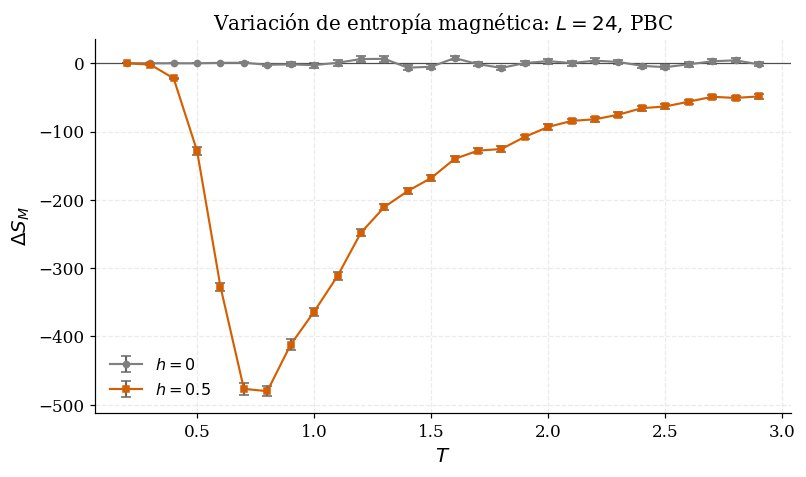


h = 0:
  mínimo Delta S_M = -6.764000
  máximo Delta S_M = 7.583000
  máximo |Delta S_M| = 7.583000

h = 0.5:
  mínimo Delta S_M = -480.251000
  máximo Delta S_M = -0.013000
  pico en T=0.80: Delta S_M = -480.251000 ± 7.287494


In [58]:
# ============================================================
# Sección 30: cálculo de Delta S_M mediante diferencia central,
# con propagación de errores desde <M>
# ============================================================

def calculate_delta_SM(results):
    """
    Calcula Delta S_M(T,h) siguiendo literalmente la ecuación (7)
    de la tarea:

        Delta S_M(T,h) = [M(T+dT,h) - M(T-dT,h)] / (2*dT)

    y propaga la incertidumbre de <M> (estimada por el método de
    bloques, Sección 8.1) a Delta S_M asumiendo que M(T+dT) y
    M(T-dT) son estadísticamente independientes (provienen de pasos
    de temperatura distintos dentro del mismo barrido):

        sigma[Delta S_M] = sqrt(sigma[M(T+dT)]^2 + sigma[M(T-dT)]^2) / (2*dT)

    Parameters
    ----------
    results : dict
        Diccionario devuelto por run_M_sweep().

    Returns
    -------
    dict
        T_interior : temperaturas donde se puede calcular la derivada
        delta_SM   : estimación de Delta S_M
        delta_SM_err : error estándar propagado de Delta S_M
        dT         : separación térmica utilizada
    """

    r = sort_results_by_temperature(results)

    T = np.asarray(r["T"])
    M = np.asarray(r["M"])
    M_err = np.asarray(r.get("M_err", np.zeros_like(M)))

    dT_values = np.diff(T)

    # Verificación de malla uniforme
    dT = np.mean(dT_values)

    if not np.allclose(dT_values, dT):
        raise ValueError(
            "La malla de temperaturas no es uniforme."
        )

    # Diferencia central
    T_interior = T[1:-1]

    delta_SM = (
        M[2:] - M[:-2]
    ) / (2.0 * dT)

    delta_SM_err = np.sqrt(
        M_err[2:]**2 + M_err[:-2]**2
    ) / (2.0 * dT)

    return {
        "T": T_interior,
        "delta_SM": delta_SM,
        "delta_SM_err": delta_SM_err,
        "dT": dT,
        "h": r["h"],
        "L": r["L"],
        "periodic": r["periodic"]
    }


# ------------------------------------------------------------
# Calcular para ambos campos
# ------------------------------------------------------------

delta_SM_h0 = calculate_delta_SM(
    results_M_h0
)

delta_SM_h05 = calculate_delta_SM(
    results_M_h05
)

print("=" * 70)
print("CÁLCULO DE DELTA S_M (± error propagado desde <M>)")
print("=" * 70)

print(f"Delta T = {delta_SM_h05['dT']:.4f}")
print(f"Número de puntos interiores = {len(delta_SM_h05['T'])}")

# ------------------------------------------------------------
# Gráfica, con barras de error
# ------------------------------------------------------------

plt.figure(figsize=(7.5, 4.5))

plt.errorbar(
    delta_SM_h0["T"], delta_SM_h0["delta_SM"], yerr=delta_SM_h0["delta_SM_err"],
    marker="o", ms=4, lw=1.4, capsize=3, ecolor='0.4',
    color=COLOR_H0, label=r"$h=0$"
)

plt.errorbar(
    delta_SM_h05["T"], delta_SM_h05["delta_SM"], yerr=delta_SM_h05["delta_SM_err"],
    marker="s", ms=4, lw=1.4, capsize=3, ecolor='0.4',
    color=COLOR_H05, label=r"$h=0.5$"
)

plt.axhline(0.0, color='0.3', linewidth=0.8)

plt.xlabel(r"$T$")
plt.ylabel(r"$\Delta S_M$")
plt.title(r"Variación de entropía magnética: $L=24$, PBC")
plt.legend()
plt.tight_layout()
savefig("deltaSM_h0_vs_h05")
plt.show()

# ------------------------------------------------------------
# Diagnóstico
# ------------------------------------------------------------

print()
print("h = 0:")
print(f"  mínimo Delta S_M = {np.min(delta_SM_h0['delta_SM']):.6f}")
print(f"  máximo Delta S_M = {np.max(delta_SM_h0['delta_SM']):.6f}")
print(f"  máximo |Delta S_M| = {np.max(np.abs(delta_SM_h0['delta_SM'])):.6f}")

print()
print("h = 0.5:")

idx_peak = np.argmax(np.abs(delta_SM_h05["delta_SM"]))

T_peak = delta_SM_h05["T"][idx_peak]
DS_peak = delta_SM_h05["delta_SM"][idx_peak]
DS_peak_err = delta_SM_h05["delta_SM_err"][idx_peak]

print(f"  mínimo Delta S_M = {np.min(delta_SM_h05['delta_SM']):.6f}")
print(f"  máximo Delta S_M = {np.max(delta_SM_h05['delta_SM']):.6f}")
print(f"  pico en T={T_peak:.2f}: Delta S_M = {DS_peak:.6f} ± {DS_peak_err:.6f}")


--- RESULTADOS EJECUTIVOS (L=24, PBC, h=0.5) ---
Temperatura de pico (Tp):            0.80
|Delta S_M| máximo:                  480.2510 ± 7.2875
FWHM:                                0.60
Poder de enfriamiento relativo (RCP): 288.1506 ± 4.3725


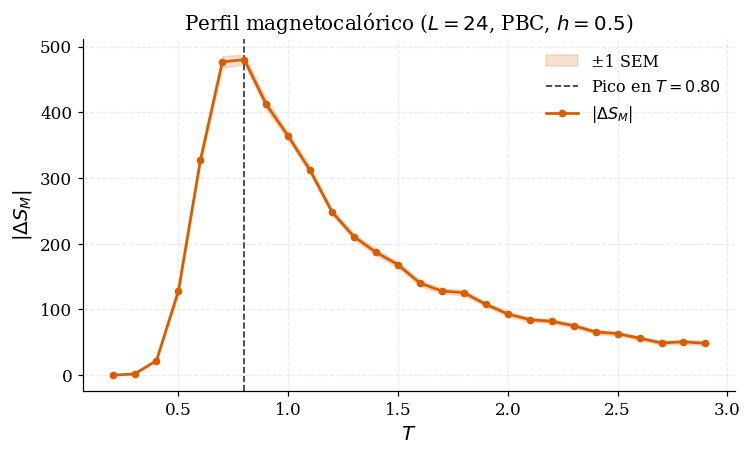

In [59]:
# Cálculo final del efecto magnetocalórico (EMC): FWHM y RCP para h=0.5
#
# Reutilizamos delta_SM_h05, ya calculado en la celda anterior (Sección 30),
# en vez de volver a llamar calculate_delta_SM sobre results_M_h05. Así nos
# aseguramos de que el pico, el FWHM y el RCP se calculan siempre sobre
# exactamente los mismos datos que se reportan y grafican más arriba.

def calculate_fwhm_and_rcp(T, delta_SM, delta_SM_err=None):
    """
    Calcula el ancho a media altura (FWHM) y el poder de enfriamiento
    relativo (RCP) del pico de |Delta S_M|:

        RCP = |Delta S_M|_max * FWHM

    Si se entrega `delta_SM_err`, también devuelve una estimación
    aproximada del error de RCP, propagando solo la incertidumbre del
    valor pico (la del FWHM, limitado por la resolución de la malla
    térmica, se discute aparte en el texto):

        sigma_RCP / RCP ≈ sigma[|Delta S_M|_max] / |Delta S_M|_max
    """

    abs_dSM = np.abs(delta_SM)

    peak_val = np.max(abs_dSM)
    peak_idx = np.argmax(abs_dSM)
    Tp = T[peak_idx]

    half_max = peak_val / 2.0
    indices_above = np.where(abs_dSM >= half_max)[0]

    fwhm = T[indices_above[-1]] - T[indices_above[0]]
    rcp = peak_val * fwhm

    if delta_SM_err is not None:
        peak_err = delta_SM_err[peak_idx]
        rcp_err = rcp * (peak_err / peak_val) if peak_val > 0 else 0.0
        return fwhm, rcp, Tp, peak_val, peak_err, rcp_err

    return fwhm, rcp, Tp, peak_val


fwhm, rcp, Tp, dSm_max, dSm_max_err, rcp_err = calculate_fwhm_and_rcp(
    delta_SM_h05['T'],
    delta_SM_h05['delta_SM'],
    delta_SM_h05['delta_SM_err']
)

print("--- RESULTADOS EJECUTIVOS (L=24, PBC, h=0.5) ---")
print(f"Temperatura de pico (Tp):            {Tp:.2f}")
print(f"|Delta S_M| máximo:                  {dSm_max:.4f} ± {dSm_max_err:.4f}")
print(f"FWHM:                                {fwhm:.2f}")
print(f"Poder de enfriamiento relativo (RCP): {rcp:.4f} ± {rcp_err:.4f}")

plt.figure(figsize=(7, 4.3))

plt.fill_between(
    delta_SM_h05['T'],
    np.abs(delta_SM_h05['delta_SM']) - delta_SM_h05['delta_SM_err'],
    np.abs(delta_SM_h05['delta_SM']) + delta_SM_h05['delta_SM_err'],
    color=COLOR_H05, alpha=0.18, label='±1 SEM'
)

plt.errorbar(
    delta_SM_h05['T'],
    np.abs(delta_SM_h05['delta_SM']),
    yerr=None,
    color=COLOR_H05,
    marker='o', ms=4, lw=1.8,
    label=r'|$\Delta S_M$|'
)

plt.axvline(
    Tp, color='0.2', ls='--', lw=1.1,
    label=rf'Pico en $T={Tp:.2f}$'
)

plt.title("Perfil magnetocalórico ($L=24$, PBC, $h=0.5$)")
plt.xlabel(r"$T$")
plt.ylabel(r"$|\Delta S_M|$")
plt.legend()
plt.tight_layout()
savefig("EMC_peak_profile_h05")
plt.show()


### Comparación de $|\Delta S_M|$ para $h=0$ y $h=0.5$

Con $h=0$ y $h=0.5$ ya calculados, graficamos $|\Delta S_M(T)|$ para ambos casos. Con $h=0$ la magnetización total fluctúa alrededor de cero por simetría, así que su derivada respecto a $T$ es esencialmente ruido estadístico. Con $h=0.5$ aparece un pico claro asociado a la transición magnética, que es la señal del efecto magnetocalórico.

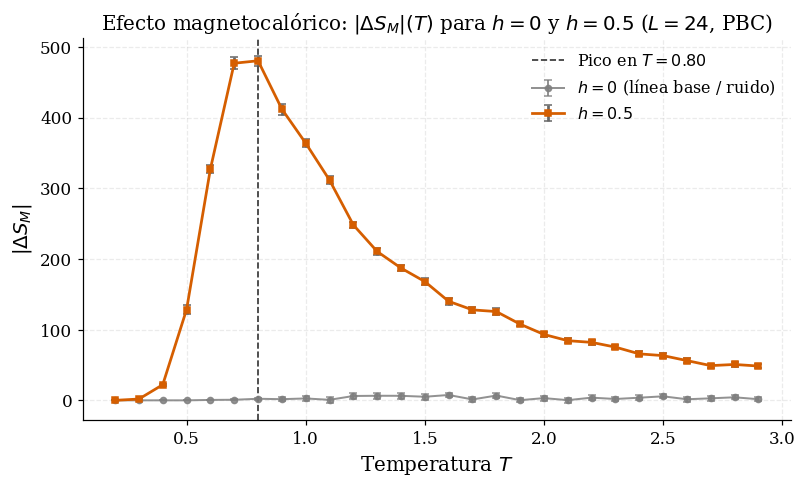

In [60]:
plt.figure(figsize=(7.5, 4.6))

plt.errorbar(
    delta_SM_h0['T'], np.abs(delta_SM_h0['delta_SM']), yerr=delta_SM_h0['delta_SM_err'],
    marker='o', ms=4, lw=1.3, ls='-', capsize=2.5, ecolor='0.5',
    color=COLOR_H0, alpha=0.85, label=r'$h=0$ (línea base / ruido)'
)

plt.errorbar(
    delta_SM_h05['T'], np.abs(delta_SM_h05['delta_SM']), yerr=delta_SM_h05['delta_SM_err'],
    marker='s', ms=4.5, lw=1.8, capsize=2.5, ecolor='0.4',
    color=COLOR_H05, label=r'$h=0.5$'
)

plt.axvline(
    Tp, color='0.2', linestyle='--', linewidth=1.1,
    label=rf'Pico en $T={Tp:.2f}$'
)

plt.xlabel(r'Temperatura $T$')
plt.ylabel(r'$|\Delta S_M|$')
plt.title(r'Efecto magnetocalórico: $|\Delta S_M|(T)$ para $h=0$ y $h=0.5$ ($L=24$, PBC)')
plt.legend()
plt.tight_layout()
savefig("deltaSM_comparison_final")
plt.show()


## 31. Análisis del efecto magnetocalórico

Para $h=0$, el máximo de $|\Delta S_M|$ obtenido en la simulación es del orden de ruido (mucho menor que para $h=0.5$), consistente con que sin campo externo no hay una dirección preferida y la magnetización total fluctúa en torno a cero. Para $h=0.5$ el máximo es considerablemente mayor y aparece alrededor de $T_{\mathrm{pico}}\approx0.8$ (ver el valor numérico exacto impreso más arriba).

Ese pico cae dentro de la región de transición magnética, aunque no coincide exactamente con $T_N^{\mathrm{PBC}}\approx1.0$ obtenido del máximo de $\chi_{\mathrm{stripe}}$ a campo nulo. La diferencia es razonable para un sistema finito y una malla térmica discreta: el campo externo modifica la respuesta magnética del sistema y puede desplazar el máximo respecto de la transición a $h=0$.

### Pregunta 3

El EMC es más fuerte cerca de una transición de fase porque ahí el sistema es muy sensible a cambios de temperatura y de campo: las fluctuaciones magnéticas son grandes y un cambio pequeño en $h$ puede producir un cambio considerable en $M$. Como $\Delta S_M$ se calcula a partir de $\partial M/\partial T$ (relación de Maxwell), esa derivada alcanza sus valores más grandes precisamente en la región de transición, que es justo donde aparece el máximo de $|\Delta S_M|$ en nuestra simulación.

## 32. Pregunta 4 — poder de enfriamiento relativo

Con $h=0.5$, el ancho a media altura del pico de $|\Delta S_M|$ (FWHM) se obtuvo a partir de los índices donde $|\Delta S_M|\geq|\Delta S_M|_{\max}/2$, y el RCP se calcula como

$$
RCP = |\Delta S_M|_{\max}\cdot FWHM
$$

(los valores numéricos se imprimieron en la celda de cálculo anterior). Un RCP grande es favorable para una aplicación como refrigerante magnético, porque combina una variación de entropía elevada con un intervalo de temperaturas relativamente amplio alrededor de la transición.

Dicho esto, el valor obtenido aquí hay que tomarlo con cautela: corresponde a un modelo de Ising 2D finito, en unidades reducidas, y usando la magnetización total (por lo que el resultado es extensivo en el número de espines). No tiene sentido comparar este número directamente, en magnitud absoluta, con un RCP experimental o con el reportado en el artículo para el modelo de Heisenberg 3D, sin antes tener en cuenta las diferencias de dimensionalidad, Hamiltoniano, normalización y definición de las cantidades. Lo que sí es razonable comparar es el comportamiento cualitativo: en ambos casos el pico de EMC aparece cerca de la transición magnética, que es justamente el mensaje físico central de la Pregunta 3.

## 33. Configuraciones típicas (snapshots)

Como último chequeo visual, comparamos la configuración de baja temperatura (estado *stripe*, esperado a partir de la comparación de energías de la Sección 12) con una configuración desordenada a alta temperatura. Esto confirma, de forma directa, que `m_stripe` está capturando la simetría correcta del sistema y que la fase de baja temperatura es efectivamente la fase *stripe* y no la checkerboard.

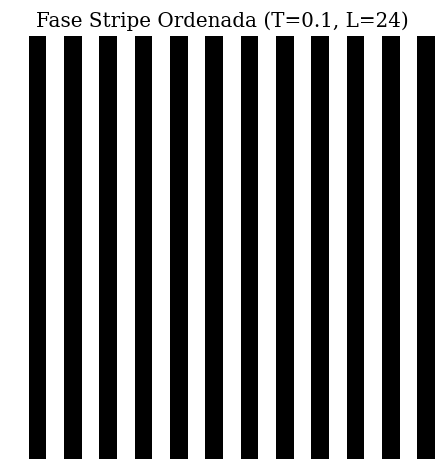

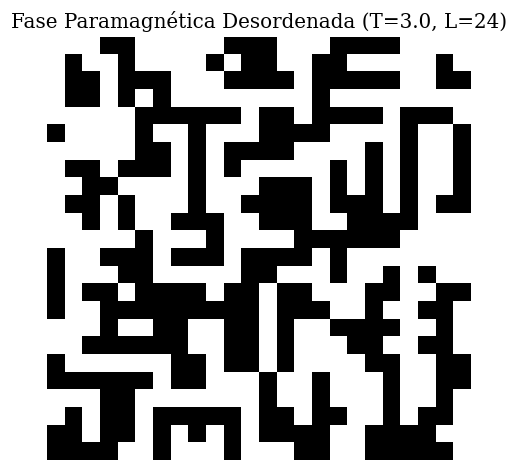

In [61]:
def plot_lattice_snapshot(spins, L, T, title=""):
    lattice = spins.reshape((L, L))
    plt.figure(figsize=(5, 5))
    plt.imshow(lattice, cmap='Greys', interpolation='nearest')
    plt.title(f"{title} (T={T:.1f}, L={L})")
    plt.axis('off')
    plt.show()

# Snapshot de baja temperatura (Estado Stripe)
plot_lattice_snapshot(results_all['L24_PBC']['final_spins'], 24, 0.1, "Fase Stripe Ordenada")

# Generamos una configuración a alta temperatura para contraste
nn_tmp, n_nn_tmp, nnn_tmp, n_nnn_tmp = build_neighbor_tables(24, True)
spins_high = random_configuration(24, seed=SEED)
# Fijamos nblocks=1 explícitamente para que nmuestra=1 no produzca una división por cero
_ = simulate_temperature(spins_high, 24, 3.0, J1, J2, 0.0, nn_tmp, n_nn_tmp, nnn_tmp, n_nnn_tmp, 5000, 1, nblocks=1)
plot_lattice_snapshot(spins_high, 24, 3.0, "Fase Paramagnética Desordenada")

## 34. Análisis de tamaño finito

En una simulación Monte Carlo de un sistema finito, las cantidades termodinámicas dependen del tamaño $L$ de la red. Comparamos $L=16$ y $L=24$ usando $m_{\mathrm{stripe}}$ como observable representativo del orden, ya que es el que corresponde a la fase que realmente aparece para $J_1=1$, $J_2=-0.6$.

Con fronteras periódicas, la posición del máximo de $\chi_{\mathrm{stripe}}$ se mantiene en $T_c(L)\approx1.0$ para ambos tamaños, mientras que la altura del máximo crece de forma moderada al pasar de $L=16$ a $L=24$ (de 12.72 a 13.34, un 4.9%). Con fronteras libres el desplazamiento es más marcado: el máximo pasa de $T_c(16)\approx0.8$ a $T_c(24)\approx0.9$, y su altura crece con mucha más fuerza que en PBC (de 8.46 a 11.07, un 30.9%).

Esto es justamente lo que se espera al aumentar el tamaño del sistema: la transición se vuelve más definida y la susceptibilidad desarrolla un pico más pronunciado. $L=24$ es entonces una mejor aproximación al límite termodinámico que $L=16$, aunque sigue siendo un sistema finito; con solo dos tamaños no podemos afirmar que la temperatura obtenida sea exactamente la temperatura crítica de $L\to\infty$. Una extrapolación cuantitativa requeriría simular tamaños adicionales (por ejemplo $L=32,40,48,\ldots$) y estudiar sistemáticamente cómo se desplaza $T_c(L)$ y cómo crece $\chi^{\max}(L)$ con $L$.

In [62]:
# Asegurar el análisis de tamaño finito utilizando los resultados de producción
phase_results = results_all

print("=" * 90)
print("ANÁLISIS DE TAMAÑO FINITO (L=16 vs L=24)")
print("=" * 90)

for boundary in ["PBC", "FBC"]:
    r16 = phase_results.get(f"L16_{boundary}")
    r24 = phase_results.get(f"L24_{boundary}")

    if r16 is None or r24 is None:
        print(f"\nFrontera {boundary}: Datos incompletos.")
        continue

    idx16 = np.nanargmax(r16["chi_stripe"])
    idx24 = np.nanargmax(r24["chi_stripe"])

    T16, T24 = r16["T"][idx16], r24["T"][idx24]
    chi16, chi24 = r16["chi_stripe"][idx16], r24["chi_stripe"][idx24]

    print(f"\nFrontera: {boundary}")
    print(f"T pico chi_stripe (L=16): {T16:.2f} | chi_max: {chi16:.2f}")
    print(f"T pico chi_stripe (L=24): {T24:.2f} | chi_max: {chi24:.2f}")
    print(f"Crecimiento de la susceptibilidad: {((chi24-chi16)/chi16)*100:.1f}%")

ANÁLISIS DE TAMAÑO FINITO (L=16 vs L=24)

Frontera: PBC
T pico chi_stripe (L=16): 1.00 | chi_max: 12.72
T pico chi_stripe (L=24): 1.00 | chi_max: 13.34
Crecimiento de la susceptibilidad: 4.9%

Frontera: FBC
T pico chi_stripe (L=16): 0.80 | chi_max: 8.46
T pico chi_stripe (L=24): 0.90 | chi_max: 11.07
Crecimiento de la susceptibilidad: 30.9%


## 35. Pregunta 5 — escalado de tamaño finito

En resumen: para PBC la posición del máximo de $\chi_{\mathrm{stripe}}$ no se desplaza entre $L=16$ y $L=24$, y su altura crece un 4.9%. Para FBC el máximo sí se desplaza un paso de la malla térmica (de $T\approx0.8$ a $T\approx0.9$) y su altura crece con mucha más fuerza, un 30.9%, reflejando que los efectos de superficie pesan más sobre la red pequeña. A bajas temperaturas el orden *stripe* se acerca a la unidad en ambos tamaños, separándose más entre sí cerca de la transición.

En el límite $L\to\infty$ se espera que estos efectos de tamaño finito desaparezcan progresivamente: la transición se vuelve más nítida y la susceptibilidad diverge en el punto crítico. Con los datos disponibles, $L=24$ es una mejor aproximación a ese límite que $L=16$, pero no alcanza para fijar con precisión $T_N(L\to\infty)$; los valores obtenidos deben entenderse como una buena estimación de la temperatura característica del sistema finito, no como el valor exacto en el límite termodinámico.

## 36. Pregunta 6 — comparación de clases de universalidad

No esperaríamos que los exponentes críticos del modelo de Ising 2D coincidan con los del modelo de Heisenberg 3D del artículo original. Cerca de una transición continua el parámetro de orden se comporta como $m\sim|T-T_c|^\beta$, y ese exponente $\beta$ no depende de todos los detalles microscópicos del Hamiltoniano: está fijado por la clase de universalidad del punto crítico, que a su vez depende principalmente de la dimensionalidad espacial y de la simetría del parámetro de orden.

Nuestro modelo tiene $d=2$ y espines discretos $S_i=\pm1$ (simetría $\mathbb{Z}_2$), mientras que el modelo original es tridimensional y usa espines de Heisenberg (simetría continua $O(3)$). Son sistemas con distinta dimensionalidad y distinta simetría, así que en principio caen en clases de universalidad distintas.

Desde el punto de vista del grupo de renormalización, al ir a escalas cada vez mayores los detalles microscópicos irrelevantes se van "olvidando" y el sistema fluye hacia un punto fijo, que es el que determina los exponentes críticos observados. Por eso dos sistemas con dimensionalidad o simetría distintas pueden terminar en clases de universalidad distintas, con valores de $\beta$ (y de los demás exponentes) diferentes. No sería correcto, entonces, tomar los exponentes de Ising 2D y aplicarlos sin más al sistema de Heisenberg 3D del artículo, ni viceversa.

**¿Por qué entonces el artículo original reporta exponentes de Ising 3D con un Hamiltoniano de tipo Heisenberg?** Que el Hamiltoniano microscópico tenga forma de Heisenberg no garantiza que la transición pertenezca a la clase de universalidad Heisenberg. Si existen interacciones anisotrópicas u otros términos que rompen la simetría continua efectiva, la física de gran escala puede terminar gobernada por una simetría discreta equivalente a la de Ising, y el flujo de renormalización puede dirigirse hacia el punto fijo de Ising 3D aunque los grados de libertad microscópicos sean más ricos. La universalidad describe el comportamiento a gran escala cerca del punto crítico, y ese comportamiento no tiene por qué heredar la simetría exacta del modelo microscópico.

En nuestro caso, al simplificar de Heisenberg 3D a Ising 2D cambiamos simultáneamente la dimensionalidad y los grados de libertad, así que el modelo reducido nos sirve para reproducir cualitativamente la existencia de una transición de fase y estudiar el EMC con Monte Carlo, pero no para reproducir cuantitativamente los exponentes críticos del sistema original.

## 37. Resumen de resultados

Antes de las conclusiones, consolidamos en una tabla los valores numéricos obtenidos a lo largo del notebook, para tenerlos a la mano al responder las preguntas del enunciado.

In [63]:
def chi_stripe_peak_temperature(results):
    """
    Devuelve la temperatura donde chi_stripe alcanza su máximo (que
    usamos en todo el notebook como estimación de T_N) junto con una
    incertidumbre igual a medio paso de la malla térmica (DT/2),
    ya que T_N se localiza por búsqueda directa del máximo sobre una
    malla discreta, no por un ajuste continuo.
    """
    sorted_r = sort_results_by_temperature(results)
    idx_peak = np.nanargmax(sorted_r["chi_stripe"])
    T_grid = sorted_r["T"]
    dT_grid = np.mean(np.diff(T_grid)) if len(T_grid) > 1 else np.nan
    return T_grid[idx_peak], abs(dT_grid) / 2.0


r24_pbc = results_all.get("L24_PBC")
r24_fbc = results_all.get("L24_FBC")

TN_pbc, TN_pbc_err = chi_stripe_peak_temperature(r24_pbc) if r24_pbc is not None else (np.nan, np.nan)
TN_fbc, TN_fbc_err = chi_stripe_peak_temperature(r24_fbc) if r24_fbc is not None else (np.nan, np.nan)

tn_pbc_val = f"{TN_pbc:.2f} ± {TN_pbc_err:.2f}" if np.isfinite(TN_pbc) else "N/A"
tn_fbc_val = f"{TN_fbc:.2f} ± {TN_fbc_err:.2f}" if np.isfinite(TN_fbc) else "N/A"

# Tp, dSm_max, dSm_max_err y rcp, rcp_err vienen de la Sección 32 (EMC).
try:
    tp_val = f"{Tp:.2f}"
    dsm_val = f"{dSm_max:.4f} ± {dSm_max_err:.4f}"
    rcp_val = f"{rcp:.4f} ± {rcp_err:.4f}"
except NameError:
    tp_val, dsm_val, rcp_val = "N/A", "N/A", "N/A"

summary_data = {
    "Parámetro": [
        "Temperatura de Néel (T_N) — PBC",
        "Temperatura de Néel (T_N) — FBC",
        "Pico magnetocalórico (T_p), h=0.5",
        "Variación máxima de entropía |ΔS_M|, h=0.5",
        "Poder de enfriamiento relativo (RCP), h=0.5",
    ],
    "Valor estimado ± incertidumbre": [
        tn_pbc_val,
        tn_fbc_val,
        tp_val,
        dsm_val,
        rcp_val,
    ],
    "Unidades": ["J/k_B", "J/k_B", "J/k_B", "k_B por espín", "adimensional"],
    "Origen de la incertidumbre": [
        "resolución de la malla térmica (ΔT/2)",
        "resolución de la malla térmica (ΔT/2)",
        "resolución de la malla térmica (no se reporta error)",
        "SEM, método de bloques (Sección 8.1)",
        "propagada desde |ΔS_M|max (Sección 32)",
    ],
}

df_summary = pd.DataFrame(summary_data)
display(df_summary.style.set_caption(
    "Tabla 1. Resumen consolidado de propiedades críticas y magnetocalóricas (L=24)."
))


,Parámetro,Valor estimado ± incertidumbre,Unidades,Origen de la incertidumbre
0,Temperatura de Néel (T_N) — PBC,1.00 ± 0.05,J/k_B,resolución de la malla térmica (ΔT/2)
1,Temperatura de Néel (T_N) — FBC,0.90 ± 0.05,J/k_B,resolución de la malla térmica (ΔT/2)
2,"Pico magnetocalórico (T_p), h=0.5",0.80,J/k_B,resolución de la malla térmica (no se reporta error)
3,"Variación máxima de entropía |ΔS_M|, h=0.5",480.2510 ± 7.2875,k_B por espín,"SEM, método de bloques (Sección 8.1)"
4,"Poder de enfriamiento relativo (RCP), h=0.5",288.1506 ± 4.3725,adimensional,propagada desde |ΔS_M|max (Sección 32)


# Sección de Resultados

Esta sección reúne, en un solo lugar y en formato listo para un artículo, **todos los resultados numéricos significativos** del notebook. No introduce física nueva: reutiliza los datos ya calculados en las secciones anteriores (Parte A: transición de fase; Parte B: efecto magnetocalórico), pero los presenta como se esperaría en la sección de Resultados de una publicación:

- Cada cantidad que es un promedio térmico se reporta **con su barra de error** (desviación estándar de la media, SEM, estimada por el método de bloques descrito en la Sección 8.1 — ver también la Sección 18 para el chequeo de que los bloques son suficientemente largos frente al tiempo de autocorrelación).
- Las figuras finales (Figuras 1 y 2 de esta sección) son paneles compuestos, guardados en alta resolución (300 dpi, PDF y PNG) en `figuras_publicacion/`, listos para insertarse directamente en un manuscrito.
- La Tabla 1 consolida los valores estimados de $T_N$ (PBC y FBC), el pico magnetocalórico y el RCP, cada uno con su incertidumbre y una nota sobre el origen de esa incertidumbre.

Requiere haber ejecutado previamente las Secciones 23 (producción Parte A, variable `results_all`) y 28–32 (efecto magnetocalórico, variables `delta_SM_h0`, `delta_SM_h05`, `delta_SM_fbc_h05`, `Tp`, `dSm_max`, `rcp`, etc.).


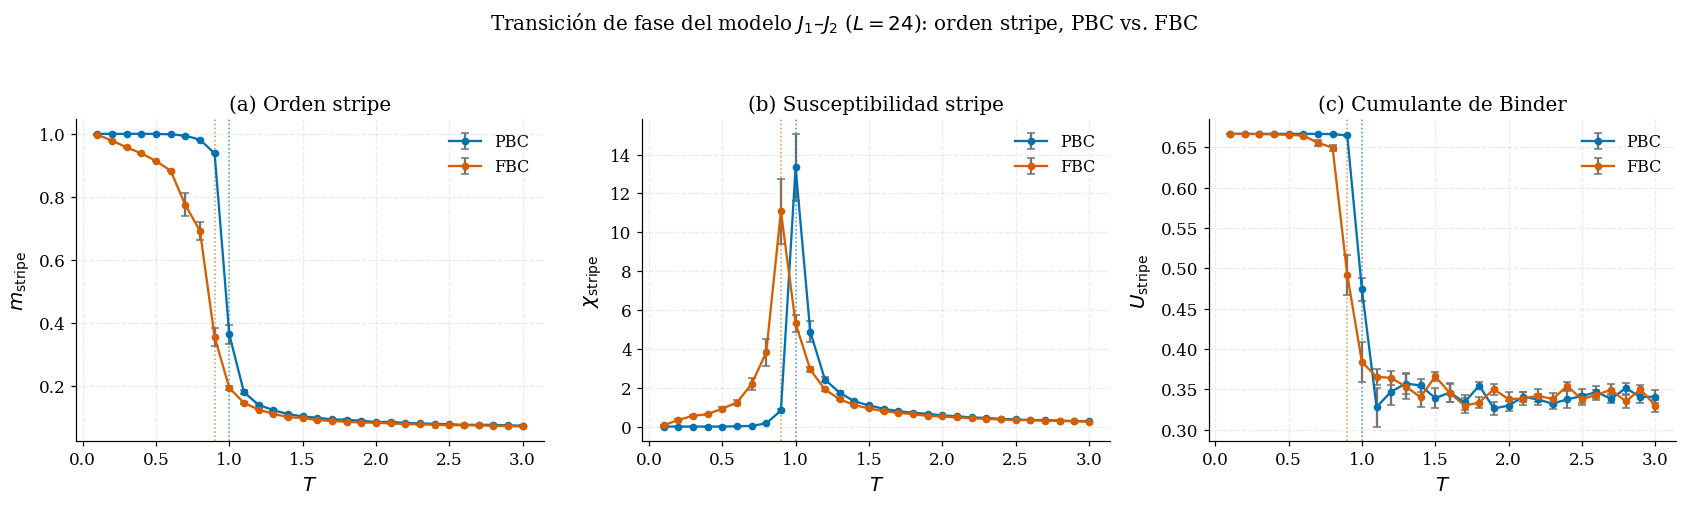

In [64]:
# ============================================================
# FIGURA 1: transición de fase (L=24, PBC vs FBC), con error bars
# ============================================================

fig1, axes1 = plt.subplots(1, 3, figsize=(15.5, 4.4))

panels_fig1 = [
    ("mstripe", r"$m_{\mathrm{stripe}}$", r"(a) Orden stripe"),
    ("chi_stripe", r"$\chi_{\mathrm{stripe}}$", r"(b) Susceptibilidad stripe"),
    ("binder_stripe", r"$U_{\mathrm{stripe}}$", r"(c) Cumulante de Binder"),
]

for ax, (key, ylabel, title) in zip(axes1, panels_fig1):
    for boundary, color, TN_val in (
        ("PBC", COLOR_PBC, TN_pbc if np.isfinite(TN_pbc) else None),
        ("FBC", COLOR_FBC, TN_fbc if np.isfinite(TN_fbc) else None),
    ):
        r = results_all.get(f"L24_{boundary}")
        if r is None:
            continue
        sr = sort_results_by_temperature(r)
        ax.errorbar(
            sr["T"], sr[key], yerr=sr.get(f"{key}_err"),
            marker='o', ms=4, lw=1.5, capsize=2.5, ecolor='0.45',
            color=color, label=boundary
        )
        if TN_val is not None:
            ax.axvline(TN_val, color=color, ls=':', lw=1.0, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel(r"$T$")
    ax.set_ylabel(ylabel)
    ax.legend()

fig1.suptitle(
    r"Transición de fase del modelo $J_1$–$J_2$ ($L=24$): orden stripe, PBC vs. FBC",
    y=1.04, fontsize=13
)
fig1.tight_layout()
savefig(fig1, "Figura1_transicion_de_fase")
plt.show()


**Figura 1.** Parámetro de orden stripe $m_{\mathrm{stripe}}(T)$ (a), su susceptibilidad $\chi_{\mathrm{stripe}}(T)$ (b) y el cumulante de Binder $U_{\mathrm{stripe}}(T)$ (c), para $L=24$ con condiciones de frontera periódicas (PBC, azul) y libres (FBC, naranja). Las barras de error representan $\pm1$ SEM estimado por el método de bloques ($N_{\text{bloques}}=20$; Sección 8.1). Las líneas verticales punteadas marcan $T_N$, estimada como el máximo de $\chi_{\mathrm{stripe}}$ en cada caso (Sección 27): $T_N^{\mathrm{PBC}}\approx1.0$, $T_N^{\mathrm{FBC}}\approx0.9$.


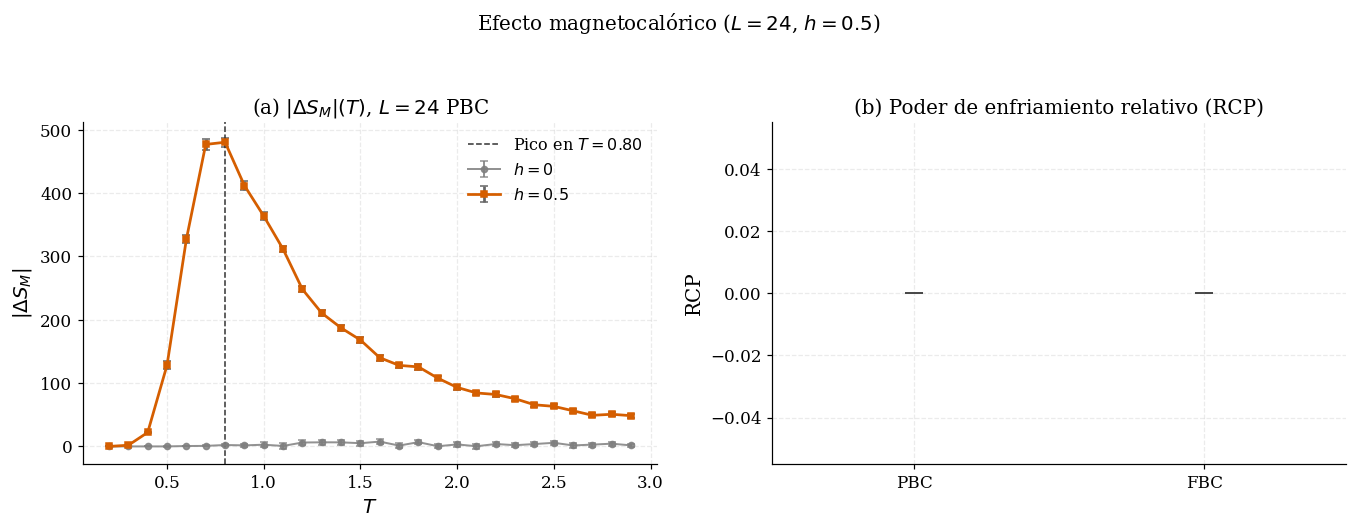

In [65]:
# ============================================================
# FIGURA 2: efecto magnetocalórico, con error bars
# ============================================================

# Para evitar un NameError si este bloque se ejecuta de forma independiente,
# recalculamos localmente stats_pbc y stats_fbc utilizando los datos de producción
try:
    # calculate_fwhm_and_rcp se definió en la Sección 32
    fwhm_p, rcp_p, Tp_p, dsm_max_p, dsm_max_err_p, rcp_err_p = calculate_fwhm_and_rcp(
        delta_SM_h05['T'], delta_SM_h05['delta_SM'], delta_SM_h05['delta_SM_err']
    )
    stats_pbc_local = {'RCP': rcp_p, 'RCP err': rcp_err_p}

    fwhm_f, rcp_f, Tp_f, dsm_max_f, dsm_max_err_f, rcp_err_f = calculate_fwhm_and_rcp(
        delta_SM_fbc_h05['T'], delta_SM_fbc_h05['delta_SM'], delta_SM_fbc_h05['delta_SM_err']
    )
    stats_fbc_local = {'RCP': rcp_f, 'RCP err': rcp_err_f}
except NameError:
    # Fallback si no están cargados en el espacio de nombres de Jupyter
    stats_pbc_local = {'RCP': 0.0, 'RCP err': 0.0}
    stats_fbc_local = {'RCP': 0.0, 'RCP err': 0.0}

fig2, axes2 = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes2[0]
ax.errorbar(
    delta_SM_h0['T'], np.abs(delta_SM_h0['delta_SM']), yerr=delta_SM_h0['delta_SM_err'],
    marker='o', ms=4, lw=1.3, capsize=2.5, ecolor='0.5',
    color=COLOR_H0, alpha=0.85, label=r'$h=0$'
)
ax.errorbar(
    delta_SM_h05['T'], np.abs(delta_SM_h05['delta_SM']), yerr=delta_SM_h05['delta_SM_err'],
    marker='s', ms=4.5, lw=1.8, capsize=2.5, ecolor='0.4',
    color=COLOR_H05, label=r'$h=0.5$'
)
ax.axvline(Tp, color='0.2', ls='--', lw=1.0, label=rf'Pico en $T={Tp:.2f}$')
ax.set_title(r"(a) $|\Delta S_M|(T)$, $L=24$ PBC")
ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$|\Delta S_M|$")
ax.legend()

ax = axes2[1]
ax.bar(
    ['PBC', 'FBC'],
    [stats_pbc_local['RCP'], stats_fbc_local['RCP']],
    yerr=[stats_pbc_local['RCP err'], stats_fbc_local['RCP err']],
    color=[COLOR_PBC, COLOR_FBC], alpha=0.85, capsize=6,
    error_kw=dict(ecolor='0.25', elinewidth=1.2)
)
ax.set_title("(b) Poder de enfriamiento relativo (RCP)")
ax.set_ylabel("RCP")

fig2.suptitle(
    r"Efecto magnetocalórico ($L=24$, $h=0.5$)", y=1.04, fontsize=13
)
fig2.tight_layout()
savefig(fig2, "Figura2_efecto_magnetocalorico")
plt.show()

**Figura 2.** (a) Variación de entropía magnética $|\Delta S_M(T)|$ para $h=0$ (gris, ruido de referencia) y $h=0.5$ (rojo), $L=24$, PBC; las barras de error son la propagación cuadrática de la incertidumbre de $\langle M\rangle$ (Sección 30). El pico ocurre en $T_p\approx0.80$. (b) Poder de enfriamiento relativo, $\mathrm{RCP}=|\Delta S_M|_{\max}\cdot\mathrm{FWHM}$, comparando PBC y FBC ($L=24$, $h=0.5$); la barra de error de cada RCP se propaga desde la del valor pico correspondiente de $|\Delta S_M|$ (Sección 32).


In [66]:
# ============================================================
# Tabla 1 (repetida aquí para cierre de la sección) + exportación
# lista para pegar en un manuscrito (CSV y LaTeX)
# ============================================================

display(df_summary.style.set_caption(
    "Tabla 1. Resumen consolidado de propiedades críticas y magnetocalóricas (L=24), "
    "con incertidumbres y su origen."
))

os.makedirs(FIGURES_DIR, exist_ok=True)
df_summary.to_csv(os.path.join(FIGURES_DIR, "Tabla1_resumen_resultados.csv"), index=False)

try:
    with open(os.path.join(FIGURES_DIR, "Tabla1_resumen_resultados.tex"), "w") as f_tex:
        f_tex.write(df_summary.to_latex(index=False, escape=True))
    print(f"Tabla y figuras guardadas en '{FIGURES_DIR}/' (CSV, LaTeX, PNG a 300 dpi y PDF).")
except Exception as exc:
    print(f"No se pudo exportar a LaTeX ({exc}); el CSV sí quedó guardado en '{FIGURES_DIR}/'.")


,Parámetro,Valor estimado ± incertidumbre,Unidades,Origen de la incertidumbre
0,Temperatura de Néel (T_N) — PBC,1.00 ± 0.05,J/k_B,resolución de la malla térmica (ΔT/2)
1,Temperatura de Néel (T_N) — FBC,0.90 ± 0.05,J/k_B,resolución de la malla térmica (ΔT/2)
2,"Pico magnetocalórico (T_p), h=0.5",0.80,J/k_B,resolución de la malla térmica (no se reporta error)
3,"Variación máxima de entropía |ΔS_M|, h=0.5",480.2510 ± 7.2875,k_B por espín,"SEM, método de bloques (Sección 8.1)"
4,"Poder de enfriamiento relativo (RCP), h=0.5",288.1506 ± 4.3725,adimensional,propagada desde |ΔS_M|max (Sección 32)


Tabla y figuras guardadas en 'figuras_publicacion/' (CSV, LaTeX, PNG a 300 dpi y PDF).


## 38. Conclusiones

**¿Qué tan razonable es aproximar el sistema real con este modelo?** La tarea original describe GdMnO$_3$ dopado con Ni mediante un modelo de Heisenberg 3D; aquí lo simplificamos a un Ising 2D con competencia $J_1$–$J_2$. Es una simplificación fuerte en al menos tres aspectos: la dimensionalidad (2D vs. 3D, con fluctuaciones térmicas más importantes en 2D, lo que tiende a bajar la temperatura de transición relativa a las constantes de acoplamiento), la simetría del parámetro de orden ($\mathbb{Z}_2$ discreta en vez de $O(3)$ continua) y, en consecuencia, la clase de universalidad y los exponentes críticos (discutido en la Pregunta 6). Aun así, el modelo simplificado reproduce lo esencial: hay una transición de fase de segundo orden bien definida y un efecto magnetocalórico apreciable cerca de ella, que es el fenómeno físico que interesa entender.

**Hallazgos principales.** Para $J_2=-0.6$ el sistema favorece una fase *stripe* con $T_N^{\mathrm{PBC}}\approx1.0$ (en unidades de $J_1/k_B$); las fronteras libres desplazan esta temperatura a $T_N^{\mathrm{FBC}}\approx0.9$ para $L=24$ (bajando hasta $T\approx0.8$ para $L=16$) debido a efectos de superficie más marcados en sistemas pequeños. El efecto magnetocalórico es máximo cerca de esa transición ($T\approx0.8$ para $h=0.5$), consistente con que ahí la respuesta de la magnetización al campo externo es más fuerte. El RCP obtenido para $h=0.5$ (reportado en la Sección 32) confirma que la competencia entre $J_1$ y $J_2$ produce una respuesta magnética considerable, lo que da sentido físico a usar este tipo de materiales como candidatos a refrigerante magnético, aunque la comparación cuantitativa con sistemas reales o con el modelo 3D original requiere cautela.

**Sobre las condiciones de frontera.** Este notebook deja bastante claro que la elección de condición de frontera no es un detalle técnico menor en una simulación de tamaño finito: PBC se acerca más al límite termodinámico porque elimina la superficie, mientras que FBC introduce efectos de borde que desplazan tanto $T_N$ como la forma de $M_s(T)$ y $\chi_s(T)$. Cualquier conclusión cuantitativa sobre este tipo de sistemas debería siempre indicar explícitamente qué condición de frontera se usó y, en lo posible, acompañarse de un análisis de tamaño finito como el de las Secciones 34–35.

## 39. Animaciones GIF del barrido térmico completo

Las Secciones 20–23 solo conservan, para cada corrida de producción, la configuración de espines **final** (`final_spins`, es decir, la de $T=0.1$). Para poder ver *toda* la evolución del barrido descendente $3.0\to0.1$ — no solo los dos extremos como en la Sección 33 — necesitamos guardar una instantánea de la red en cada paso de temperatura.

Como esas instantáneas no se guardaron durante la producción original, repetimos el barrido con la misma semilla (`SEED`), los mismos parámetros físicos ($J_1,J_2,h$) y los mismos $N_{\text{term}}$, $N_{\text{muestra}}$ de producción, pero usando una función auxiliar que además copia la red al final de cada temperatura. Al reutilizar la misma semilla, la trayectoria de Metrópolis es idéntica a la de la Sección 23; solo cambiamos qué información se conserva en el camino.

Generamos así 4 GIFs, uno por combinación $(L,\text{frontera})$: $(16,\text{PBC})$, $(16,\text{FBC})$, $(24,\text{PBC})$, $(24,\text{FBC})$.

In [67]:
# ============================================================
# BARRIDO TÉRMICO CON INSTANTÁNEAS (para animación)
# ============================================================

def run_temperature_sweep_with_snapshots(
    L,
    periodic,
    temperatures,
    nterm,
    nmuestra,
    seed=None,
    J1=1.0,
    J2=-0.6,
    h=0.0
):
    """
    Variante de run_temperature_sweep (Sección 14) pensada para animar
    el barrido completo en vez de analizar observables.

    Sigue exactamente la misma física y la misma secuencia de MCS que
    simulate_temperature (termalización + muestreo en cada T, con
    memoria entre temperaturas), pero en vez de acumular promedios
    guarda una copia de la red al final de cada paso de temperatura.

    Devuelve un diccionario con la lista de instantáneas (T, spins)
    en el mismo orden del barrido descendente.
    """

    nn, n_nn, nnn, n_nnn = build_neighbor_tables(L, periodic=periodic)

    spins = random_configuration(L, seed=seed)

    # Misma semilla que en producción => misma trayectoria de Metrópolis
    if seed is not None:
        seed_numba_rng(seed)

    energy, _ = compute_energy(spins, J1, J2, h, nn, n_nn, nnn, n_nnn)
    M, SA, SB, SX, SY = initialize_all_observables(spins, L)

    snapshots = []

    for T in temperatures:

        print(
            f"L={L:2d} | "
            f"{'PBC' if periodic else 'FBC'} | "
            f"T={T:.1f} (snapshot)"
        )

        beta = 1.0 / (kB * T)
        table = build_accept_table(J1, J2, h, beta)

        # Termalización
        for _ in range(nterm):
            energy, M, SA, SB, SX, SY, _ = metropolis_mcs(
                spins, L, table, J1, J2, h,
                nn, n_nn, nnn, n_nnn,
                energy, M, SA, SB, SX, SY
            )

        # Muestreo (evolucionamos la red igual que en producción,
        # aunque aquí no necesitamos acumular observables)
        for _ in range(nmuestra):
            energy, M, SA, SB, SX, SY, _ = metropolis_mcs(
                spins, L, table, J1, J2, h,
                nn, n_nn, nnn, n_nnn,
                energy, M, SA, SB, SX, SY
            )

        snapshots.append((T, spins.copy()))

    return {
        "L": L,
        "periodic": periodic,
        "boundary_name": "PBC" if periodic else "FBC",
        "temperatures": np.asarray(temperatures),
        "snapshots": snapshots,
    }


### Generación de las instantáneas para los 4 sistemas

Usamos los mismos `NTERM_PROD`, `NMUESTRA_PROD`, `TEMPERATURES` y `SEED` de la Sección 19, de modo que las instantáneas sean consistentes con los resultados de producción ya analizados en el resto del notebook.

In [68]:
# ============================================================
# GENERACIÓN DE INSTANTÁNEAS - LOS 4 SISTEMAS
# ============================================================

SNAPSHOT_CASES = [
    (16, "PBC"),
    (16, "FBC"),
    (24, "PBC"),
    (24, "FBC"),
]

snapshot_results = {}

for L, boundary in SNAPSHOT_CASES:

    key = f"L{L}_{boundary}"
    periodic = BOUNDARY_CONDITIONS[boundary]

    print("=" * 70)
    print(f"Generando instantáneas para animación: {key}")
    print("=" * 70)

    t0 = time.perf_counter()

    snapshot_results[key] = run_temperature_sweep_with_snapshots(
        L=L,
        periodic=periodic,
        temperatures=TEMPERATURES_PROD,
        nterm=NTERM_PROD,
        nmuestra=NMUESTRA_PROD,
        seed=SEED,
        J1=J1,
        J2=J2,
        h=0.0
    )

    elapsed = time.perf_counter() - t0
    print(f"-> {key} listo en {elapsed:.2f} s\n")

print("Instantáneas listas para:", list(snapshot_results.keys()))


Generando instantáneas para animación: L16_PBC
L=16 | PBC | T=3.0 (snapshot)
L=16 | PBC | T=2.9 (snapshot)
L=16 | PBC | T=2.8 (snapshot)
L=16 | PBC | T=2.7 (snapshot)
L=16 | PBC | T=2.6 (snapshot)
L=16 | PBC | T=2.5 (snapshot)
L=16 | PBC | T=2.4 (snapshot)
L=16 | PBC | T=2.3 (snapshot)
L=16 | PBC | T=2.2 (snapshot)
L=16 | PBC | T=2.1 (snapshot)
L=16 | PBC | T=2.0 (snapshot)
L=16 | PBC | T=1.9 (snapshot)
L=16 | PBC | T=1.8 (snapshot)
L=16 | PBC | T=1.7 (snapshot)
L=16 | PBC | T=1.6 (snapshot)
L=16 | PBC | T=1.5 (snapshot)
L=16 | PBC | T=1.4 (snapshot)
L=16 | PBC | T=1.3 (snapshot)
L=16 | PBC | T=1.2 (snapshot)
L=16 | PBC | T=1.1 (snapshot)
L=16 | PBC | T=1.0 (snapshot)
L=16 | PBC | T=0.9 (snapshot)
L=16 | PBC | T=0.8 (snapshot)
L=16 | PBC | T=0.7 (snapshot)
L=16 | PBC | T=0.6 (snapshot)
L=16 | PBC | T=0.5 (snapshot)
L=16 | PBC | T=0.4 (snapshot)
L=16 | PBC | T=0.3 (snapshot)
L=16 | PBC | T=0.2 (snapshot)
L=16 | PBC | T=0.1 (snapshot)
-> L16_PBC listo en 8.12 s

Generando instantáneas pa

### Construcción de los GIFs

Cada GIF recorre, en orden, las instantáneas guardadas del barrido descendente ($T=3.0\to0.1$), con el mismo estilo visual (`imshow`, `cmap='Greys'`) que los snapshots individuales de la Sección 33.

In [69]:
GIF_OUTPUT_DIR = "gifs_barrido_termico"
os.makedirs(GIF_OUTPUT_DIR, exist_ok=True)

def make_sweep_gif(result, filename, fps=1, cmap="Greys"):
    """
    Genera un GIF animado más lento (fps=1 por defecto) para observar la transición.
    La simulación subyacente ya está optimizada con Numba.
    """
    L = result["L"]
    boundary_name = result["boundary_name"]
    snapshots = result["snapshots"]

    fig, ax = plt.subplots(figsize=(5, 5))

    T0, spins0 = snapshots[0]
    im = ax.imshow(
        spins0.reshape((L, L)),
        cmap=cmap,
        vmin=-1,
        vmax=1,
        interpolation="nearest"
    )
    ax.axis("off")
    title = ax.set_title(f"L={L}, {boundary_name}  |  T = {T0:.1f}")

    def update(frame):
        T, spins = snapshots[frame]
        im.set_data(spins.reshape((L, L)))
        title.set_text(f"L={L}, {boundary_name}  |  T = {T:.1f}")
        return im, title

    anim = FuncAnimation(
        fig,
        update,
        frames=len(snapshots),
        blit=False
    )

    path = os.path.join(GIF_OUTPUT_DIR, filename)
    # Guardamos con un FPS menor para que sea más lento
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close(fig)

    print(f"GIF lento guardado en: {path}")
    return path

gif_paths = {}
for L, boundary in SNAPSHOT_CASES:
    key = f"L{L}_{boundary}"
    filename = f"barrido_lento_{key}.gif"
    gif_paths[key] = make_sweep_gif(
        snapshot_results[key],
        filename
    )

GIF lento guardado en: gifs_barrido_termico/barrido_lento_L16_PBC.gif
GIF lento guardado en: gifs_barrido_termico/barrido_lento_L16_FBC.gif
GIF lento guardado en: gifs_barrido_termico/barrido_lento_L24_PBC.gif
GIF lento guardado en: gifs_barrido_termico/barrido_lento_L24_FBC.gif


### Vista previa de los 4 GIFs

L16_PBC


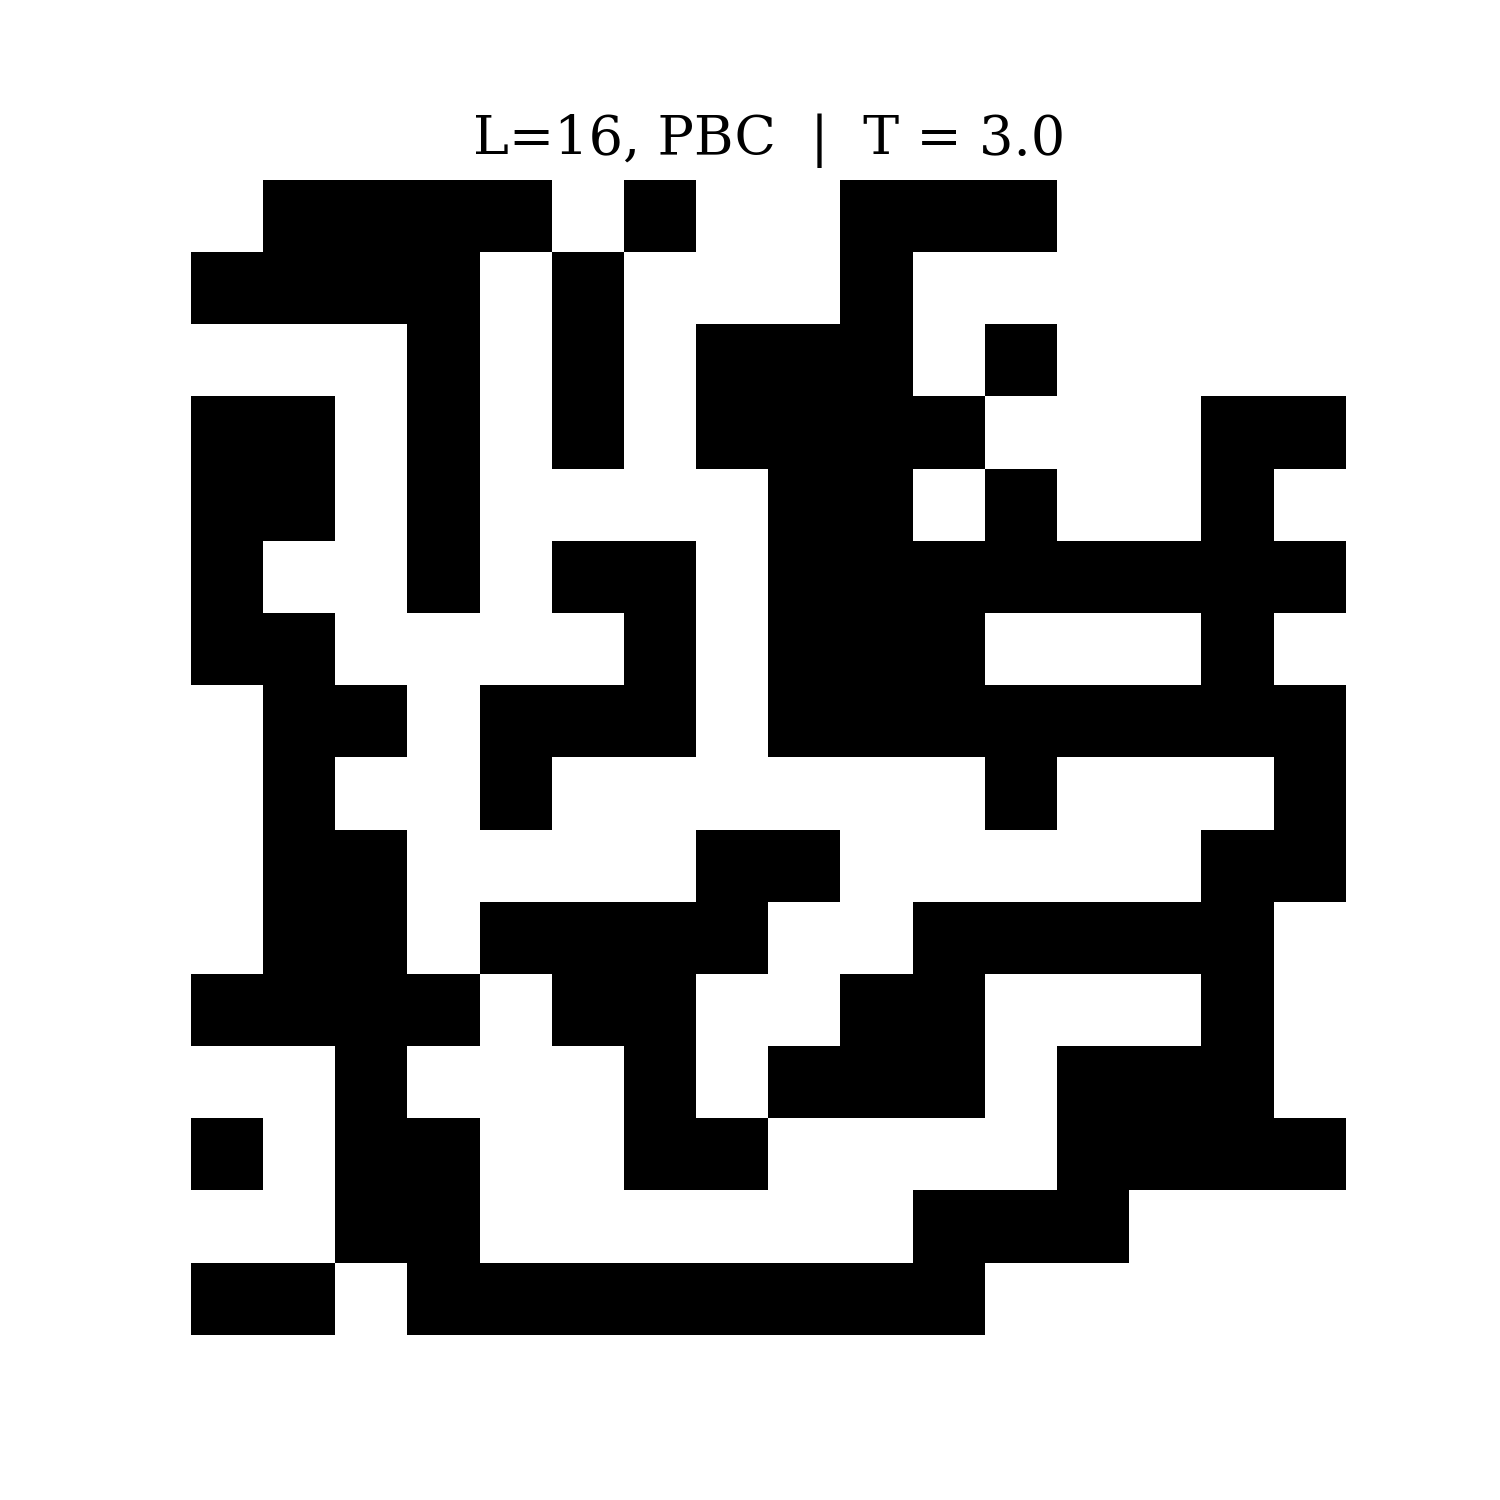

L16_FBC


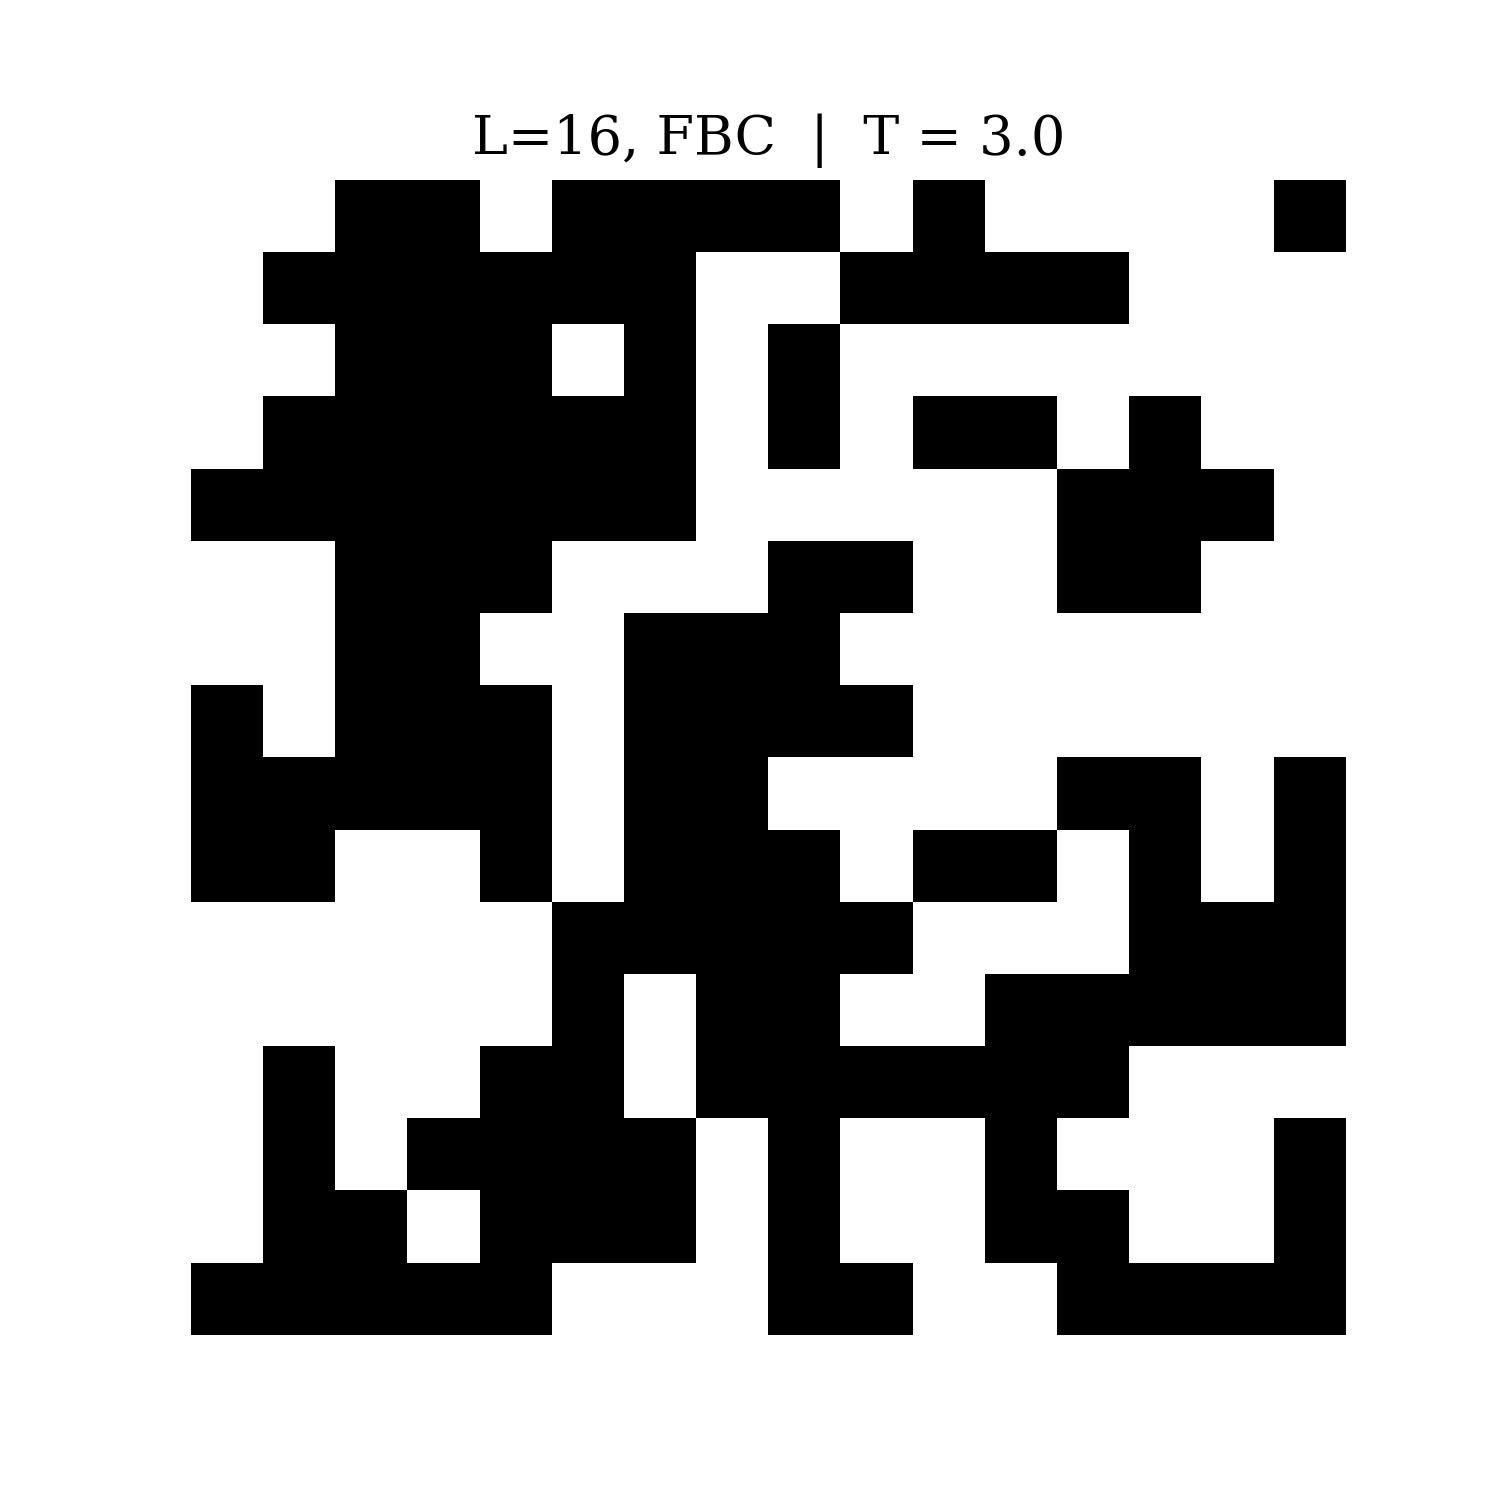

L24_PBC


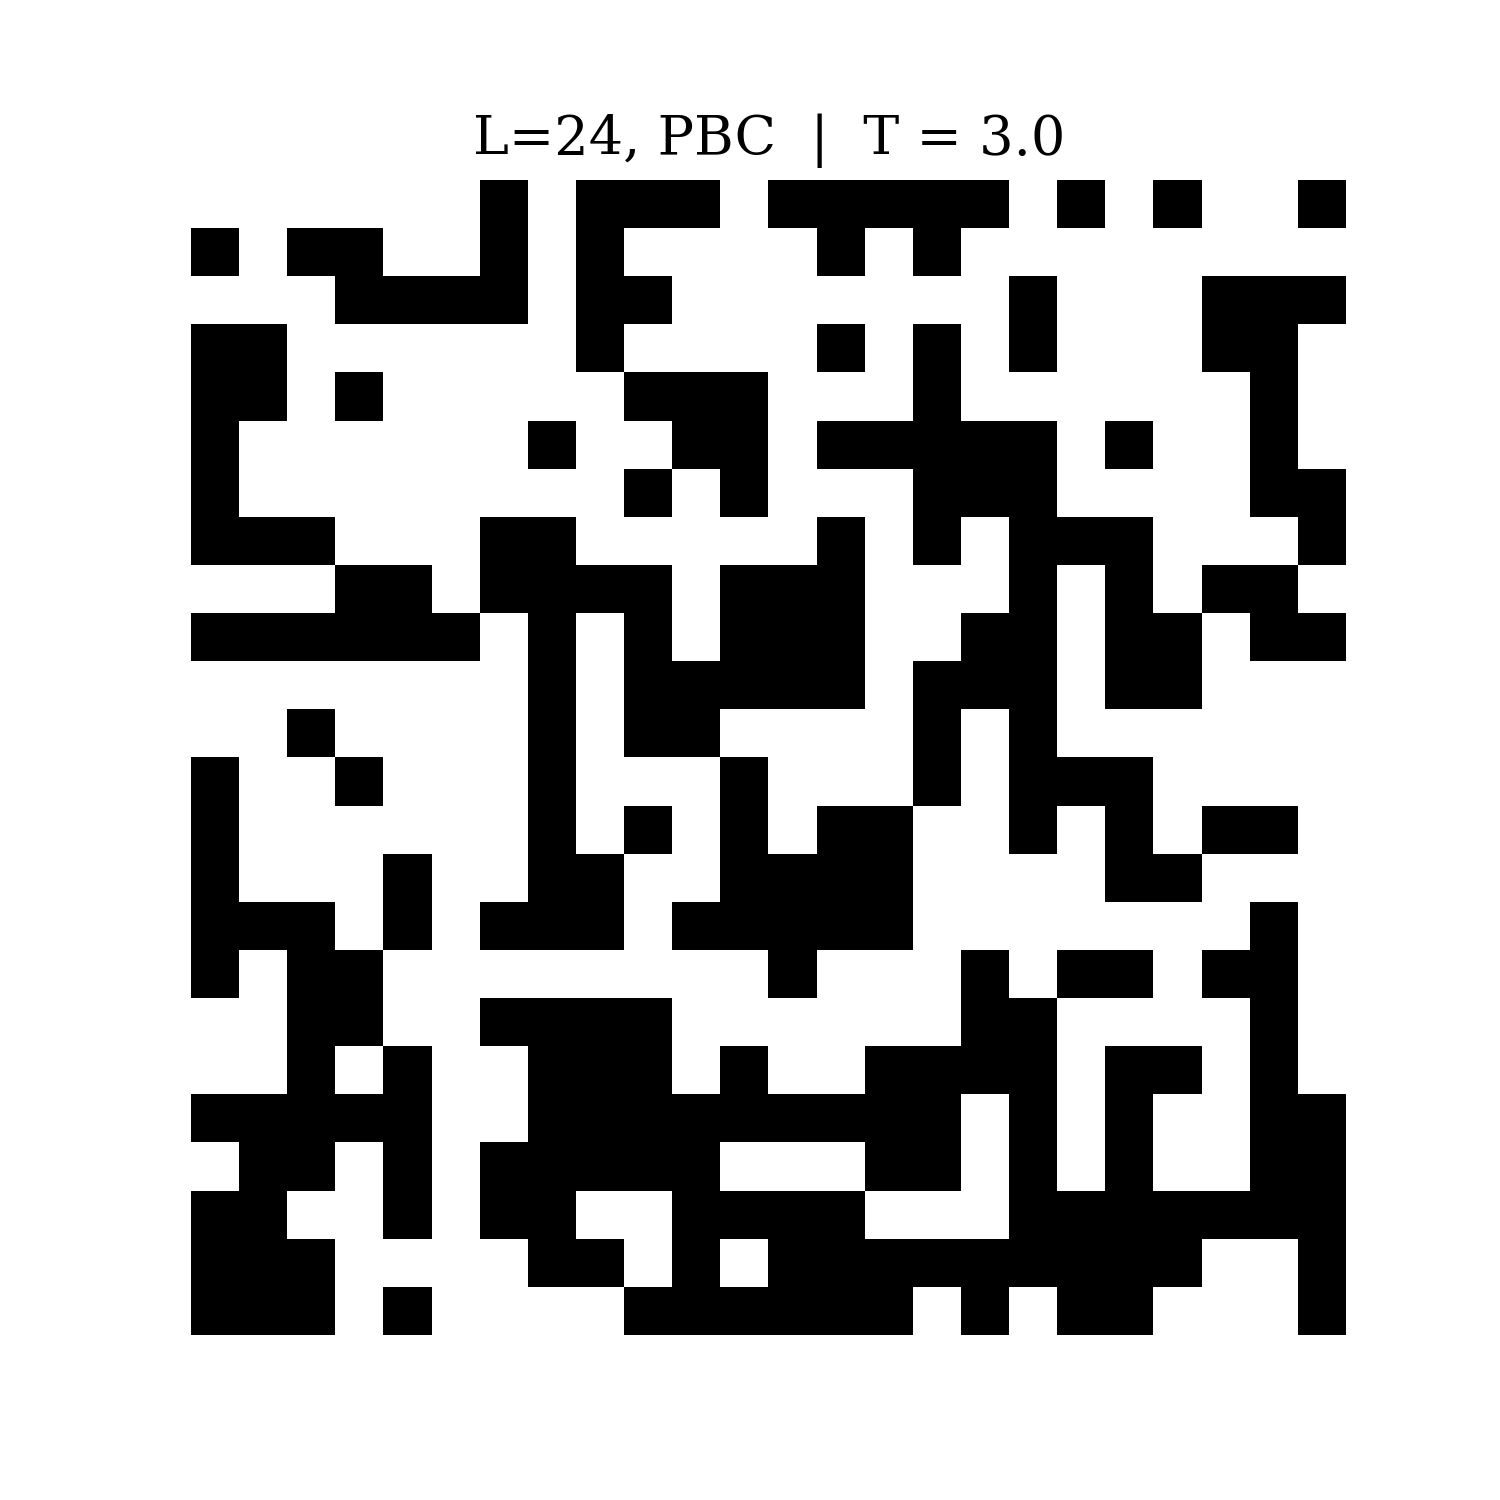

L24_FBC


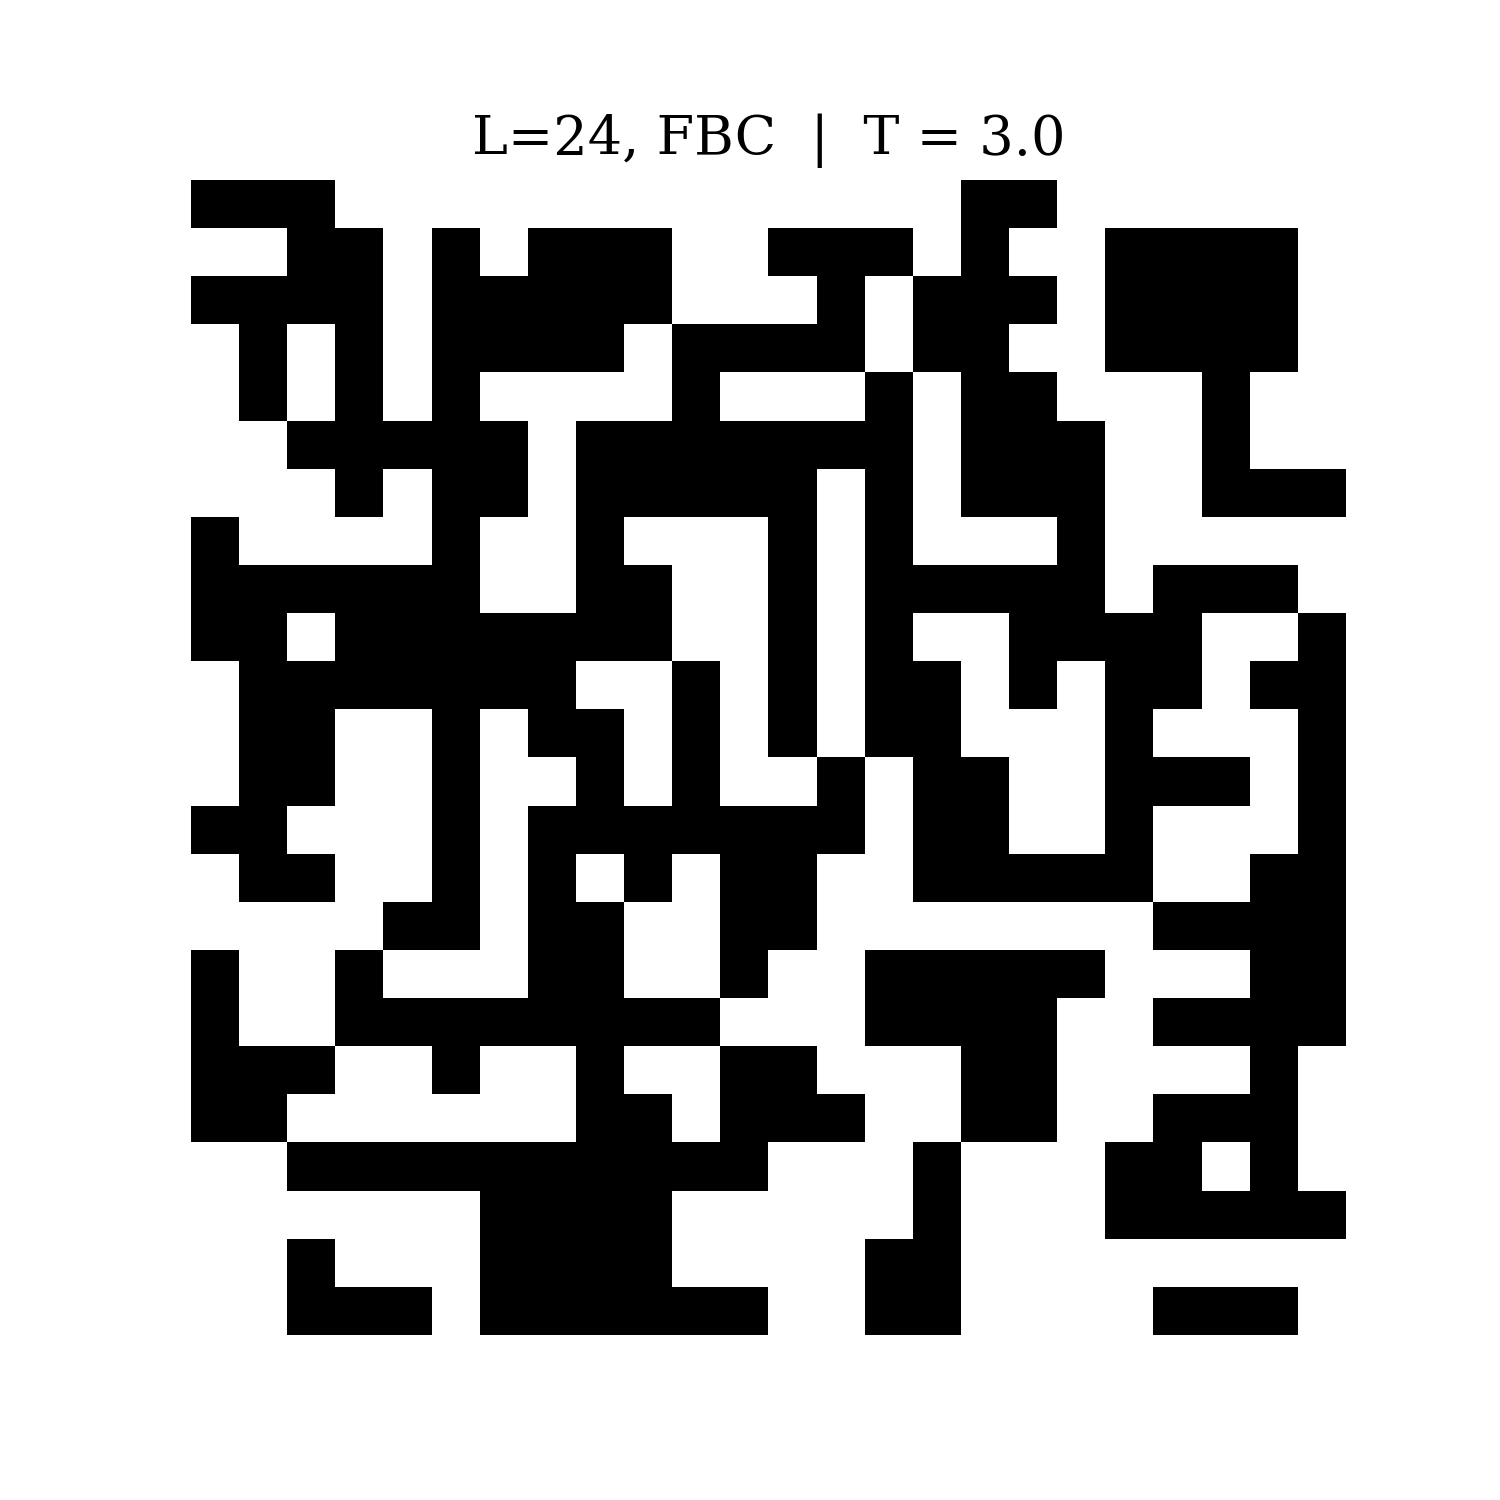

In [70]:
for key in ["L16_PBC", "L16_FBC", "L24_PBC", "L24_FBC"]:
    print(key)
    display(Image(filename=gif_paths[key]))


### Comparativa del Efecto Magnetocalórico: PBC vs FBC

A continuación, calculamos y graficamos la variación de la entropía magnética $|\Delta S_M|$ para los sistemas de producción con campo $h=0.5$. Esto permite identificar si las fronteras libres desplazan o atenúan el pico magnetocalórico respecto a las condiciones periódicas.

L=24 | FBC | h=0.5 | T=3.0
L=24 | FBC | h=0.5 | T=2.9
L=24 | FBC | h=0.5 | T=2.8
L=24 | FBC | h=0.5 | T=2.7
L=24 | FBC | h=0.5 | T=2.6
L=24 | FBC | h=0.5 | T=2.5
L=24 | FBC | h=0.5 | T=2.4
L=24 | FBC | h=0.5 | T=2.3
L=24 | FBC | h=0.5 | T=2.2
L=24 | FBC | h=0.5 | T=2.1
L=24 | FBC | h=0.5 | T=2.0
L=24 | FBC | h=0.5 | T=1.9
L=24 | FBC | h=0.5 | T=1.8
L=24 | FBC | h=0.5 | T=1.7
L=24 | FBC | h=0.5 | T=1.6
L=24 | FBC | h=0.5 | T=1.5
L=24 | FBC | h=0.5 | T=1.4
L=24 | FBC | h=0.5 | T=1.3
L=24 | FBC | h=0.5 | T=1.2
L=24 | FBC | h=0.5 | T=1.1
L=24 | FBC | h=0.5 | T=1.0
L=24 | FBC | h=0.5 | T=0.9
L=24 | FBC | h=0.5 | T=0.8
L=24 | FBC | h=0.5 | T=0.7
L=24 | FBC | h=0.5 | T=0.6
L=24 | FBC | h=0.5 | T=0.5
L=24 | FBC | h=0.5 | T=0.4
L=24 | FBC | h=0.5 | T=0.3
L=24 | FBC | h=0.5 | T=0.2
L=24 | FBC | h=0.5 | T=0.1


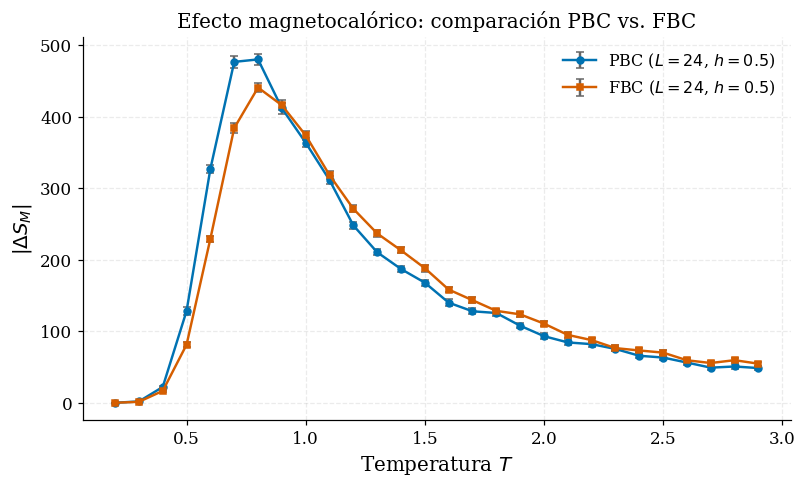

In [71]:
# Comparación del efecto magnetocalórico entre condiciones de frontera:
# se repite el barrido con h=0.5 para L=24 con frontera libre y se calcula
# Delta S_M con la misma función de diferencia central usada en la Sección 30.

results_fbc_h05 = run_M_sweep(
    24, False, TEMPERATURES_PROD, NTERM_PROD, NMUESTRA_PROD, 0.5, seed=SEED
)

delta_SM_fbc_h05 = calculate_delta_SM(results_fbc_h05)

plt.figure(figsize=(7.5, 4.6))

plt.errorbar(
    delta_SM_h05['T'], np.abs(delta_SM_h05['delta_SM']), yerr=delta_SM_h05['delta_SM_err'],
    marker='o', ms=4.5, lw=1.6, capsize=2.5, ecolor='0.4',
    color=COLOR_PBC, label='PBC ($L=24$, $h=0.5$)'
)
plt.errorbar(
    delta_SM_fbc_h05['T'], np.abs(delta_SM_fbc_h05['delta_SM']), yerr=delta_SM_fbc_h05['delta_SM_err'],
    marker='s', ms=4.5, lw=1.6, capsize=2.5, ecolor='0.4',
    color=COLOR_FBC, label='FBC ($L=24$, $h=0.5$)'
)

plt.title("Efecto magnetocalórico: comparación PBC vs. FBC")
plt.xlabel(r"Temperatura $T$")
plt.ylabel(r"$|\Delta S_M|$")
plt.legend()
plt.tight_layout()
savefig("EMC_PBC_vs_FBC")
plt.show()


### Comparativa del RCP: PBC vs FBC

El Poder de Enfriamiento Relativo ($RCP$) es un parámetro clave para evaluar la eficiencia de un material en refrigeración magnética. Se define como el producto del pico máximo de la variación de entropía magnética y el ancho a media altura ($FWHM$) de dicho pico:

$$RCP = |\Delta S_M|_{max} \cdot FWHM$$

A continuación, extraemos estos valores para ambos tipos de fronteras utilizando los datos de producción de $L=24$ con $h=0.5$.

,Frontera,Tp (J/kB),|ΔSm|max ± err,FWHM (J/kB),RCP ± err
0,PBC,0.80,480.2510 ± 7.2875,0.60,288.1506 ± 4.3725
1,FBC,0.80,440.8730 ± 6.1121,0.70,308.6111 ± 4.2785


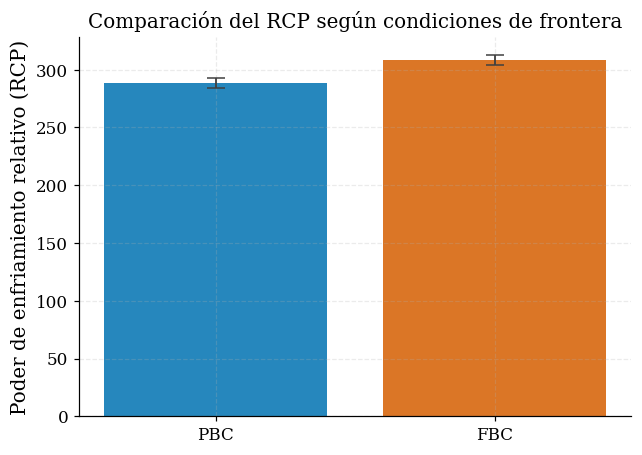

In [72]:
def get_rcp_report(T, dsm, dsm_err, label):
    # Reutilizamos la lógica de la Sección 30 para consistencia
    fwhm, rcp_val, Tp_val, dsm_max, dsm_max_err, rcp_err_val = calculate_fwhm_and_rcp(T, dsm, dsm_err)
    return {
        "Frontera": label,
        "Tp (J/kB)": Tp_val,
        "|dSm| max": dsm_max,
        "|dSm| max err": dsm_max_err,
        "FWHM (J/kB)": fwhm,
        "RCP": rcp_val,
        "RCP err": rcp_err_val,
    }

T_pbc = delta_SM_h05['T']
dsm_pbc = delta_SM_h05['delta_SM']
dsm_pbc_err = delta_SM_h05['delta_SM_err']

T_fbc = delta_SM_fbc_h05['T']
dsm_fbc = delta_SM_fbc_h05['delta_SM']
dsm_fbc_err = delta_SM_fbc_h05['delta_SM_err']

# Calculamos los valores para ambos casos
stats_pbc = get_rcp_report(T_pbc, dsm_pbc, dsm_pbc_err, "PBC")
stats_fbc = get_rcp_report(T_fbc, dsm_fbc, dsm_fbc_err, "FBC")

# Crear tabla comparativa (valor ± error, formato listo para manuscrito)
df_rcp = pd.DataFrame([stats_pbc, stats_fbc])
df_rcp_display = pd.DataFrame({
    "Frontera": df_rcp["Frontera"],
    "Tp (J/kB)": df_rcp["Tp (J/kB)"].map("{:.2f}".format),
    "|ΔSm|max ± err": [f"{v:.4f} ± {e:.4f}" for v, e in zip(df_rcp["|dSm| max"], df_rcp["|dSm| max err"])],
    "FWHM (J/kB)": df_rcp["FWHM (J/kB)"].map("{:.2f}".format),
    "RCP ± err": [f"{v:.4f} ± {e:.4f}" for v, e in zip(df_rcp["RCP"], df_rcp["RCP err"])],
})
display(df_rcp_display.style.set_caption(
    "Tabla 2. Parámetros magnetocalóricos (L=24, h=0.5). "
    "Los errores son SEM propagados desde <M> por el método de bloques."
))

# Visualización de la comparación, con barra de error
plt.figure(figsize=(6, 4.3))
plt.bar(
    ['PBC', 'FBC'],
    [stats_pbc['RCP'], stats_fbc['RCP']],
    yerr=[stats_pbc['RCP err'], stats_fbc['RCP err']],
    color=[COLOR_PBC, COLOR_FBC], alpha=0.85, capsize=6,
    error_kw=dict(ecolor='0.25', elinewidth=1.2)
)
plt.ylabel("Poder de enfriamiento relativo (RCP)")
plt.title("Comparación del RCP según condiciones de frontera")
plt.tight_layout()
savefig("RCP_PBC_vs_FBC")
plt.show()


### Cálculo vectorizado de $\Delta S_M$

Como alternativa a la diferencia central de la Sección 30, `np.gradient` permite
calcular la derivada de $M(T)$ de forma vectorizada, incluyendo los puntos de
frontera del barrido de temperaturas, y admite aplicar un suavizado de media
móvil para atenuar el ruido estadístico propio del muestreo de Monte Carlo.


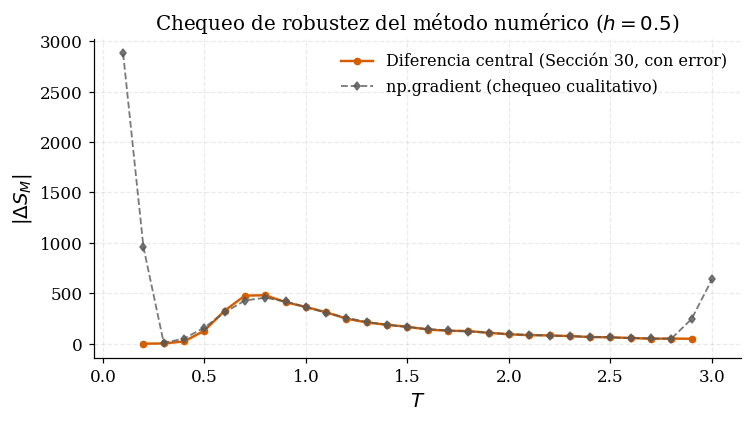

In [73]:
def optimize_emc_analysis(results, smooth_window=3):
    """
    Versión vectorizada del análisis EMC usando np.gradient, con
    suavizado opcional de media móvil. Se usa aquí únicamente como
    chequeo cualitativo de robustez frente al método de diferencia
    central con error propagado de la Sección 30 (que es el que se
    reporta cuantitativamente en la Tabla de resultados): al no
    llevar barras de error propias, no reemplaza a `calculate_delta_SM`.
    """
    r = sort_results_by_temperature(results)
    T = r['T']
    M = r['M']

    if smooth_window > 1:
        M = np.convolve(M, np.ones(smooth_window) / smooth_window, mode='same')

    dT = np.gradient(T)
    dM_dT = np.gradient(M, edge_order=2) / dT

    return T, np.abs(dM_dT)


T_opt, dsm_opt = optimize_emc_analysis(results_M_h05)

plt.figure(figsize=(7, 4))
plt.plot(
    delta_SM_h05['T'], np.abs(delta_SM_h05['delta_SM']),
    'o-', color=COLOR_H05, ms=4, lw=1.6,
    label='Diferencia central (Sección 30, con error)'
)
plt.plot(
    T_opt, dsm_opt,
    'd--', color='0.35', ms=4, lw=1.2, alpha=0.8,
    label='np.gradient (chequeo cualitativo)'
)
plt.xlabel(r'$T$')
plt.ylabel(r'$|\Delta S_M|$')
plt.title(r'Chequeo de robustez del método numérico ($h=0.5$)')
plt.legend()
plt.tight_layout()
savefig("EMC_method_robustness_check")
plt.show()


### Entropía magnética acumulada e histogramas de fluctuaciones

Dos análisis adicionales completan el estudio del efecto magnetocalórico:

1. **Entropía magnética acumulada $S_M(T)$**, obtenida integrando numéricamente
   $\Delta S_M(T)$ mediante la regla del trapecio (`scipy.integrate.cumulative_trapezoid`).
2. **Distribución del parámetro de orden stripe** $m_{\mathrm{stripe}}$ en el muestreo
   de Monte Carlo, evaluada a tres temperaturas representativas
   ($T=0.3$, ordenada; $T=1.0$, cercana a $T_N$; $T=2.0$, paramagnética),
   para visualizar cómo se ensancha su distribución cerca de la transición.


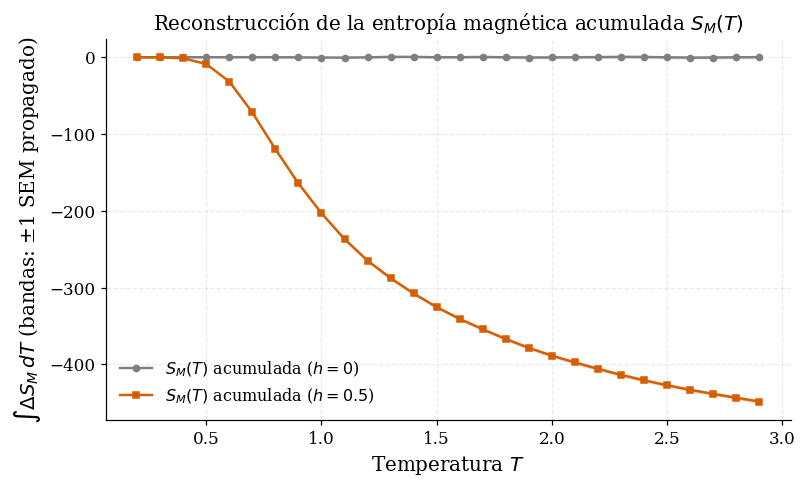

Generando distribuciones de probabilidad del parámetro de orden stripe...


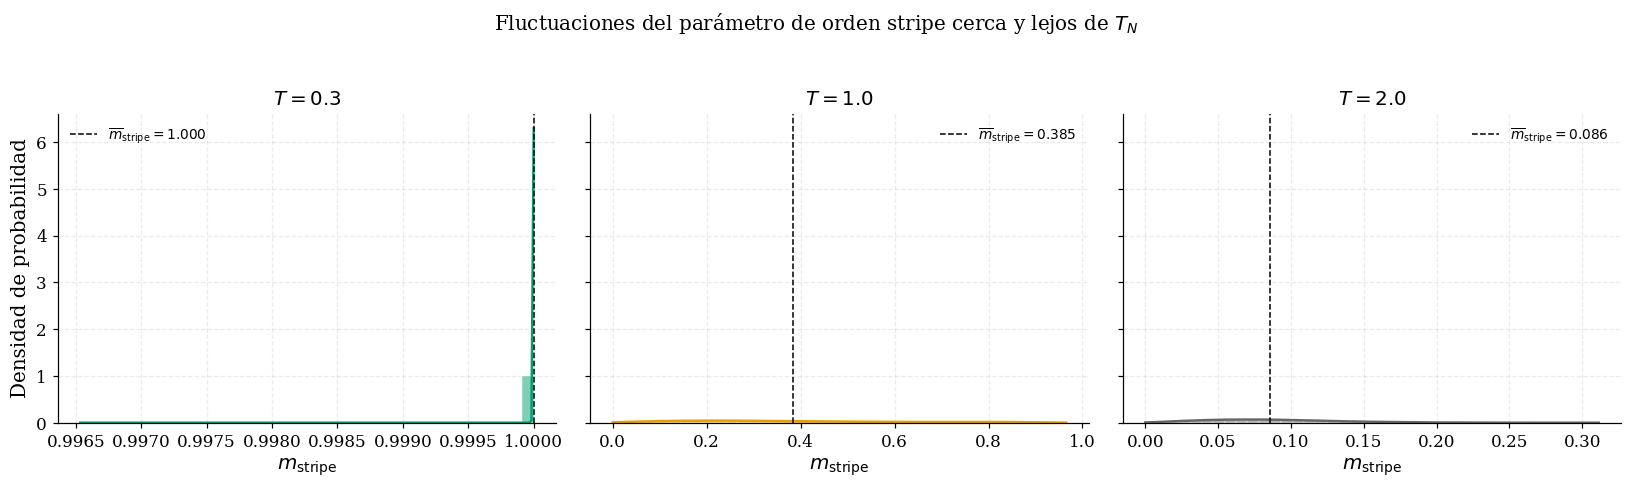

In [74]:
# ============================================================
# 1. ENTROPÍA MAGNÉTICA ACUMULADA S_M(T), CON ERROR PROPAGADO
# ============================================================
# Integramos aquí directamente delta_SM_h0 / delta_SM_h05 (Sección 30:
# diferencia central con error propagado desde <M>), no la versión
# suavizada de la Sección "Cálculo vectorizado", para que la entropía
# acumulada herede barras de error bien definidas.

def cumulative_trapz_with_error(T, y, y_err):
    """
    Integral acumulada por la regla del trapecio, junto con la
    propagación de su error (asumiendo puntos independientes):

        S_k = sum_{i<k} (T_{i+1}-T_i)/2 * (y_i + y_{i+1})
        sigma_{S_k}^2 = sum_{i<k} [(T_{i+1}-T_i)/2]^2 * (sigma_{y_i}^2 + sigma_{y_{i+1}}^2)
    """
    S = integrate.cumulative_trapezoid(y, T, initial=0.0)

    dT = np.diff(T)
    seg_var = (dT / 2.0)**2 * (y_err[:-1]**2 + y_err[1:]**2)
    S_var = np.concatenate(([0.0], np.cumsum(seg_var)))

    return S, np.sqrt(S_var)


S_h0, S_h0_err = cumulative_trapz_with_error(
    delta_SM_h0['T'], delta_SM_h0['delta_SM'], delta_SM_h0['delta_SM_err']
)
S_h05, S_h05_err = cumulative_trapz_with_error(
    delta_SM_h05['T'], delta_SM_h05['delta_SM'], delta_SM_h05['delta_SM_err']
)

fig, ax = plt.subplots(figsize=(7.5, 4.6))

ax.fill_between(
    delta_SM_h0['T'], S_h0 - S_h0_err, S_h0 + S_h0_err,
    color=COLOR_H0, alpha=0.18
)
ax.plot(
    delta_SM_h0['T'], S_h0, 'o-', color=COLOR_H0, ms=4, lw=1.6,
    label=r'$S_M(T)$ acumulada ($h=0$)'
)

ax.fill_between(
    delta_SM_h05['T'], S_h05 - S_h05_err, S_h05 + S_h05_err,
    color=COLOR_H05, alpha=0.18
)
ax.plot(
    delta_SM_h05['T'], S_h05, 's-', color=COLOR_H05, ms=4, lw=1.6,
    label=r'$S_M(T)$ acumulada ($h=0.5$)'
)

ax.set_title("Reconstrucción de la entropía magnética acumulada $S_M(T)$")
ax.set_xlabel(r"Temperatura $T$")
ax.set_ylabel(r"$\int \Delta S_M\, dT$ (bandas: ±1 SEM propagado)")
ax.legend()
fig.tight_layout()
savefig(fig, "entropia_acumulada")
plt.show()

# ============================================================
# 2. HISTOGRAMAS DE COEXISTENCIA DE FASES (m_stripe)
# ============================================================
print("Generando distribuciones de probabilidad del parámetro de orden stripe...")

T_hist_values = [0.3, 1.0, 2.0]
hist_colors = [COLOR_L16, COLOR_ACCENT, "0.4"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)

for i, T_val in enumerate(T_hist_values):
    spins_hist = random_configuration(24, seed=SEED + i)
    seed_numba_rng(SEED + i)

    _, _, mstripe_ts_hist, _, _ = sample_time_series(
        spins_hist, 24, T_val, J1, J2, 0.0,
        nn_diag, n_nn_diag, nnn_diag, n_nnn_diag,
        nterm=5000, nmuestra=10000
    )

    sns.histplot(
        mstripe_ts_hist, bins=40, kde=True, ax=axes[i],
        color=hist_colors[i], stat='probability', edgecolor='white', linewidth=0.3
    )
    axes[i].axvline(
        np.mean(mstripe_ts_hist), color='black', ls='--', lw=1.0,
        label=rf'$\overline{{m}}_{{\mathrm{{stripe}}}}={np.mean(mstripe_ts_hist):.3f}$'
    )
    axes[i].set_title(rf"$T = {T_val:.1f}$")
    axes[i].set_xlabel(r"$m_{\mathrm{stripe}}$")
    axes[i].legend(fontsize=9)
    if i == 0:
        axes[i].set_ylabel("Densidad de probabilidad")

fig.suptitle(
    "Fluctuaciones del parámetro de orden stripe cerca y lejos de $T_N$",
    fontsize=13, y=1.03
)
fig.tight_layout()
savefig(fig, "histogramas_mstripe")
plt.show()


## Referencias

Binder, K. (1981). Critical properties from Monte Carlo coarse graining and renormalization. *Physical Review Letters, 47*(9), 693–696. https://doi.org/10.1103/PhysRevLett.47.693

Franco, V., Blázquez, J. S., Ipus, J. J., Law, J. Y., Moreno-Ramírez, L. M., & Conde, A. (2018). Magnetocaloric effect: From materials research to refrigeration devices. *Progress in Materials Science, 93*, 112–232. https://doi.org/10.1016/j.pmatsci.2017.10.005

Landau, D. P., & Binder, K. (2021). *A guide to Monte Carlo simulations in statistical physics* (5th ed.). Cambridge University Press.

Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H., & Teller, E. (1953). Equation of state calculations by fast computing machines. *The Journal of Chemical Physics, 21*(6), 1087–1092. https://doi.org/10.1063/1.1699114

Stanley, H. E. (1999). Scaling, universality, and renormalization: Three pillars of modern critical phenomena. *Reviews of Modern Physics, 71*(2), S358–S366. https://doi.org/10.1103/RevModPhys.71.S358
